# National Pipeline

End-to-end supply chain optimization for antimicrobial distribution across Botswana.

In [50]:
# imports and setup
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree
from scipy.optimize import fsolve
import requests
from tqdm import tqdm
from pathlib import Path
import cvxpy as cp
import os
os.environ["PATH"] += ":/Users/elee/Library/TinyTeX/bin/universal-darwin"
import re
import sys
import json
import importlib.util
import matplotlib.pyplot as plt
import folium
from scipy.integrate import solve_ivp
import geopandas as gpd
import matplotlib.colors as mcolors
from functools import lru_cache
sys.path.append('..')  # ensure parent directory is in path for imports
antimicrobialglm_utils_path = '../antimicrobialglm/antimicrobialglm_utils.py'
spec = importlib.util.spec_from_file_location('antimicrobialglm_utils', antimicrobialglm_utils_path)
antimicrobialglm_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(antimicrobialglm_utils)
estimate_antimicrobial_demand = antimicrobialglm_utils.estimate_antimicrobial_demand
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']  # default latex font


In [51]:
TARGET_DHMT = "Greater Gaborone"
DHMT_SLUG = TARGET_DHMT.strip().lower().replace(" ", "_")
NATIONAL_ASSIGNMENT_SLUG = "national"

In [52]:
# load population points without restricting to one census district
pop = pd.read_csv('../botswana_geocode/census_population_2022_geocoded_final_uniform.csv')
pop.columns = pop.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
pop.rename(columns={'city_town_village': 'city/town/village', 'census_district': 'district'}, inplace=True)
pop['district_norm'] = pop['district'].astype(str).str.strip().str.lower()
pop = pop.dropna(subset=['latitude', 'longitude']).copy()
print(f'All population centers loaded: {len(pop)}')
print('Unique census districts in pop:', pop["district"].nunique())

All population centers loaded: 7764
Unique census districts in pop: 29


In [53]:
# load and clean facilities
fac = pd.read_csv('../data/processed/facilities_with_warehouses.csv')
# dhmt → source mapping (warehouse or cms)
fac["DHMT_norm"] = fac["DHMT"].astype(str).str.strip()
fac["Facility_norm"] = fac["Facility Name"].astype(str).str.strip()
ware = fac[fac["Is_Warehouse"] == True].copy()
DHMT_WAREHOUSE_MAP = (
    ware.groupby("DHMT_norm")["Facility_norm"]
    .first()
    .to_dict()
)
CMS_NAME = "Central Medical Stores (CMS)"
all_dhmts = fac["DHMT_norm"].dropna().unique()
DHMT_SOURCE_MAP = {
    dhmt: DHMT_WAREHOUSE_MAP.get(dhmt, CMS_NAME)
    for dhmt in all_dhmts
}
print("Example mappings:")
for k in list(DHMT_SOURCE_MAP.keys())[:10]:
    print(f"{k} -> {DHMT_SOURCE_MAP[k]}")
fac.columns = fac.columns.str.strip()
fac = fac.rename(columns={'Latitude': 'latitude', 'Longitude': 'longitude'})
fac = fac.dropna(subset=['latitude', 'longitude'])
fac['Service Delivery Type'] = (
    fac['Service Delivery Type']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
)
fac = fac[~fac['Facility Name'].str.contains('prison|school', case=False, na=False)]

Example mappings:
Mahalapye -> Mahalapye DHMT Warehouse
Greater Francistown -> Francistown DHMT Warehouse
Kgatleng -> Kgatleng DHMT Warehouse
Greater Gaborone -> Central Medical Stores (CMS)
Greater Lobatse -> Lobatse DHMT Warehouse
Okavango -> Okavango DHMT Warehouse
Ghanzi -> Ghanzi DHMT Warehouse
Kweneng -> Kweneng West DHMT Warehouse
Greater Phikwe -> Selebi-Phikwe DHMT Warehouse
Ngami -> Ngami DHMT Warehouse


In [54]:
# osrm endpoint
OSRM_URL = 'http://localhost:5001/route/v1/driving'
def osrm_distance(lat1, lon1, lat2, lon2):
    url = f'{OSRM_URL}/{lon1},{lat1};{lon2},{lat2}?overview=false'
    try:
        r = requests.get(url, timeout=8)
        data = r.json()
        if 'routes' in data and data['routes']:
            route = data['routes'][0]
            return route['distance'] / 1000, route['duration'] / 60
    except Exception:
        pass
    return np.nan, np.nan

In [55]:
# model parameters
TRANSPORT_COST_PER_KM = 0.50  # cost per km for transportation
SHORTAGE_PENALTY = 3.0  # penalty per unit of unmet demand
HOLDING_COST = 0.10  # cost per unit of excess inventory
STORAGE_CAPACITY = 10000  # storage capacity per facility
VEHICLE_CAPACITY = 1000  # vehicle capacity for routing
M_BIG = 100000  # big-m constant for binary constraints
DEMAND_CV = 0.3  # coefficient of variation for demand uncertainty

print("Model Parameters:")
print(f"  Transport cost: ${TRANSPORT_COST_PER_KM}/km")
print(f"  Shortage penalty: ${SHORTAGE_PENALTY}/unit")
print(f"  Holding cost: ${HOLDING_COST}/unit")
print(f"  Storage capacity: {STORAGE_CAPACITY} units/facility")
print(f"  Vehicle capacity: {VEHICLE_CAPACITY} units")
print(f"  Demand CV: {DEMAND_CV}")

Model Parameters:
  Transport cost: $0.5/km
  Shortage penalty: $3.0/unit
  Holding cost: $0.1/unit
  Storage capacity: 10000 units/facility
  Vehicle capacity: 1000 units
  Demand CV: 0.3


## Nearest Facility Assignment

In [56]:
# nearest facility logic (same as main workflow, but scoped to gaborone)
def nearest_facilities(pop_df, fac_df, subtype, n=1):
    if subtype == 'Clinic':
        sub = fac_df[
            fac_df['Service Delivery Type'].str.lower().isin(['clinic', 'clinic with maternity'])
        ]
    elif subtype == 'Hospital':
        sub = fac_df[
            fac_df['Service Delivery Type'].str.lower().isin(['primary hospital', 'district hospital']) |
            ((fac_df['Service Delivery Type'].str.lower() == 'referral hospital') & 
             (fac_df['Facility Name'].str.contains('Princess Marina|Nyangabgwe', case=False, na=False)))
        ]
    else:
        sub = fac_df[fac_df['Service Delivery Type'].str.lower() == subtype.lower()]
    if sub.empty:
        print(f'no facilities for {subtype}')
        return pop_df
    tree = cKDTree(sub[['latitude', 'longitude']].to_numpy())
    dist, idx = tree.query(pop_df[['latitude', 'longitude']].to_numpy(), k=n)
    dist = dist[:, None] if n == 1 else dist
    idx = idx[:, None] if n == 1 else idx
    nearest = [sub.iloc[idx[:, i]].reset_index(drop=True).add_suffix(f'_{i+1}') for i in range(n)]
    merged = pd.concat(nearest, axis=1)
    merged['crow_dist_km_1'] = dist[:, 0]
    return pd.concat([pop_df.reset_index(drop=True), merged], axis=1)

In [57]:
# run nearest facility analysis for gaborone
results = {}
for subtype in ['Health Post', 'Clinic', 'Hospital']:
    print(f'finding nearest {subtype.lower()}s...')
    results[subtype] = nearest_facilities(pop, fac, subtype)

def attach_assigned_dhmt(result_df, fac_df, subtype):
    fac_lookup = fac_df[['Facility Name', 'DHMT']].copy()
    fac_lookup['Facility Name'] = fac_lookup['Facility Name'].astype(str).str.strip()
    fac_lookup['DHMT'] = fac_lookup['DHMT'].astype(str).str.strip()

    dhmt_name_overrides = {
        "Mowana Health Post": "Mahalapye",
        "Phuduhudu Health Post": "Kgalagadi North",
        "Tshwaane Health Post": "Kweneng",
    }

    fac_lookup['DHMT'] = fac_lookup.apply(
        lambda r: dhmt_name_overrides.get(r['Facility Name'], r['DHMT']),
        axis=1
    )

    fac_lookup = fac_lookup.drop_duplicates(subset=['Facility Name'])

    col = 'Facility Name_1'
    if col not in result_df.columns:
        raise ValueError(f"{col} not found in results for {subtype}")

    out = result_df.copy()
    out[col] = out[col].astype(str).str.strip()

    out = out.merge(
        fac_lookup,
        left_on=col,
        right_on='Facility Name',
        how='left'
    )

    out = out.rename(columns={'DHMT': f'assigned_dhmt_{subtype.lower().replace(" ", "_")}'})
    out = out.drop(columns=['Facility Name'])

    return out

results_with_dhmt = {}
for subtype in results:
    print(f"attaching DHMT for {subtype}...")
    results_with_dhmt[subtype] = attach_assigned_dhmt(results[subtype], fac, subtype)

finding nearest health posts...
finding nearest clinics...
finding nearest hospitals...
attaching DHMT for Health Post...
attaching DHMT for Clinic...
attaching DHMT for Hospital...


In [58]:
# filter population based on any facility assignment to the dhmt

target_dhmt_norm = TARGET_DHMT.strip().lower()

df = results_with_dhmt['Hospital'].copy()

mask_hosp = df['assigned_dhmt_hospital'].astype(str).str.strip().str.lower() == target_dhmt_norm
mask_clinic = results_with_dhmt['Clinic']['assigned_dhmt_clinic'].astype(str).str.strip().str.lower() == target_dhmt_norm
mask_hp = results_with_dhmt['Health Post']['assigned_dhmt_health_post'].astype(str).str.strip().str.lower() == target_dhmt_norm

# align masks by index (they come from same base population ordering)
mask = mask_hosp | mask_clinic | mask_hp

pop_dhmt = df[mask].copy()

print(f"Total population points assigned to {TARGET_DHMT} (any facility): {len(pop_dhmt)}")

Total population points assigned to Greater Gaborone (any facility): 291


In [59]:
# osrm routing for botswana
for subtype, df in results.items():
    print(f'routing for {subtype.lower()}...')
    dist_list, time_list = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        d_km, t_min = osrm_distance(
            row['latitude'], row['longitude'],
            row['latitude_1'], row['longitude_1']
        )
        dist_list.append(d_km)
        time_list.append(t_min)

    dist_col = f'osrm_dist_km_{subtype}'
    time_col = f'osrm_time_min_{subtype}'

    results[subtype][dist_col] = dist_list
    results[subtype][time_col] = time_list

    # keep the dhmt-annotated version synchronized too
    if subtype in results_with_dhmt:
        results_with_dhmt[subtype][dist_col] = dist_list
        results_with_dhmt[subtype][time_col] = time_list

routing for health post...


100%|██████████| 7764/7764 [00:38<00:00, 204.11it/s]


routing for clinic...


100%|██████████| 7764/7764 [00:35<00:00, 219.36it/s]


routing for hospital...


100%|██████████| 7764/7764 [00:39<00:00, 196.09it/s]


In [60]:
# merge nearest facility info for the dhmt catchment
# important: preserve original population row identity so clinic / health post
# assignments line up correctly after filtering to the dhmt catchment.

merged = pop_dhmt.copy()
merged["pop_id"] = merged.index  # use original index, do not reset yet

# hospital fields come from the hospital-based pop_dhmt frame
merged = merged.rename(columns={
    "Facility Name_1": "nearest_Hospital_name",
    "latitude_1": "nearest_Hospital_lat",
    "longitude_1": "nearest_Hospital_lon",
    "DHMT_1": "nearest_Hospital_dhmt",
    "crow_dist_km_1": "crow_dist_km_Hospital",
    "osrm_dist_km_Hospital": "route_km_to_Hospital",
    "osrm_time_min_Hospital": "route_min_to_Hospital",
})

# clinic info: keep original row identity from the original population table
clinic_sub = results_with_dhmt["Clinic"].copy()
clinic_sub["pop_id"] = clinic_sub.index
clinic_sub = clinic_sub[[
    "pop_id",
    "Facility Name_1", "latitude_1", "longitude_1",
    "DHMT_1", "crow_dist_km_1",
    "osrm_dist_km_Clinic", "osrm_time_min_Clinic"
]].rename(columns={
    "Facility Name_1": "nearest_Clinic_name",
    "latitude_1": "nearest_Clinic_lat",
    "longitude_1": "nearest_Clinic_lon",
    "DHMT_1": "nearest_Clinic_dhmt",
    "crow_dist_km_1": "crow_dist_km_Clinic",
    "osrm_dist_km_Clinic": "route_km_to_Clinic",
    "osrm_time_min_Clinic": "route_min_to_Clinic",
})

# health post info: same logic
hp_sub = results_with_dhmt["Health Post"].copy()
hp_sub["pop_id"] = hp_sub.index
hp_sub = hp_sub[[
    "pop_id",
    "Facility Name_1", "latitude_1", "longitude_1",
    "DHMT_1", "crow_dist_km_1",
    "osrm_dist_km_Health Post", "osrm_time_min_Health Post"
]].rename(columns={
    "Facility Name_1": "nearest_HealthPost_name",
    "latitude_1": "nearest_HealthPost_lat",
    "longitude_1": "nearest_HealthPost_lon",
    "DHMT_1": "nearest_HealthPost_dhmt",
    "crow_dist_km_1": "crow_dist_km_HealthPost",
    "osrm_dist_km_Health Post": "route_km_to_HealthPost",
    "osrm_time_min_Health Post": "route_min_to_HealthPost",
})

merged = merged.merge(clinic_sub, on="pop_id", how="left")
merged = merged.merge(hp_sub, on="pop_id", how="left")

merged = merged.reset_index(drop=True)

merged.to_csv(f"{DHMT_SLUG}_population_nearest_facilities.csv", index=False)
print(f"{TARGET_DHMT} data complete!")

print("Rows in merged:", len(merged))
print("Unique pop_id:", merged["pop_id"].nunique())

print("Missing hospital assignments:", merged["nearest_Hospital_name"].isna().sum())
print("Missing clinic assignments:", merged["nearest_Clinic_name"].isna().sum())
print("Missing health post assignments:", merged["nearest_HealthPost_name"].isna().sum())
print("Non-null clinic route km:", merged["route_km_to_Clinic"].notna().sum())
print("Non-null health post route km:", merged["route_km_to_HealthPost"].notna().sum())

Greater Gaborone data complete!
Rows in merged: 291
Unique pop_id: 291
Missing hospital assignments: 0
Missing clinic assignments: 0
Missing health post assignments: 0
Non-null clinic route km: 291
Non-null health post route km: 291


In [61]:
fac_clean = fac.copy()

fac_clean["_dhmt_norm"] = fac_clean["DHMT"].astype(str).str.strip().str.lower()
fac_clean = fac_clean[
    fac_clean["_dhmt_norm"] == TARGET_DHMT.strip().lower()
].reset_index(drop=True)
DHMT_SLUG = TARGET_DHMT.strip().lower().replace(" ", "_")
print("DHMT-filtered facilities:", fac_clean.shape)
print(fac_clean["Service Delivery Type"].value_counts())
fac_clean.to_csv(f"{DHMT_SLUG}_facilities_filtered.csv", index=False)

DHMT-filtered facilities: (43, 15)
Service Delivery Type
Clinic                   27
Clinic with Maternity     7
Health Post               7
Referral Hospital         1
Warehouse                 1
Name: count, dtype: int64


## Distance and Time Matrices

In [62]:
# load distance and duration matrices
dist_matrix_df = pd.read_csv("../data/processed/distance_matrix_named.csv", index_col=0)
time_matrix_df = pd.read_csv("../data/processed/duration_matrix_named.csv", index_col=0)

print("distance shape:", dist_matrix_df.shape)
print("time shape:", time_matrix_df.shape)

def clean_name(x):
    # remove bom, non-breaking spaces, collapse internal whitespace, strip ends
    s = str(x).replace("\ufeff", "").replace("\xa0", " ")
    s = " ".join(s.split())
    return s.strip()

dist_matrix_df.index = dist_matrix_df.index.map(clean_name)
dist_matrix_df.columns = dist_matrix_df.columns.map(clean_name)

time_matrix_df.index = time_matrix_df.index.map(clean_name)
time_matrix_df.columns = time_matrix_df.columns.map(clean_name)

# align to common labels and same order
common = dist_matrix_df.index.intersection(dist_matrix_df.columns)
dist_matrix_df = dist_matrix_df.loc[common, common]
time_matrix_df = time_matrix_df.loc[common, common]

print("after cleaning shapes:", dist_matrix_df.shape, time_matrix_df.shape)
print("index==cols:", list(dist_matrix_df.index) == list(dist_matrix_df.columns))

# keep first occurrence of each duplicated name (keeps first occurrence)
dist_matrix_df = dist_matrix_df.loc[~dist_matrix_df.index.duplicated(keep="first"),
                                    ~dist_matrix_df.columns.duplicated(keep="first")]
time_matrix_df = time_matrix_df.loc[~time_matrix_df.index.duplicated(keep="first"),
                                    ~time_matrix_df.columns.duplicated(keep="first")]

# then re-clean + align again
dist_matrix_df.index = dist_matrix_df.index.map(clean_name)
dist_matrix_df.columns = dist_matrix_df.columns.map(clean_name)
time_matrix_df.index = time_matrix_df.index.map(clean_name)
time_matrix_df.columns = time_matrix_df.columns.map(clean_name)

common = dist_matrix_df.index.intersection(dist_matrix_df.columns)
dist_matrix_df = dist_matrix_df.loc[common, common]
time_matrix_df = time_matrix_df.loc[common, common]

assert list(dist_matrix_df.index) == list(dist_matrix_df.columns)
assert list(time_matrix_df.index) == list(time_matrix_df.columns)

distance shape: (636, 636)
time shape: (636, 636)
after cleaning shapes: (633, 632) (633, 632)
index==cols: False


In [63]:
# make sure we have a facility_name column
if "facility_name" not in fac_clean.columns:
    if "Facility Name" in fac_clean.columns:
        fac_clean = fac_clean.rename(columns={"Facility Name": "facility_name"})
    else:
        raise KeyError(f"no facility name column found. columns = {fac_clean.columns.tolist()}")

# clean facility names
fac_clean["facility_name"] = fac_clean["facility_name"].map(clean_name)

# include all dhmt facilities plus the source node for this dhmt
source_node = DHMT_SOURCE_MAP[TARGET_DHMT]
all_nodes = fac_clean["facility_name"].tolist()

if source_node not in all_nodes:
    all_nodes = [source_node] + all_nodes

# keep only those present in matrices
nodes_in = [
    n for n in all_nodes
    if n in dist_matrix_df.index and n in dist_matrix_df.columns
]

print(f"{TARGET_DHMT} facilities + source candidate:", len(all_nodes))
print("matched in matrix:", len(nodes_in))

missing_nodes = sorted(set(all_nodes) - set(nodes_in))
if missing_nodes:
    print("Missing from matrix:")
    print(missing_nodes)

# subset
D = dist_matrix_df.loc[nodes_in, nodes_in].copy()
T = time_matrix_df.loc[nodes_in, nodes_in].copy()

print("subset shapes:", D.shape, T.shape)

Greater Gaborone facilities + source candidate: 43
matched in matrix: 43
subset shapes: (43, 43) (43, 43)


## Multiechelon Network Construction

In [64]:
# build a general multiechelon node set and arc set:
# source -> hospitals
# source -> clinics
# hospitals -> clinics
# hospitals -> health posts
# this keeps the code general across botswana, while still allowing
# a dhmt-specific source node (warehouse or cms) from dhmt_source_map.

source_node = clean_name(DHMT_SOURCE_MAP[TARGET_DHMT])

# rebuild node list from cleaned facility names plus the source node
facility_nodes = fac_clean["facility_name"].tolist()
all_nodes = facility_nodes.copy()
if source_node not in all_nodes:
    all_nodes = [source_node] + all_nodes

# keep only nodes present in the matrices
nodes = [n for n in all_nodes if n in dist_matrix_df.index and n in dist_matrix_df.columns]

# subset distance and time matrices
D = dist_matrix_df.loc[nodes, nodes].copy()
T = time_matrix_df.loc[nodes, nodes].copy()

print("D shape:", D.shape, "T shape:", T.shape)

# canonical tiers
def to_tier(s):
    s = str(s).lower().strip()
    if "warehouse" in s or "dhmt" in s or "store" in s:
        return "warehouse"
    if "tertiary" in s or "referral" in s or "hospital" in s:
        return "hospital"
    if "health post" in s or "healthpost" in s:
        return "health_post"
    if "clinic" in s or "health centre" in s or "health center" in s:
        return "clinic"
    return "clinic"

fac_clean = fac_clean.copy()
fac_clean["tier"] = fac_clean["Service Delivery Type"].apply(to_tier)

tier_map = dict(zip(fac_clean["facility_name"], fac_clean["tier"]))

# force the dhmt source node to be a warehouse-tier source in the network
tier_map[source_node] = "warehouse"

# allowed arcs for the national multiechelon model
allowed = {
    "warehouse": ["hospital"],
    "hospital": ["clinic", "health_post"],
    "clinic": ["hospital"],
    "health_post": ["hospital"],
}

M_NEIGHBORS = 1000

rows = []
for u in nodes:
    u_tier = tier_map.get(u)
    if u_tier is None:
        continue

    for v_tier in allowed.get(u_tier, []):
        cand = [v for v in nodes if v != u and tier_map.get(v) == v_tier]
        if not cand:
            continue

        dists = D.loc[u, cand].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
        if dists.empty:
            continue

        for v, dist_km in dists.nsmallest(min(M_NEIGHBORS, len(dists))).items():
            time_val = T.loc[u, v]
            if pd.isna(time_val) or np.isinf(time_val):
                continue

            rows.append({
                "u": u,
                "v": v,
                "u_tier": u_tier,
                "v_tier": v_tier,
                "dist_km": float(dist_km),
                "time_min": float(time_val),
            })

arcs = pd.DataFrame(rows).drop_duplicates(subset=["u", "v"]).reset_index(drop=True)

print("source node:", source_node)
print("arcs:", len(arcs))
if len(arcs) > 0:
    print(arcs.groupby(["u_tier", "v_tier"]).size())
else:
    print("no arcs created — check tier mapping + allowed rules")

print("node tier counts:\n", pd.Series([tier_map.get(n, "unknown") for n in nodes]).value_counts())

arcs["dist_km"] = arcs["dist_km"] / 1000.0
arcs["time_min"] = arcs["time_min"] / 60.0

D shape: (43, 43) T shape: (43, 43)
source node: Central Medical Stores (CMS)
arcs: 83
u_tier       v_tier     
clinic       hospital       34
health_post  hospital        7
hospital     clinic         34
             health_post     7
warehouse    hospital        1
dtype: int64
node tier counts:
 clinic         34
health_post     7
hospital        1
warehouse       1
Name: count, dtype: int64


## Antimicrobial Demand Estimation

In [65]:
age_df = pd.read_csv("../census_datacleaning/botswana_population_age_breakdown.csv")

# normalize age labels (- → -)
age_df["AgeGroup"] = (
    age_df["AgeGroup"].astype(str)
      .str.replace("\u2013", "-", regex=False)
      .str.strip()
)

# rename for consistency
age_df = age_df.rename(columns={
    "DistrictName": "district",
    "AgeGroup": "agegroup",
    "Population": "pop"
})

age_df["pop"] = pd.to_numeric(age_df["pop"], errors="coerce").fillna(0)

display(age_df.head())

# district-specific age proportions
age_df["share"] = age_df["pop"] / age_df.groupby("district")["pop"].transform("sum")

# sanity check
chk = age_df.groupby("district")["share"].sum()
print("max |sum - 1|:", float((chk - 1).abs().max()))

,district,agegroup,pop,DistrictCode
0,Barolong,<1,1276,11
1,Barolong,1-5,7091,11
2,Barolong,6-10,7138,11
3,Barolong,11-15,6068,11
4,Barolong,16-20,4478,11


max |sum - 1|: 0.0


In [66]:
POP_COL = "total_population"
DISTRICT_COL = "district"  # from merged

merged = merged.copy()
merged[POP_COL] = (
    merged[POP_COL].astype(str)
      .str.replace(",", "", regex=False)
)
merged[POP_COL] = pd.to_numeric(merged[POP_COL], errors="coerce")
assert merged[POP_COL].notna().all(), "some total_population values could not be parsed"

# choose exactly one downstream dispensing node per population point:
# nearest clinic vs nearest health post, using the existing nearest-facility
# assignments already in merged. no live osrm needed.

clinic_df = merged[[
    "pop_id",
    "nearest_Clinic_name",
    "crow_dist_km_Clinic",
    DISTRICT_COL,
    POP_COL
]].copy()
clinic_df = clinic_df.rename(columns={
    "nearest_Clinic_name": "facility_name",
    "crow_dist_km_Clinic": "dist_km",
    DISTRICT_COL: "district",
    POP_COL: "pop_total",
})
clinic_df["facility_type"] = "clinic"

hp_df = merged[[
    "pop_id",
    "nearest_HealthPost_name",
    "crow_dist_km_HealthPost",
    DISTRICT_COL,
    POP_COL
]].copy()
hp_df = hp_df.rename(columns={
    "nearest_HealthPost_name": "facility_name",
    "crow_dist_km_HealthPost": "dist_km",
    DISTRICT_COL: "district",
    POP_COL: "pop_total",
})
hp_df["facility_type"] = "health_post"

choices = pd.concat([clinic_df, hp_df], ignore_index=True)

choices["facility_name"] = choices["facility_name"].astype(str).str.strip()
choices["dist_km"] = pd.to_numeric(choices["dist_km"], errors="coerce")
choices = choices.replace({"facility_name": {"": np.nan, "nan": np.nan}})
choices = choices.dropna(subset=["facility_name", "dist_km"])

# keep the closer downstream node for each population point
choices = choices.sort_values(["pop_id", "dist_km"])
closest = choices.drop_duplicates(subset=["pop_id"], keep="first")

pop_fac = (
    closest
    .groupby(["facility_name", "facility_type", "district"], as_index=False)["pop_total"]
    .sum()
)

print("Downstream facilities by type:")
print(pop_fac["facility_type"].value_counts(dropna=False))

display(pop_fac.head())

Downstream facilities by type:
facility_type
clinic         63
health_post    29
Name: count, dtype: int64


,facility_name,facility_type,district,pop_total
0,BAC Clinic,clinic,Gaborone,7376
1,BAC Clinic,clinic,Kweneng East,379
2,BAC Clinic,clinic,South East,13
3,Bontleng Clinic,clinic,Gaborone,17750
4,Botswana Police College,clinic,South East,45


In [67]:
district_adm = pd.read_csv("../data/reference/district_admissions_estimates_2021.csv")

district_adm = district_adm.rename(columns={
    "Health District": "district",
    "Estimated Admissions 2021": "annual_admissions_est"
})

district_adm["district"] = district_adm["district"].astype(str).str.strip()
district_adm["annual_admissions_est"] = pd.to_numeric(
    district_adm["annual_admissions_est"], errors="coerce"
)

display(district_adm[["district", "annual_admissions_est"]].head())

def norm_district(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()

district_adm["district_key"] = district_adm["district"].apply(norm_district)
age_df["district_key"] = age_df["district"].apply(norm_district)
pop_fac["district_key"] = pop_fac["district"].apply(norm_district)

,district,annual_admissions_est
0,Francistown,29721.594969
1,Kweneng East,21223.270128
2,Gaborone,18065.515031
3,Serowe,10279.140922
4,Mahalapye,10196.487011


In [68]:
# pop_fac already has: facility_name, district, pop_total

# 1. build normalized district key on the population side
pop_fac["district_key"] = pop_fac["district"].apply(norm_district).astype(str).str.strip().str.lower()

# 2. normalize district_adm keys
district_adm["district_key"] = district_adm["district_key"].astype(str).str.strip().str.lower()

# 3. crosswalk census-side district labels into admissions-side labels
district_crosswalk = {
    "barolong": "goodhope",
    "central bobonong": "bobirwa",
    "central boteti": "boteti",
    "central kgalagadi game reserve": "kgalagadi north",
    "central mahalapye": "mahalapye",
    "central serowe/ palapye": "palapye",
    "jwaneng": "goodhope",
    "kweneng west": "kweneng east",
    "ngamiland delta": "ngamiland",
    "ngamiland east": "ngamiland",
    "ngamiland west": "ngamiland",
    "ngwaketse": "southern",
    "ngwaketse west": "southern",
}

pop_fac["district_key_raw"] = pop_fac["district_key"]
pop_fac["district_key"] = pop_fac["district_key"].replace(district_crosswalk)

# 4. remove old rerun artifact if it exists
pop_fac = pop_fac.drop(columns=["annual_admissions_est"], errors="ignore")

# 5. map district admissions onto each facility row
adm_map = (
    district_adm
    .drop_duplicates("district_key")
    .set_index("district_key")["annual_admissions_est"]
)

pop_fac["annual_admissions_est"] = pop_fac["district_key"].map(adm_map)

# 6. check for any remaining unmatched districts
missing = sorted(
    pop_fac.loc[pop_fac["annual_admissions_est"].isna(), "district_key"]
    .dropna()
    .unique()
    .tolist()
)
print("missing district keys:", missing)
print("n missing keys:", len(missing))

assert pop_fac["annual_admissions_est"].notna().all(), "missing district admissions estimates"

# 7. compute district total catchment population
pop_fac["district_pop_total"] = pop_fac.groupby("district_key")["pop_total"].transform("sum")

# 8. facility share of district population
pop_fac["facility_pop_share"] = np.where(
    pop_fac["district_pop_total"] > 0,
    pop_fac["pop_total"] / pop_fac["district_pop_total"],
    0.0
)

# 9. allocate annual district admissions to facilities by catchment-population share
pop_fac["facility_admissions_annual"] = (
    pop_fac["facility_pop_share"] * pop_fac["annual_admissions_est"]
)

display(pop_fac.head())

missing district keys: []
n missing keys: 0


,facility_name,facility_type,district,pop_total,district_key,district_key_raw,annual_admissions_est,district_pop_total,facility_pop_share,facility_admissions_annual
0,BAC Clinic,clinic,Gaborone,7376,gaborone,gaborone,18065.515031,244250,0.030199,545.552667
1,BAC Clinic,clinic,Kweneng East,379,kweneng east,kweneng east,21223.270128,157620,0.002405,51.031718
2,BAC Clinic,clinic,South East,13,south east,south east,3719.425992,112740,0.000115,0.428885
3,Bontleng Clinic,clinic,Gaborone,17750,gaborone,gaborone,18065.515031,244250,0.072671,1312.847049
4,Botswana Police College,clinic,South East,45,south east,south east,3719.425992,112740,0.000399,1.484603


In [69]:
# normalize district keys
pop_fac["district_key"] = pop_fac["district"].apply(norm_district)
age_df["district_key"] = age_df["district"].apply(norm_district)

# map fine-grained age-table districts into the pop_fac district scheme
age_df["district_key"] = age_df["district_key"].replace({
    "ckgr": "central kgalagadi game reserve",
    "central serowe-palapye": "central serowe/ palapye",
    "central madinare": "central bobonong",
    "central molalatau": "central bobonong",
    "central tutume": "central bobonong",
    "francistown": "north east",
    "ghanzi farms": "ghanzi",
    "kasane": "chobe",
    "kgalagadi rural": "kgalagadi south",
    "kweneng central": "kweneng east",
    "lobatse": "south east",
    "ngwaketse central": "ngwaketse",
    "orapa": "central boteti",
    "pandamatenga": "chobe",
    "selebi-phikwe": "central bobonong",
    "sowa town": "central boteti",
    "tsabong": "kgalagadi south",
    "ngamiland east": "ngamiland delta",
})

# aggregate age shares to the pop_fac district scheme
age_df_agg = (
    age_df
    .groupby(["district_key", "agegroup"], as_index=False)["share"]
    .sum()
)

# copy ngamiland delta age shares onto east/west, which appear in pop_fac
age_ng = age_df_agg.loc[age_df_agg["district_key"] == "ngamiland delta"].copy()

age_df_agg = pd.concat([
    age_df_agg,
    age_ng.assign(district_key="ngamiland east"),
    age_ng.assign(district_key="ngamiland west"),
], ignore_index=True)

# renormalize within district
age_df_agg["share"] = (
    age_df_agg["share"] /
    age_df_agg.groupby("district_key")["share"].transform("sum")
)

# optional diagnostics
print("pop_fac districts:")
print(sorted(pop_fac["district_key"].dropna().unique().tolist()))

print("\nage_df_agg districts:")
print(sorted(age_df_agg["district_key"].dropna().unique().tolist()))

print("\nin pop_fac but NOT in age_df_agg:")
print(sorted(set(pop_fac["district_key"]) - set(age_df_agg["district_key"])))

print("\nshare sums by district:")
print(age_df_agg.groupby("district_key")["share"].sum().sort_index())

pop_fac districts:
['barolong', 'central mahalapye', 'gaborone', 'kgatleng', 'kweneng east', 'kweneng west', 'ngamiland west', 'ngwaketse', 'ngwaketse west', 'north east', 'south east']

age_df_agg districts:
['barolong', 'central bobonong', 'central boteti', 'central kgalagadi game reserve', 'central mahalapye', 'central serowe/ palapye', 'chobe', 'gaborone', 'ghanzi', 'jwaneng', 'kgalagadi north', 'kgalagadi south', 'kgatleng', 'kweneng east', 'kweneng west', 'ngamiland delta', 'ngamiland east', 'ngamiland west', 'ngwaketse', 'ngwaketse west', 'north east', 'south east']

in pop_fac but NOT in age_df_agg:
[]

share sums by district:
district_key
barolong                          1.0
central bobonong                  1.0
central boteti                    1.0
central kgalagadi game reserve    1.0
central mahalapye                 1.0
central serowe/ palapye           1.0
chobe                             1.0
gaborone                          1.0
ghanzi                            1.0
jw

In [70]:
# merge in district age shares using normalized district_key
pop_fac_age = pop_fac.merge(
    age_df_agg[["district_key", "agegroup", "share"]],
    on="district_key",
    how="left"
)

assert pop_fac_age["share"].notna().all(), "missing age shares for some districts"

# allocate population by age
pop_fac_age["pop_count"] = pop_fac_age["pop_total"] * pop_fac_age["share"]

# allocate annual admissions by age
pop_fac_age["admissions_annual"] = (
    pop_fac_age["facility_admissions_annual"] * pop_fac_age["share"]
)

# choose planning horizon here
PLANNING_HORIZON_WEEKS = 2

# admissions over the planning horizon
pop_fac_age["admissions"] = (
    pop_fac_age["admissions_annual"] * (PLANNING_HORIZON_WEEKS / 52.0)
)

# convert admissions flow to patient-days using pps los
AVG_LOS_DAYS = 5.0
pop_fac_age["patient_days"] = pop_fac_age["admissions"] * AVG_LOS_DAYS

pop_fac_age = pop_fac_age[
    [
        "facility_name",
        "facility_type",
        "district",
        "district_key",
        "agegroup",
        "pop_count",
        "admissions_annual",
        "admissions",
        "patient_days"
    ]
]

display(pop_fac_age.head())

print("annual admissions total:", pop_fac_age["admissions_annual"].sum())
print("2-week admissions total:", pop_fac_age["admissions"].sum())
print("2-week patient-days total:", pop_fac_age["patient_days"].sum())

,facility_name,facility_type,district,district_key,agegroup,pop_count,admissions_annual,admissions,patient_days
0,BAC Clinic,clinic,Gaborone,gaborone,1-5,561.289948,41.514809,1.596723,7.983617
1,BAC Clinic,clinic,Gaborone,gaborone,11-15,540.843322,40.002510,1.538558,7.692790
2,BAC Clinic,clinic,Gaborone,gaborone,16-20,725.404189,53.653225,2.063586,10.317928
3,BAC Clinic,clinic,Gaborone,gaborone,21-25,845.888939,62.564665,2.406333,12.031666
4,BAC Clinic,clinic,Gaborone,gaborone,26-30,789.991472,58.430308,2.247320,11.236598


annual admissions total: 74302.10892543625
2-week admissions total: 2857.773420209086
2-week patient-days total: 14288.86710104543


In [71]:
def norm_name(s):
    return re.sub(r"\s+", " ", str(s)).strip().lower()

pop_fac_age = pop_fac_age.copy()
fac_clean = fac_clean.copy()

pop_fac_age["facility_key"] = pop_fac_age["facility_name"].apply(norm_name)
fac_clean["facility_key"] = fac_clean["facility_name"].apply(norm_name)

pop_fac_age = pop_fac_age.merge(
    fac_clean[["facility_key", "tier"]],
    on="facility_key",
    how="left"
)

# hard-code known missing clinics (after normalization)
missing_clinics = {
    norm_name("Mogoditshane Clinic"),
    norm_name("UB (Main Campus) Clinic"),
}
pop_fac_age.loc[
    pop_fac_age["tier"].isna() & pop_fac_age["facility_key"].isin(missing_clinics),
    "tier"
] = "clinic"

# at this point extension ii clinic should be fixed by whitespace normalization;
# but keep a fallback just in case:
pop_fac_age["tier"] = pop_fac_age["tier"].fillna("clinic")

# map to antimicrobial hospital_type labels
tier_to_hospital_type = {"clinic": "Clinic", "hospital": "Primary", "warehouse": "Tertiary", "health_post": "Clinic"}
pop_fac_age["hospital_type"] = pop_fac_age["tier"].map(tier_to_hospital_type)

assert pop_fac_age["hospital_type"].notna().all()

In [72]:
ART_DIR = Path("../antimicrobialglm/artifacts")

p_class = pd.read_csv(ART_DIR / "p_class.csv")
m_ak = pd.read_csv(ART_DIR / "m_ak.csv")
p0 = pd.read_csv(ART_DIR / "p0_i_given_h.csv")
meta = json.loads((ART_DIR / "metadata.json").read_text())

print("loaded", ART_DIR)
print("p_class:", p_class.shape, "m_ak:", m_ak.shape, "p0:", p0.shape)

loaded ../antimicrobialglm/artifacts
p_class: (2880, 5) m_ak: (46, 5) p0: (38, 3)


In [73]:
tmp = m_ak.copy()
tmp["patients"] = pd.to_numeric(tmp["patients"], errors="coerce").fillna(0)

pi_inf_given_a = tmp.groupby(["agegroup","infectionstatus"], as_index=False)["patients"].sum()
den = pi_inf_given_a.groupby("agegroup")["patients"].transform("sum")
pi_inf_given_a["pi_inf_given_a"] = np.where(den > 0, pi_inf_given_a["patients"] / den, 0.0)
pi_inf_given_a = pi_inf_given_a[["agegroup","infectionstatus","pi_inf_given_a"]]

print("max |sum_k pi - 1| =", float((pi_inf_given_a.groupby("agegroup")["pi_inf_given_a"].sum() - 1).abs().max()))

pi_inf_given_a = pi_inf_given_a.copy()

age_map = {
    "<1": "<1",
    "1-5": "1-5",
    "6 to 10 years": "6-10",
    "11 to 15 years": "11-15",
    "16 to 20 years": "16-20",
    "21 to 25 years": "21-25",
    "26 to 30 years": "26-30",
    "31 to 35 years": "31-35",
    "36 to 40 years": "36-40",
    "41 to 45 years": "41-45",
    "46 to 50 years": "46-50",
    "51 to 55 years": "51-55",
    "56 to 60 years": "56-60",
    "61 to 65 years": "61-65",
    "66+": "66+"
}

pi_inf_given_a["agegroup"] = pi_inf_given_a["agegroup"].replace(age_map)

def expected_class_counts_by_facility(pop_fac_age_df, return_debug=False):
    df = pop_fac_age_df.copy()

    if "patient_days" not in df.columns:
        raise ValueError("pop_fac_age_df must already contain a 'patient_days' column")

    df["patient_days"] = pd.to_numeric(df["patient_days"], errors="coerce").fillna(0.0)

    # merge pi(k|a)
    pi_tmp = pi_inf_given_a.copy()
    pi_tmp["agegroup"] = pi_tmp["agegroup"].replace(age_map)
    pi_tmp["infectionstatus"] = (
        pi_tmp["infectionstatus"].astype(str).str.strip().str.lower()
    )

    df["agegroup"] = df["agegroup"].astype(str).str.strip()
    df = df.merge(pi_tmp, on="agegroup", how="left")

    missing_pi = df.loc[df["pi_inf_given_a"].isna(), "agegroup"].drop_duplicates().tolist()
    if missing_pi:
        raise ValueError(f"missing pi(k|a) for agegroup(s): {missing_pi}")

    df["infectionstatus"] = (
        df["infectionstatus"].astype(str).str.strip().str.lower()
    )
    df["patients_ak"] = df["patient_days"] * df["pi_inf_given_a"]

    # merge m(a,k)
    m_tmp = m_ak.copy()
    m_tmp["agegroup"] = m_tmp["agegroup"].replace(age_map)
    m_tmp["infectionstatus"] = (
        m_tmp["infectionstatus"].astype(str).str.strip().str.lower()
    )

    df = df.merge(
        m_tmp[["agegroup", "infectionstatus", "m_ak"]],
        on=["agegroup", "infectionstatus"],
        how="left"
    )

    missing_m = (
        df.loc[df["m_ak"].isna(), ["agegroup", "infectionstatus"]]
          .drop_duplicates()
          .sort_values(["agegroup", "infectionstatus"])
    )
    if not missing_m.empty:
        raise ValueError(
            "missing m_ak for some (agegroup, infectionstatus):\n"
            + missing_m.to_string(index=False)
        )

    df["n_akh"] = df["patients_ak"] * df["m_ak"]

    # merge p_class = p(class | agegroup, infectionstatus, hospital_type)
    key_cols = ["agegroup", "infectionstatus", "hospital_type"]

    for c in key_cols:
        df[c] = df[c].astype(str).str.strip().str.lower()

    tier_map = {
        "health post": "primary",
        "health_post": "primary",
        "clinic": "primary",
        "clinic with maternity": "primary",
        "primary": "primary",
        "hospital": "district",
        "district hospital": "district",
        "district": "district",
        "referral hospital": "tertiary",
        "tertiary hospital": "tertiary",
        "tertiary": "tertiary",
        "specialist hospital": "specialist",
        "specialist": "specialist",
    }

    df["hospital_type"] = df["hospital_type"].map(tier_map).fillna(df["hospital_type"])

    p_class_norm = p_class.copy()
    p_class_norm["agegroup"] = p_class_norm["agegroup"].replace(age_map)
    for c in ["infectionstatus", "hospital_type"]:
        p_class_norm[c] = p_class_norm[c].astype(str).str.strip().str.lower()

    p_class_norm["hospital_type"] = (
        p_class_norm["hospital_type"].map(tier_map).fillna(p_class_norm["hospital_type"])
    )

    df = df.merge(
        p_class_norm,
        on=key_cols,
        how="left"
    )

    if return_debug:
        return df

    bad = df.loc[df["p_class"].isna(), key_cols].drop_duplicates()
    if not bad.empty:
        raise ValueError(
            "missing p_class for combos (showing up to 50):\n"
            + bad.head(50).to_string(index=False)
        )

    # expected counts
    df["expected_count"] = df["n_akh"] * df["p_class"]
    out = (
        df.groupby(["facility_name", "facility_type", "Class"], as_index=False)["expected_count"]
          .sum()
    )

    return out


# run
demand_fac = expected_class_counts_by_facility(pop_fac_age)
print(demand_fac.head())
print("total expected prescriptions (gabs):", demand_fac["expected_count"].sum())

max |sum_k pi - 1| = 0.0
  facility_name facility_type            Class  expected_count
0    BAC Clinic        clinic  Aminoglycosides        6.768512
1    BAC Clinic        clinic      Amphenicols        0.000000
2    BAC Clinic        clinic      Carbapenems        0.000000
3    BAC Clinic        clinic   Cephalosporins       30.458302
4    BAC Clinic        clinic    Glycopeptides        0.000000
total expected prescriptions (gabs): 16290.34168556484


## Node-Level Demand Matrix

In [74]:
# helper: build node-level demand matrix

def build_node_demand_matrix(demand_fac_long):
    """
    Convert facility-level long demand into a wide node-demand matrix.

    Input:
        demand_fac_long: df with columns
            - facility_name
            - facility_type
            - Class
            - expected_count

    Output:
        node_demand_mat: DataFrame
            index   = facility_name
            columns = antimicrobial classes
            values  = expected demand
    """

    required_cols = {"facility_name", "facility_type", "Class", "expected_count"}
    missing_cols = required_cols - set(demand_fac_long.columns)
    if missing_cols:
        raise ValueError(f"Missing required columns in demand_fac_long: {sorted(missing_cols)}")

    tmp = demand_fac_long.copy()
    tmp["facility_name"] = tmp["facility_name"].astype(str).str.strip()

    node_demand_mat = (
        tmp.pivot_table(
            index="facility_name",
            columns="Class",
            values="expected_count",
            aggfunc="sum",
            fill_value=0.0
        )
        .sort_index()
    )

    return node_demand_mat

In [75]:
# clean facility names for node-level demand usage
demand_fac["facility_name"] = (
    demand_fac["facility_name"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print("Cleaned facility names in demand_fac")
display(demand_fac.head())

Cleaned facility names in demand_fac


,facility_name,facility_type,Class,expected_count
0,BAC Clinic,clinic,Aminoglycosides,6.768512
1,BAC Clinic,clinic,Amphenicols,0.000000
2,BAC Clinic,clinic,Carbapenems,0.000000
3,BAC Clinic,clinic,Cephalosporins,30.458302
4,BAC Clinic,clinic,Glycopeptides,0.000000


In [76]:
# build downstream node-level demand matrix first
node_demand_mat = build_node_demand_matrix(demand_fac)

# add hospital demand separately using nearest hospital assignments from merged
POP_COL = "total_population"
DISTRICT_COL = "district"

merged = merged.copy()
merged[POP_COL] = (
    merged[POP_COL].astype(str)
      .str.replace(",", "", regex=False)
)
merged[POP_COL] = pd.to_numeric(merged[POP_COL], errors="coerce")
assert merged[POP_COL].notna().all(), "some total_population values could not be parsed"

pop_hosp = (
    merged.groupby(["nearest_Hospital_name", DISTRICT_COL], as_index=False)[POP_COL]
    .sum()
    .rename(columns={
        "nearest_Hospital_name": "facility_name",
        DISTRICT_COL: "district",
        POP_COL: "pop_total"
    })
)

pop_hosp["facility_type"] = "hospital"
pop_hosp["district_key"] = pop_hosp["district"].apply(norm_district).astype(str).str.strip().str.lower()
pop_hosp["district_key_raw"] = pop_hosp["district_key"]
pop_hosp["district_key"] = pop_hosp["district_key"].replace(district_crosswalk)

adm_map = (
    district_adm
    .drop_duplicates("district_key")
    .set_index("district_key")["annual_admissions_est"]
)
pop_hosp["annual_admissions_est"] = pop_hosp["district_key"].map(adm_map)

missing = sorted(
    pop_hosp.loc[pop_hosp["annual_admissions_est"].isna(), "district_key"]
    .dropna().unique().tolist()
)
print("missing hospital district keys:", missing)
assert pop_hosp["annual_admissions_est"].notna().all(), "missing district admissions estimates for hospitals"

pop_hosp["district_pop_total"] = pop_hosp.groupby("district_key")["pop_total"].transform("sum")
pop_hosp["facility_pop_share"] = np.where(
    pop_hosp["district_pop_total"] > 0,
    pop_hosp["pop_total"] / pop_hosp["district_pop_total"],
    0.0
)
pop_hosp["facility_admissions_annual"] = (
    pop_hosp["facility_pop_share"] * pop_hosp["annual_admissions_est"]
)

# hospital demand needs admin-side district keys, so use a local remapped copy
age_df_agg_hosp = age_df_agg.copy()
age_df_agg_hosp["district_key"] = age_df_agg_hosp["district_key"].replace(district_crosswalk)
age_df_agg_hosp = (
    age_df_agg_hosp
    .groupby(["district_key", "agegroup"], as_index=False)["share"]
    .sum()
)
age_df_agg_hosp["share"] = (
    age_df_agg_hosp["share"] /
    age_df_agg_hosp.groupby("district_key")["share"].transform("sum")
)

pop_hosp_age = pop_hosp.merge(
    age_df_agg_hosp[["district_key", "agegroup", "share"]],
    on="district_key",
    how="left"
)
assert pop_hosp_age["share"].notna().all(), "missing age shares for some hospital districts"

pop_hosp_age["pop_count"] = pop_hosp_age["pop_total"] * pop_hosp_age["share"]
pop_hosp_age["admissions_annual"] = pop_hosp_age["facility_admissions_annual"] * pop_hosp_age["share"]
pop_hosp_age["admissions"] = pop_hosp_age["admissions_annual"] * (PLANNING_HORIZON_WEEKS / 52.0)
pop_hosp_age["patient_days"] = pop_hosp_age["admissions"] * AVG_LOS_DAYS

pop_hosp_age = pop_hosp_age[[
    "facility_name",
    "facility_type",
    "district",
    "district_key",
    "agegroup",
    "pop_count",
    "admissions_annual",
    "admissions",
    "patient_days"
]]

# attach hospital tier / hospital_type the same way
pop_hosp_age["facility_key"] = pop_hosp_age["facility_name"].apply(norm_name)
fac_clean["facility_key"] = fac_clean["facility_name"].apply(norm_name)

pop_hosp_age = pop_hosp_age.merge(
    fac_clean[["facility_key", "tier"]],
    on="facility_key",
    how="left"
)
pop_hosp_age["tier"] = pop_hosp_age["tier"].fillna("hospital")

tier_to_hospital_type = {"clinic": "Clinic", "hospital": "Primary", "warehouse": "Tertiary"}
pop_hosp_age["hospital_type"] = pop_hosp_age["tier"].map(tier_to_hospital_type)
assert pop_hosp_age["hospital_type"].notna().all()

hospital_demand_fac = expected_class_counts_by_facility(pop_hosp_age)

# combine downstream + hospital demand
all_demand_fac = pd.concat([demand_fac, hospital_demand_fac], ignore_index=True)

node_demand_mat = (
    all_demand_fac
    .groupby(["facility_name", "Class"], as_index=False)["expected_count"]
    .sum()
    .pivot(index="facility_name", columns="Class", values="expected_count")
    .fillna(0.0)
    .sort_index()
)

print(node_demand_mat.head())
print("num demand nodes:", node_demand_mat.shape[0])
print("Princess Marina Hospital in demand:", "Princess Marina Hospital" in node_demand_mat.index)

missing hospital district keys: []
Class                    Aminoglycosides  Amphenicols  Carbapenems  \
facility_name                                                        
BAC Clinic                      6.768512          0.0          0.0   
Bontleng Clinic                14.874349          0.0          0.0   
Botswana Police College         0.016936          0.0          0.0   
Broadhurst I Clinic            11.129365          0.0          0.0   
Broadhurst II Clinic           25.913191          0.0          0.0   

Class                    Cephalosporins  Glycopeptides  Lincosamides  \
facility_name                                                          
BAC Clinic                    30.458302            0.0           0.0   
Bontleng Clinic               66.934570            0.0           0.0   
Botswana Police College        0.076212            0.0           0.0   
Broadhurst I Clinic           50.082142            0.0           0.0   
Broadhurst II Clinic         116.609360   

## Network Finalization and Initial Supply

In [77]:
# identify cms (source node)
dhmts_in_district = fac_clean["DHMT"].astype(str).str.strip().unique()
DHMT = dhmts_in_district[0]
CMS = DHMT_SOURCE_MAP.get(DHMT, CMS_NAME)

# nodes from the full multiechelon network
nodes = list(D.index)

In [78]:
# initial supply (method 1)

classes = node_demand_mat.columns.tolist()

I0_cms = pd.Series(
    node_demand_mat.sum(axis=0),
    index=classes
)

print("Initial CMS inventory:")
display(I0_cms)

Initial CMS inventory:


Aminoglycosides     1693.702200
Amphenicols            0.000000
Carbapenems            0.000000
Cephalosporins      7621.659901
Glycopeptides          0.000000
Lincosamides           0.000000
Macrolides          1693.702200
Nitroimidazoles     6774.808801
Penicillins        11432.489851
Quinolones          1693.702200
Sulphonamides       1270.276650
Tetracyclines        423.425550
dtype: float64

## Simulation Model Definitions

In [79]:
def draw_negbin_mean_dispersion(mu, kappa, rng):
    """
    Draw NB with mean=mu and dispersion/size=kappa (kappa>0).
    Var = mu + mu^2 / kappa
    """
    mu = np.asarray(mu, dtype=float)
    kappa = np.asarray(kappa, dtype=float)

    # protect against zeros
    mu = np.clip(mu, 0.0, None)
    kappa = np.clip(kappa, 1e-6, None)

    # numpy parameterization: n (number of successes), p (success prob)
    # mean = n*(1-p)/p  => p = n/(n+mu)
    p = kappa / (kappa + mu)
    n = kappa

    return rng.negative_binomial(n=n, p=p, size=mu.shape).astype(float)

def make_nb_draws_from_mean(mean_mat: pd.DataFrame, kappa: float, T: int, seed: int = 0):
    rng = np.random.default_rng(seed)

    mu = mean_mat.values.astype(float)
    kappa = max(kappa, 1e-6)

    p = kappa / (kappa + mu)
    n = kappa

    draws = rng.negative_binomial(
        n=n,
        p=p,
        size=(T, *mu.shape)
    ).astype(float)

    return draws

T = 200

kappa = 20.0  # pick one value for now
demand_draws = make_nb_draws_from_mean(node_demand_mat, kappa=kappa, T=T, seed=42)

demand_draws.shape

(200, 58, 12)

In [80]:
def simulate_policy_under_draws(
    T,
    CMS,
    nodes,
    arcs,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.0,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    relax_integrality=False,
):
    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = (
        mu_mat.reindex(index=nodes, columns=classes)
        .fillna(0.0)
        .astype(float)
    )
    mu_np = mu_mat.to_numpy()

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = (
                pd.Series(storage_cap_per_node)
                .reindex(nodes)
                .astype(float)
                .to_numpy()
            )

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    metrics = []
    nominal_mu = mu_mat.copy()

    for t in range(T):
        I0 = I.to_numpy().copy()

        F = cp.Variable((m, K), nonneg=True)
        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        big_m = 1e5

        for a in range(m):
            constraints.append(cp.sum(F[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                inflow = cp.sum(F[in_arcs[n], k]) if in_arcs[n] else 0
                outflow = cp.sum(F[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])

                constraints.append(
                    I1[n, k]
                    == I0[n, k]
                    + inflow
                    - outflow
                    + supply
                    - demand
                    + u[n, k]
                )

                constraints.append(outflow <= I0[n, k] + inflow + supply
)

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        transport_cost_expr = transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
        shortage_cost_expr = shortage_penalty_per_unit * cp.sum(u)
        holding_cost_expr = holding_cost_per_unit * cp.sum(I1)
        procurement_cost_expr = procurement_cost_per_unit * cp.sum(q)

        obj = cp.Minimize(
            transport_cost_expr
            + shortage_cost_expr
            + holding_cost_expr
            + procurement_cost_expr
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        F_val = np.maximum(np.asarray(F.value, dtype=float), 0.0)

        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)

        ship_np = F_val.copy()

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(avail, demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = 0.0
        for a, (i, j) in enumerate(arcs):
            transport_cost += (
                transport_cost_per_km
                * float(dist_km.loc[i, j])
                * float(lam_val[a])
            )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())

        if np.isscalar(procurement_cost_per_unit):
            proc_cost = float(procurement_cost_per_unit) * float(q_ser.sum())
        else:
            proc_cost_series = (
                pd.Series(procurement_cost_per_unit)
                .reindex(classes)
                .fillna(0.0)
            )
            proc_cost = float((q_ser * proc_cost_series).sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())
        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        metrics.append({
            "t": t,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    return pd.DataFrame(metrics), nominal_mu

In [81]:
def nb_sigma_from_mean(mu_mat: pd.DataFrame, kappa: float) -> pd.DataFrame:
    mu = mu_mat.astype(float)
    var = mu + (mu ** 2) / float(kappa)
    return np.sqrt(var)

def simulate_static_robust_under_draws(
    T,
    CMS,
    nodes,
    arcs,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    sigma_mat,
    Gamma,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.0,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    relax_integrality=False,
):
    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = mu_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    sigma_mat = sigma_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)

    mu_np = mu_mat.to_numpy()
    sigma_np = sigma_mat.to_numpy()

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = pd.Series(storage_cap_per_node).reindex(nodes).astype(float).to_numpy()

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    metrics = []

    def nk_index(n, k):
        return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()
        constraints = []
        Fbar = cp.Variable((m, K), nonneg=True)
        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        # robust dual variables
        theta = cp.Variable((N, K), nonneg=True)
        pi_plus = cp.Variable((N * K, N), nonneg=True)
        pi_minus = cp.Variable((N * K, N), nonneg=True)

        # shipment feasibility robustness
        theta_ship = cp.Variable((N, K), nonneg=True)
        pi_ship_plus = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)
        big_m = 1e5

        # arc capacity
        for a in range(m):
            constraints.append(cp.sum(Fbar[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        # node constraints
        for n in range(N):
            for k in range(K):
                nk = nk_index(n, k)

                inflow_nom = cp.sum(Fbar[in_arcs[n], k]) if in_arcs[n] else 0
                outflow_nom = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])

                # robust inventory
                rhs = (
                    I0[n, k]
                    + inflow_nom
                    - outflow_nom
                    + supply
                    - demand
                    + u[n, k]
                    - I1[n, k]
                )

                constraints.append(
                    Gamma * theta[n, k]
                    + cp.sum(pi_plus[nk, :])
                    + cp.sum(pi_minus[nk, :])
                    <= rhs
                )

                constraints.append(
                    theta[n, k] + pi_plus[nk, n] >= -sigma_np[n, k]
                )
                constraints.append(
                    theta[n, k] + pi_minus[nk, n] >= sigma_np[n, k]
                )

                # robust shipment feasibility
                rhs_ship = I0[n, k] + inflow_nom + supply - outflow_nom

                constraints.append(
                    Gamma * theta_ship[n, k]
                    + cp.sum(pi_ship_plus[nk, :])
                    + cp.sum(pi_ship_minus[nk, :])
                    <= rhs_ship
                )

                constraints.append(
                    theta_ship[n, k] + pi_ship_plus[nk, n] >= -sigma_np[n, k]
                )
                constraints.append(
                    theta_ship[n, k] + pi_ship_minus[nk, n] >= sigma_np[n, k]
                )

        # storage
        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        # objective
        obj = cp.Minimize(
            transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
            + shortage_penalty_per_unit * cp.sum(u)
            + holding_cost_per_unit * cp.sum(I1)
            + procurement_cost_per_unit * cp.sum(q)
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        Fbar_val = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)

        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)

        ship_np = Fbar_val.copy()

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(np.maximum(avail, 0.0), demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = sum(
            transport_cost_per_km * float(dist_km.loc[i, j]) * lam_val[a]
            for a, (i, j) in enumerate(arcs)
        )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())
        proc_cost = procurement_cost_per_unit * float(q_ser.sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())

        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        metrics.append({
            "t": t,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    robust_mu = mu_mat.copy()
    return pd.DataFrame(metrics), robust_mu

In [82]:
def simulate_aro_adr_under_draws(
    T,
    CMS,
    nodes,
    arcs,
    arc_df,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    sigma_mat,
    Gamma,
    alpha_lb=-np.inf,
    alpha_ub=np.inf,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.1,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    freeze_alpha_after_first=False,
    relax_integrality=False,
):

    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")
    if Gamma < 0:
        raise ValueError("Gamma must be nonnegative")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = (
        mu_mat.reindex(index=nodes, columns=classes)
        .fillna(0.0)
        .astype(float)
    )
    mu_np = mu_mat.to_numpy()
    sigma_np = sigma_mat.to_numpy()

    adaptive_arc_mask = np.array([
        1.0 if (
            row.u_tier in ["cms", "warehouse", "hospital"]
            and row.v_tier in ["clinic", "warehouse", "hospital", "health_post"]
        ) else 0.0
        for row in arc_df.itertuples(index=False)
    ], dtype=float)

    arc_dest_idx = np.array([node_idx[j] for (i, j) in arcs], dtype=int)

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    arcs_from_to = [[[] for _ in range(N)] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        arcs_from_to[node_idx[i]][node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = (
                pd.Series(storage_cap_per_node)
                .reindex(nodes)
                .astype(float)
                .to_numpy()
            )

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    learned_alpha = None
    metrics = []

    def nk_index(n: int, k: int) -> int:
        return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()

        Fbar = cp.Variable((m, K), nonneg=True)

        if freeze_alpha_after_first and learned_alpha is not None:
            alpha = None
            alpha_val = np.asarray(learned_alpha, dtype=float)
        else:
            alpha = cp.Variable((m, K))
            alpha_val = None

        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        theta = cp.Variable((N, K), nonneg=True)

        # flattened from (n, k, n) to (n*k, n)
        pi_plus = cp.Variable((N * K, N), nonneg=True)
        pi_minus = cp.Variable((N * K, N), nonneg=True)

        # shipment duals
        theta_ship = cp.Variable((N, K), nonneg=True)
        pi_ship_plus = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)

        # arc capacity duals
        eta = cp.Variable(m, nonneg=True)
        rho_plus = cp.Variable((m, K), nonneg=True)
        rho_minus = cp.Variable((m, K), nonneg=True)

        # absolute value linearization for symmetric robust flow constraints

        if alpha is not None:
            constraints += [alpha >= alpha_lb, alpha <= alpha_ub]
            # constraints += [beta >= alpha, beta >= -alpha]

        big_m = 1e5

        # robust adaptive flow nonnegativity and capacity under symmetric |xi| <= sigma
        for a in range(m):
            dest = arc_dest_idx[a]

            '''if adaptive_arc_mask[a] == 1.0:
                if alpha is not None:
                    constraints.append(
                        Fbar[a, :] >= cp.multiply(sigma_np[dest, :], beta[a, :])
                    )
                    cap_expr = cp.sum(
                        Fbar[a, :] + cp.multiply(sigma_np[dest, :], beta[a, :])
                    )
                else:
                    constraints.append(
                        Fbar[a, :] >= np.abs(alpha_val[a, :]) * sigma_np[dest, :]
                    )
                    cap_expr = cp.sum(
                        Fbar[a, :] + np.abs(alpha_val[a, :]) * sigma_np[dest, :]
                    )
            else:
                cap_expr = cp.sum(Fbar[a, :])
                '''

            # robust arc capacity
            j = arc_dest_idx[a]

            rhs_cap = arc_cap_vec[a] * lam[a] - cp.sum(Fbar[a, :])

            constraints.append(
                Gamma * eta[a] + cp.sum(rho_plus[a, :] + rho_minus[a, :])
                <= rhs_cap
            )

            for k in range(K):
                if alpha is not None:
                    coeff = alpha[a, k]
                else:
                    coeff = alpha_val[a, k]

                constraints.append(
                    eta[a] + rho_plus[a, k] >= coeff * sigma_np[j, k]
                )
                constraints.append(
                    eta[a] + rho_minus[a, k] >= -coeff * sigma_np[j, k]
                )
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])


        # dualized robust inventory feasibility under symmetric uncertainty
        for n in range(N):
            for k in range(K):
                nk = nk_index(n, k)

                inflow_nom = cp.sum(Fbar[in_arcs[n], k]) if in_arcs[n] else 0
                outflow_nom = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])

                rhs = (
                    I0[n, k]
                    + inflow_nom
                    - outflow_nom
                    + supply
                    - demand
                    + u[n, k]
                    - I1[n, k]
                )

                constraints.append(
                    Gamma * theta[n, k]
                    + cp.sum(pi_plus[nk, :])
                    + cp.sum(pi_minus[nk, :])
                    <= rhs
                )

                incoming_adaptive = [a for a in in_arcs[n] if adaptive_arc_mask[a] == 1.0]
                if alpha is not None:
                    coeff_self = (
                        cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0
                    ) - 1.0
                else:
                    coeff_self = (
                        float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0
                    ) - 1.0

                constraints.append(
                    theta[n, k] + pi_plus[nk, n] >= coeff_self * sigma_np[n, k]
                )
                constraints.append(
                    theta[n, k] + pi_minus[nk, n] >= -coeff_self * sigma_np[n, k]
                )

                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs:
                        continue

                    if alpha is not None:
                        coeff_out = -cp.sum(alpha[nr_arcs, k])
                    else:
                        coeff_out = -float(np.sum(alpha_val[nr_arcs, k]))

                    constraints.append(
                        theta[n, k] + pi_plus[nk, r] >= coeff_out * sigma_np[r, k]
                    )
                    constraints.append(
                        theta[n, k] + pi_minus[nk, r] >= -coeff_out * sigma_np[r, k]
                    )

                # robust shipment availability
                rhs_ship = I0[n, k] + inflow_nom + supply - outflow_nom

                constraints.append(
                    Gamma * theta_ship[n, k]
                    + cp.sum(pi_ship_plus[nk, :])
                    + cp.sum(pi_ship_minus[nk, :])
                    <= rhs_ship
                )

                incoming_adaptive = [a for a in in_arcs[n] if adaptive_arc_mask[a] == 1.0]

                if alpha is not None:
                    coeff_self_ship = (
                        -cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0
                    )
                else:
                    coeff_self_ship = (
                        -float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0
                    )

                constraints.append(
                    theta_ship[n, k] + pi_ship_plus[nk, n]
                    >= coeff_self_ship * sigma_np[n, k]
                )
                constraints.append(
                    theta_ship[n, k] + pi_ship_minus[nk, n]
                    >= -coeff_self_ship * sigma_np[n, k]
                )

                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs:
                        continue

                    if alpha is not None:
                        coeff_out_ship = cp.sum(alpha[nr_arcs, k])
                    else:
                        coeff_out_ship = float(np.sum(alpha_val[nr_arcs, k]))

                    constraints.append(
                        theta_ship[n, k] + pi_ship_plus[nk, r]
                        >= coeff_out_ship * sigma_np[r, k]
                    )
                    constraints.append(
                        theta_ship[n, k] + pi_ship_minus[nk, r]
                        >= -coeff_out_ship * sigma_np[r, k]
                    )

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])
        transport_cost_expr = transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
        shortage_cost_expr = shortage_penalty_per_unit * cp.sum(u)
        holding_cost_expr = holding_cost_per_unit * cp.sum(I1)
        procurement_cost_expr = procurement_cost_per_unit * cp.sum(q)

        obj = cp.Minimize(
            transport_cost_expr
            + shortage_cost_expr
            + holding_cost_expr
            + procurement_cost_expr
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        if alpha is not None:
            learned_alpha = np.asarray(alpha.value, dtype=float)

        Fbar_val = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)
        alpha_use = (
            np.asarray(learned_alpha, dtype=float)
            if learned_alpha is not None
            else np.asarray(alpha_val, dtype=float)
        )

        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        realized_np = realized.to_numpy()

        xi_real = realized_np - mu_np

        ship_np = np.zeros((m, K), dtype=float)
        for a in range(m):
            dest = arc_dest_idx[a]
            if adaptive_arc_mask[a] == 1.0:
                ship_np[a, :] = Fbar_val[a, :] + alpha_use[a, :] * xi_real[dest, :]
            else:
                ship_np[a, :] = Fbar_val[a, :]
        ship_np = np.maximum(ship_np, 0.0)

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(avail, demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = 0.0
        for a, (i, j) in enumerate(arcs):
            transport_cost += (
                transport_cost_per_km
                * float(dist_km.loc[i, j])
                * float(lam_val[a])
            )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())

        if np.isscalar(procurement_cost_per_unit):
            proc_cost = float(procurement_cost_per_unit) * float(q_ser.sum())
        else:
            proc_cost_series = (
                pd.Series(procurement_cost_per_unit)
                .reindex(classes)
                .fillna(0.0)
            )
            proc_cost = float((q_ser * proc_cost_series).sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())
        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        alpha_mean = float(np.mean(learned_alpha)) if learned_alpha is not None else np.nan

        metrics.append({
            "t": t,
            "alpha_opt_mean": alpha_mean,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    learned_alpha_out = pd.DataFrame(
        learned_alpha,
        index=[f"{i}->{j}" for (i, j) in arcs],
        columns=classes,
    )

    return pd.DataFrame(metrics), learned_alpha_out

## Gaborone Simulation Runs

In [83]:
T = 100
kappa = 10.0
Gamma = 10.0
D_km = D / 1000.0
arc_cap = 2000.0
storage_cap_per_node = None
solver = cp.HIGHS

# use the full network node set, not just demand nodes
model_nodes = list(D.index)
model_arcs = [(row.u, row.v) for row in arcs.itertuples(index=False)]
model_classes = node_demand_mat.columns.tolist()

# align demand to the full network; zero-demand nodes stay in
model_demand_mat = (
    node_demand_mat
    .reindex(index=model_nodes, columns=model_classes)
    .fillna(0.0)
)

# demand draws must match the full node ordering
demand_draws = make_nb_draws_from_mean(model_demand_mat, kappa=kappa, T=T, seed=42)
sigma_mat = nb_sigma_from_mean(model_demand_mat, kappa=kappa).reindex(index=model_nodes, columns=model_classes).fillna(0.0).astype(float)

metrics_adr, alpha = simulate_aro_adr_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    arc_df=arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat,
    demand_draws=demand_draws,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_adr["unmet_pct_realized"].mean()

np.float64(1.950868925820059)

In [84]:
metrics_det, __ = simulate_policy_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat,
    demand_draws=demand_draws,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_det["unmet_pct_realized"].mean()

np.float64(13.203406617082324)

In [85]:
metrics_rob, robust_mean = simulate_static_robust_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat,
    demand_draws=demand_draws,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

In [86]:
comparison = pd.DataFrame({
    "policy": ["deterministic", "static_robust", "aro_adr"],
    "avg_unmet_pct": [
        metrics_det["unmet_pct_realized"].mean(),
        metrics_rob["unmet_pct_realized"].mean(),
        metrics_adr["unmet_pct_realized"].mean(),
    ],
    "total_unmet_units": [
        metrics_det["total_unmet_units"].sum(),
        metrics_rob["total_unmet_units"].sum(),
        metrics_adr["total_unmet_units"].sum(),
    ],
    "avg_objective": [
        metrics_det["objective_realized"].mean(),
        metrics_rob["objective_realized"].mean(),
        metrics_adr["objective_realized"].mean(),
    ],
    "total_procurement_cost": [
        metrics_det["procurement_cost"].sum(),
        metrics_rob["procurement_cost"].sum(),
        metrics_adr["procurement_cost"].sum(),
    ]
})

comparison

,policy,avg_unmet_pct,total_unmet_units,avg_objective,total_procurement_cost
0,deterministic,13.203407,299848.452217,319571.773106,1.914589e+06
1,static_robust,3.726579,86390.240446,108840.378679,2.133818e+06
2,aro_adr,1.950869,46583.343200,69322.133339,2.172301e+06


### Gaborone Simulation Results

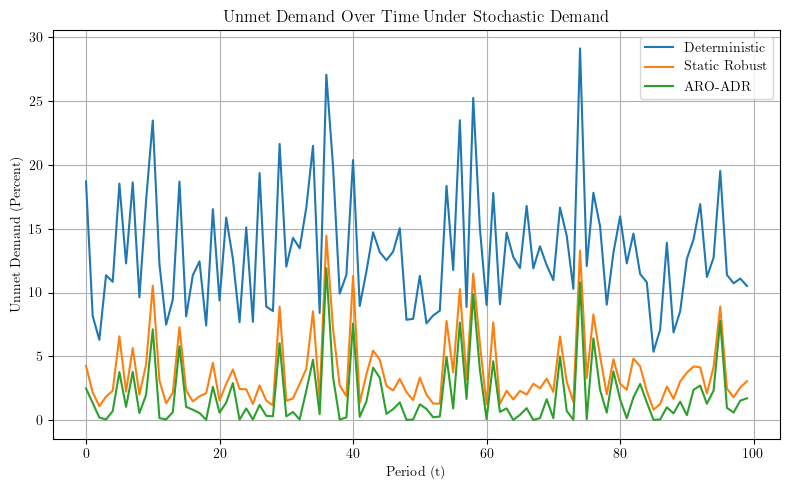

In [ ]:
# extract time series
t = metrics_det["t"]

det_unmet = metrics_det["unmet_pct_realized"]
rob_unmet = metrics_rob["unmet_pct_realized"]
adr_unmet = metrics_adr["unmet_pct_realized"]

plt.figure(figsize=(8,5))

plt.plot(t, det_unmet, label="Deterministic")
plt.plot(t, rob_unmet, label="Static Robust")
plt.plot(t, adr_unmet, label="ARO-ADR")

plt.xlabel("Period (t)")
plt.ylabel("Unmet Demand (Percent)")
plt.title("Unmet Demand Over Time Under Stochastic Demand")

plt.legend()
plt.grid(False)

plt.tight_layout()
plt.savefig("../outputs/figures/unmetdemandgabs.png", dpi=200, bbox_inches="tight")
plt.show()

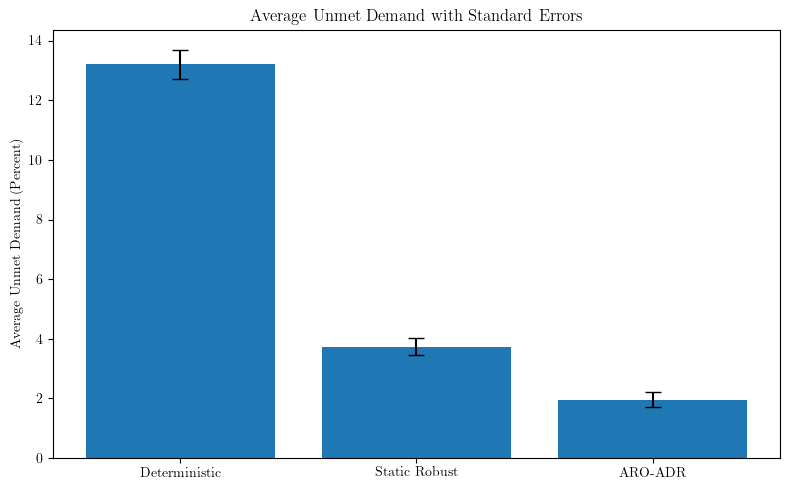

In [88]:
det = np.asarray(metrics_det["unmet_pct_realized"], dtype=float)
rob = np.asarray(metrics_rob["unmet_pct_realized"], dtype=float)
adr = np.asarray(metrics_adr["unmet_pct_realized"], dtype=float)

labels = ["Deterministic", "Static Robust", "ARO-ADR"]
series = [det, rob, adr]

means = [x.mean() for x in series]
ses   = [x.std(ddof=1) / np.sqrt(len(x)) for x in series]  # standard error of the mean

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=ses, capsize=6)
plt.ylabel("Average Unmet Demand (Percent)")
plt.title("Average Unmet Demand with Standard Errors")
plt.tight_layout()
plt.savefig("../outputs/figures/unmetdemandaverage100gabs.png", dpi=200, bbox_inches="tight")
plt.show()

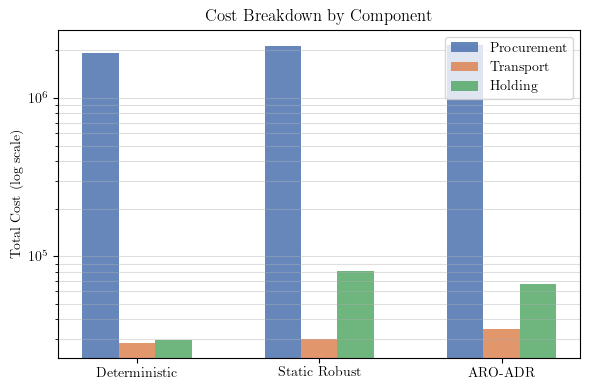

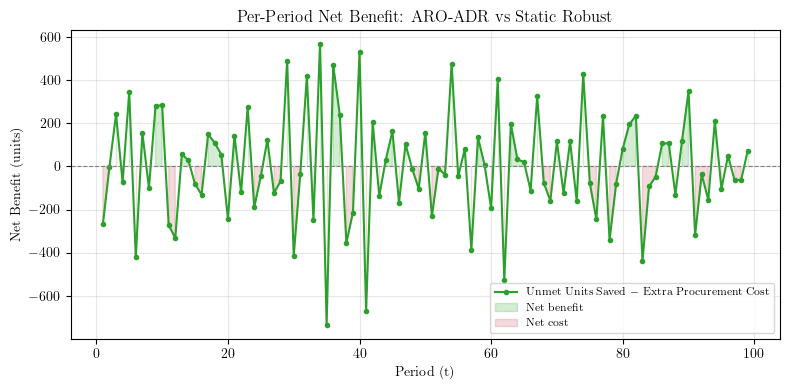

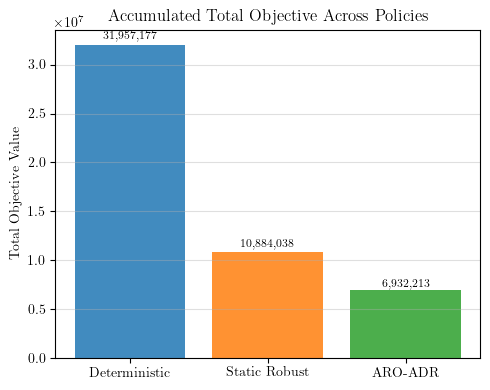

In [ ]:

# helpers
def total(metrics, key):
    return sum(metrics[key])

policies = ["Deterministic", "Static Robust", "ARO-ADR"]
colors   = ["#1f77b4", "#ff7f0e", "#2ca02c"]

# scalars
det_proc  = total(metrics_det, "procurement_cost")
rob_proc  = total(metrics_rob, "procurement_cost")
adr_proc  = total(metrics_adr, "procurement_cost")

det_trans = total(metrics_det, "transport_cost_realized")
rob_trans = total(metrics_rob, "transport_cost_realized")
adr_trans = total(metrics_adr, "transport_cost_realized")

det_hold  = total(metrics_det, "holding_cost_end")
rob_hold  = total(metrics_rob, "holding_cost_end")
adr_hold  = total(metrics_adr, "holding_cost_end")

det_obj   = total(metrics_det, "objective_realized")
rob_obj   = total(metrics_rob, "objective_realized")
adr_obj   = total(metrics_adr, "objective_realized")

det_unmet = total(metrics_det, "total_unmet_units")
rob_unmet = total(metrics_rob, "total_unmet_units")
adr_unmet = total(metrics_adr, "total_unmet_units")

# per-period series
T = len(metrics_rob["procurement_cost"])
t = list(range(T))

net_benefit_per_t = [
    (metrics_rob["total_unmet_units"][i] - metrics_adr["total_unmet_units"][i])
    - (metrics_adr["procurement_cost"][i] - metrics_rob["procurement_cost"][i])
    for i in range(T)
]

# figure 1: cost breakdown (log scale)
proc_vals  = [det_proc,  rob_proc,  adr_proc]
trans_vals = [det_trans, rob_trans, adr_trans]
hold_vals  = [det_hold,  rob_hold,  adr_hold]

x     = np.arange(len(policies))
width = 0.2

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width, proc_vals,  width, label="Procurement", color="#4c72b0", alpha=0.85)
ax.bar(x,         trans_vals, width, label="Transport",   color="#dd8452", alpha=0.85)
ax.bar(x + width, hold_vals,  width, label="Holding",     color="#55a868", alpha=0.85)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(policies)
ax.set_ylabel("Total Cost (log scale)")
ax.set_title("Cost Breakdown by Component")
ax.legend(loc="upper right")
ax.grid(False, axis="y", alpha=0.4, which="both")
plt.tight_layout()
plt.savefig("../outputs/figures/costbreakdown.png", dpi=150)
plt.show()

# figure 2: net benefit time series
# drop period 0 (initialization artifact)
t_plot = t[1:]
net_benefit_plot = net_benefit_per_t[1:]

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(t_plot, net_benefit_plot, color="#2ca02c", linewidth=1.5, marker="o",
        markersize=3, label="Unmet Units Saved − Extra Procurement Cost")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.fill_between(t_plot, net_benefit_plot, 0,
                where=[v >= 0 for v in net_benefit_plot],
                alpha=0.2, color="#2ca02c", label="Net benefit")
ax.fill_between(t_plot, net_benefit_plot, 0,
                where=[v < 0 for v in net_benefit_plot],
                alpha=0.2, color="#c44e52", label="Net cost")

ax.set_xlabel("Period (t)")
ax.set_ylabel("Net Benefit (units)")
ax.set_title("Per-Period Net Benefit: ARO-ADR vs Static Robust")
ax.legend(fontsize=8)
ax.grid(False, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/figures/costbenefit.png", dpi=150)
plt.show()

# figure 3: objective comparison
obj_vals = [det_obj, rob_obj, adr_obj]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(policies, obj_vals, color=colors, alpha=0.85)

ax.set_ylabel("Total Objective Value")
ax.set_title("Accumulated Total Objective Across Policies")
ax.grid(False, axis="y", alpha=0.4)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

for bar, val in zip(bars, obj_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
            f"{val:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../outputs/figures/objectivecomparison.png", dpi=150)
plt.show()

## Route Visualization

In [90]:
def osrm_route(lon1, lat1, lon2, lat2, profile="driving"):
    """
    Returns list of (lat, lon) points for the route polyline using OSRM.
    Inputs are lon/lat floats.
    """
    url = (
        f"https://router.project-osrm.org/route/v1/{profile}/"
        f"{lon1},{lat1};{lon2},{lat2}"
        f"?overview=full&geometries=geojson"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    coords = data["routes"][0]["geometry"]["coordinates"]  # [lon, lat]
    return [(lat, lon) for lon, lat in coords]

# example: gaborone-ish start + a hospital-ish end (replace with actual coordinates)
start_lat, start_lon = -24.676984, 25.887524
end_lat, end_lon     = -24.656991, 25.923933

# get route geometry
route_latlon = osrm_route(start_lon, start_lat, end_lon, end_lat, profile="driving")

# make a road map (openstreetmap tiles)
m = folium.Map(location=[start_lat, start_lon], zoom_start=13, tiles="OpenStreetMap")

# markers
folium.Marker([start_lat, start_lon], tooltip="Start").add_to(m)
folium.Marker([end_lat, end_lon], tooltip="Hospital").add_to(m)

# route polyline
folium.PolyLine(route_latlon, weight=6, opacity=0.9).add_to(m)

# fit bounds so the whole route is visible
m.fit_bounds(route_latlon)

m
m.save("../outputs/figures/gabs_route.html")

In [91]:
# full example: plot optimal routes on a road map using folium + osrm
# requires:
# fac dataframe with columns:
# ["facility name", "service delivery type", "latitude", "longitude"]
# routes_df dataframe with columns:
# ["from_name", "to_name", "flow"]
# helpers

def build_facility_lookup(fac: pd.DataFrame) -> dict:
    # map facility name -> (lat, lon)
    f = fac.copy()
    f["Facility Name"] = f["Facility Name"].astype(str)
    return {
        name: (float(lat), float(lon))
        for name, lat, lon in zip(f["Facility Name"], f["latitude"], f["longitude"])
        if pd.notna(lat) and pd.notna(lon)
    }

@lru_cache(maxsize=2000)
def osrm_route_latlon(lon1: float, lat1: float, lon2: float, lat2: float, profile: str = "driving"):
    # return list of (lat, lon) points along the osrm route
    url = (
        f"https://router.project-osrm.org/route/v1/{profile}/"
        f"{lon1},{lat1};{lon2},{lat2}"
        f"?overview=full&geometries=geojson"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    coords = data["routes"][0]["geometry"]["coordinates"]  # [lon, lat]
    return [(lat, lon) for lon, lat in coords]

def add_route_polyline(m: folium.Map, lat1: float, lon1: float,
                       lat2: float, lon2: float,
                       tooltip: str, weight: float = 5.0,
                       opacity: float = 0.85):
    route = osrm_route_latlon(lon1, lat1, lon2, lat2)
    folium.PolyLine(route, weight=weight, opacity=opacity, tooltip=tooltip).add_to(m)
    return route

# main plotting function

def plot_optimal_routes_on_map(
    fac: pd.DataFrame,
    routes_df: pd.DataFrame,
    from_col: str = "from_name",
    to_col: str = "to_name",
    flow_col: str = "flow",
    min_flow: float = 1e-9,
    zoom_start: int = 11,
    tiles: str = "OpenStreetMap",
):
    lookup = build_facility_lookup(fac)

    df = routes_df.copy()
    df = df[df[flow_col].astype(float) > float(min_flow)].copy()
    df[flow_col] = df[flow_col].astype(float)
    df = df.sort_values(flow_col, ascending=False)

    if df.empty:
        raise ValueError("routes_df is empty after filtering")

    # map center from all endpoints
    lats, lons = [], []
    for a, b in zip(df[from_col].astype(str), df[to_col].astype(str)):
        if a in lookup:
            lats.append(lookup[a][0]); lons.append(lookup[a][1])
        if b in lookup:
            lats.append(lookup[b][0]); lons.append(lookup[b][1])

    center = [float(np.mean(lats)), float(np.mean(lons))]
    m = folium.Map(location=center, zoom_start=zoom_start, tiles=tiles)

    # add facility markers
    used = pd.unique(pd.concat([df[from_col], df[to_col]]).astype(str))
    for name in used:
        if name not in lookup:
            continue
        lat, lon = lookup[name]
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            tooltip=name,
            fill=True,
            fill_opacity=1.0,
            opacity=1.0,
        ).add_to(m)

    # scale line width by flow (log scaling)
    flows = df[flow_col].to_numpy()
    fmin, fmax = float(flows.min()), float(flows.max())

    all_points = []

    for _, row in df.iterrows():
        a = str(row[from_col])
        b = str(row[to_col])
        flow = float(row[flow_col])

        if a not in lookup or b not in lookup:
            continue

        lat1, lon1 = lookup[a]
        lat2, lon2 = lookup[b]

        if fmax > fmin:
            w = 2.5 + 6.5 * (np.log1p(flow) - np.log1p(fmin)) / (np.log1p(fmax) - np.log1p(fmin))
        else:
            w = 6.0

        tooltip = f"{a} → {b} | flow={flow:.4g}"

        try:
            pts = add_route_polyline(
                m, lat1, lon1, lat2, lon2,
                tooltip=tooltip,
                weight=float(w),
                opacity=0.80
            )
            all_points.extend(pts)
        except Exception:
            continue

    if len(all_points) > 0:
        m.fit_bounds(all_points)

    return m

# example usage

# routes_df example (replace with solver output)
# routes_df = pd.dataframe({
# "from_name": ["bac clinic", "artesia clinic"],
# "to_name":   ["airstrip clinic", "bac clinic"],
# "flow":      [120.0, 50.0],
# })

# m = plot_optimal_routes_on_map(fac, routes_df, min_flow=1e-6)
# m
# m.save("../outputs/figures/optimal_routes_gaborone.html")


In [92]:
# plot routes for gaborone only:
# central medical stores -> princess marina hospital -> clinics
# uses folium road tiles + osrm routing polylines
# config
# gaborone center (approx)
gabs_lat, gabs_lon = -24.654, 25.908

# keep facilities within this radius (km)
gabs_radius_km = 30

# name match patterns (edit if spelling differs)
cms_pattern = "central medical"  # e.g., "central medical stores"
pmh_pattern = "princess marina"  # e.g., "princess marina hospital"

# helpers

def haversine_km(lat0, lon0, lat, lon):
    # vectorized haversine distance (km)
    R = 6371.0
    lat0 = np.radians(lat0)
    lon0 = np.radians(lon0)
    lat = np.radians(np.asarray(lat, dtype=float))
    lon = np.radians(np.asarray(lon, dtype=float))
    dlat = lat - lat0
    dlon = lon - lon0
    a = np.sin(dlat / 2) ** 2 + np.cos(lat0) * np.cos(lat) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

def clean_facilities(fac):
    # ensure required columns exist and are numeric
    f = fac.copy()
    f["Facility Name"] = f["Facility Name"].astype(str)
    f["Service Delivery Type"] = f["Service Delivery Type"].astype(str)
    f["latitude"] = pd.to_numeric(f["latitude"], errors="coerce")
    f["longitude"] = pd.to_numeric(f["longitude"], errors="coerce")
    f = f.dropna(subset=["latitude", "longitude"]).reset_index(drop=True)
    return f

@lru_cache(maxsize=2000)
def osrm_route_latlon(lon1, lat1, lon2, lat2, profile="driving"):
    # osrm route geometry as list of (lat, lon)
    url = (
        f"https://router.project-osrm.org/route/v1/{profile}/"
        f"{lon1},{lat1};{lon2},{lat2}"
        f"?overview=full&geometries=geojson"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    data = r.json()
    coords = data["routes"][0]["geometry"]["coordinates"]  # [lon, lat]
    return [(lat, lon) for lon, lat in coords]

def add_route(m, a_name, a_lat, a_lon, b_name, b_lat, b_lon, weight=5.0, opacity=0.85, flow=None):
    # draw one routed polyline
    route = osrm_route_latlon(a_lon, a_lat, b_lon, b_lat, profile="driving")
    if flow is None:
        tip = f"{a_name} → {b_name}"
    else:
        tip = f"{a_name} → {b_name} | flow={float(flow):.4g}"
    folium.PolyLine(route, weight=weight, opacity=opacity, tooltip=tip).add_to(m)
    return route

# 1) subset to gaborone facilities

fac2 = clean_facilities(fac)

fac2["dist_to_gabs_km"] = haversine_km(gabs_lat, gabs_lon, fac2["latitude"], fac2["longitude"])
gabs = fac2[fac2["dist_to_gabs_km"] <= gabs_radius_km].copy()

# 2) locate cms and princess marina

cms_candidates = gabs[gabs["Facility Name"].str.contains(cms_pattern, case=False, na=False)]
pmh_candidates = gabs[gabs["Facility Name"].str.contains(pmh_pattern, case=False, na=False)]

if cms_candidates.empty:
    raise ValueError("no cms match found in gaborone subset; adjust cms_pattern")
if pmh_candidates.empty:
    raise ValueError("no princess marina match found in gaborone subset; adjust pmh_pattern")

cms_row = cms_candidates.sort_values("dist_to_gabs_km").iloc[0]
pmh_row = pmh_candidates.sort_values("dist_to_gabs_km").iloc[0]

cms_name = cms_row["Facility Name"]
pmh_name = pmh_row["Facility Name"]

cms_lat, cms_lon = float(cms_row["latitude"]), float(cms_row["longitude"])
pmh_lat, pmh_lon = float(pmh_row["latitude"]), float(pmh_row["longitude"])

# 3) choose clinics in gaborone (exclude cms/pmh)

is_clinic = gabs["Service Delivery Type"].str.contains("clinic", case=False, na=False)
clinics = gabs[is_clinic].copy()

# drop cms/pmh if they are labeled as clinic
clinics = clinics[~clinics["Facility Name"].isin([cms_name, pmh_name])].copy()

# 4) build routes dataframe (flows optional)

# if optimal flows exist, merging them here:
# example expected shapes:
# flow_cms_to_pmh: scalar
# flow_pmh_to_clinic: dict mapping clinic_name -> flow
flow_cms_to_pmh = None
flow_pmh_to_clinic = None

routes = []
routes.append({"from_name": cms_name, "to_name": pmh_name, "flow": 1.0 if flow_cms_to_pmh is None else float(flow_cms_to_pmh)})

for _, r in clinics.iterrows():
    cname = r["Facility Name"]
    fval = 1.0
    if isinstance(flow_pmh_to_clinic, dict) and cname in flow_pmh_to_clinic:
        fval = float(flow_pmh_to_clinic[cname])
    routes.append({"from_name": pmh_name, "to_name": cname, "flow": fval})

routes_df = pd.DataFrame(routes)

# 5) plot on road map

m = folium.Map(location=[pmh_lat, pmh_lon], zoom_start=12, tiles="OpenStreetMap")

# add cms + pmh markers
folium.Marker([cms_lat, cms_lon], tooltip=cms_name).add_to(m)
folium.Marker([pmh_lat, pmh_lon], tooltip=pmh_name).add_to(m)

# add clinic markers
for _, r in clinics.iterrows():
    folium.CircleMarker(
        location=[float(r["latitude"]), float(r["longitude"])],
        radius=3,
        tooltip=r["Facility Name"],
        fill=True,
        fill_opacity=1.0,
        opacity=1.0,
    ).add_to(m)

# scale line width by flow (log scaling)
flows = routes_df["flow"].to_numpy(dtype=float)
fmin, fmax = float(flows.min()), float(flows.max())

all_pts = []

# cms -> pmh
w = 6.0
all_pts += add_route(m, cms_name, cms_lat, cms_lon, pmh_name, pmh_lat, pmh_lon, weight=w, opacity=0.9, flow=routes_df.iloc[0]["flow"])

# pmh -> clinics
for _, row in routes_df.iloc[1:].iterrows():
    to_name = row["to_name"]
    flow = float(row["flow"])

    rr = clinics[clinics["Facility Name"] == to_name]
    if rr.empty:
        continue
    to_lat = float(rr.iloc[0]["latitude"])
    to_lon = float(rr.iloc[0]["longitude"])

    if fmax > fmin:
        w = 2.0 + 6.0 * (np.log1p(flow) - np.log1p(fmin)) / (np.log1p(fmax) - np.log1p(fmin))
    else:
        w = 4.0

    try:
        all_pts += add_route(m, pmh_name, pmh_lat, pmh_lon, to_name, to_lat, to_lon, weight=float(w), opacity=0.75, flow=flow)
    except Exception:
        continue

# fit bounds
if len(all_pts) > 0:
    m.fit_bounds(all_pts)

m
m.save("../outputs/figures/gaborone_cms_pmh_clinics_routes.html")

## Sensitivity Analysis: Dispersion Mismatch (Kappa)

In [93]:
true_kappas = [2.0, 10.0, 25.0]
assumed_kappas = [2.0, 10.0, 25.0]

T = 20
seed = 42
Gamma = 10.0

results_cross = {}

for true_kappa in true_kappas:
    demand_draws = make_nb_draws_from_mean(
        model_demand_mat,
        kappa=true_kappa,
        T=T,
        seed=seed
    )

    metrics_det_kappa, __ = simulate_policy_under_draws(
        T=T,
        CMS=CMS,
        nodes=model_nodes,
        arcs=model_arcs,
        classes=model_classes,
        dist_km=D_km,
        mu_mat=model_demand_mat,
        demand_draws=demand_draws,
        transport_cost_per_km=0.5,
        shortage_penalty_per_unit=100.0,
        holding_cost_per_unit=0.1,
        procurement_cost_per_unit=1.0,
        supply_multiplier=0.0,
        arc_cap=arc_cap,
        storage_cap_per_node=storage_cap_per_node,
        solver=cp.HIGHS
    )

    for assumed_kappa in assumed_kappas:
        sigma_mat = (
            nb_sigma_from_mean(model_demand_mat, kappa=assumed_kappa)
            .reindex(index=model_nodes, columns=model_classes)
            .fillna(0.0)
            .astype(float)
        )

        metrics_rob_kappa, _ = simulate_static_robust_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS
        )

        metrics_adr_kappa, alpha = simulate_aro_adr_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            arc_df=arcs,  # actual arc dataframe
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS
        )

        results_cross[(true_kappa, assumed_kappa)] = {
            "det": metrics_det_kappa,
            "rob": metrics_rob_kappa,
            "adr": metrics_adr_kappa,
        }

<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
/var/folders/0n/fdwzy91j2j38zqkrjnq3yc040000gn/T/ipykernel_70003/1795480734.py:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
  ax.set_title(f"true $\kappa$={true_kappa}, assumed $\kappa$={assumed_kappa}")
/var/folders/0n/fdwzy91j2j38zqkrjnq3yc040000gn/T/ipykernel_70003/179548073

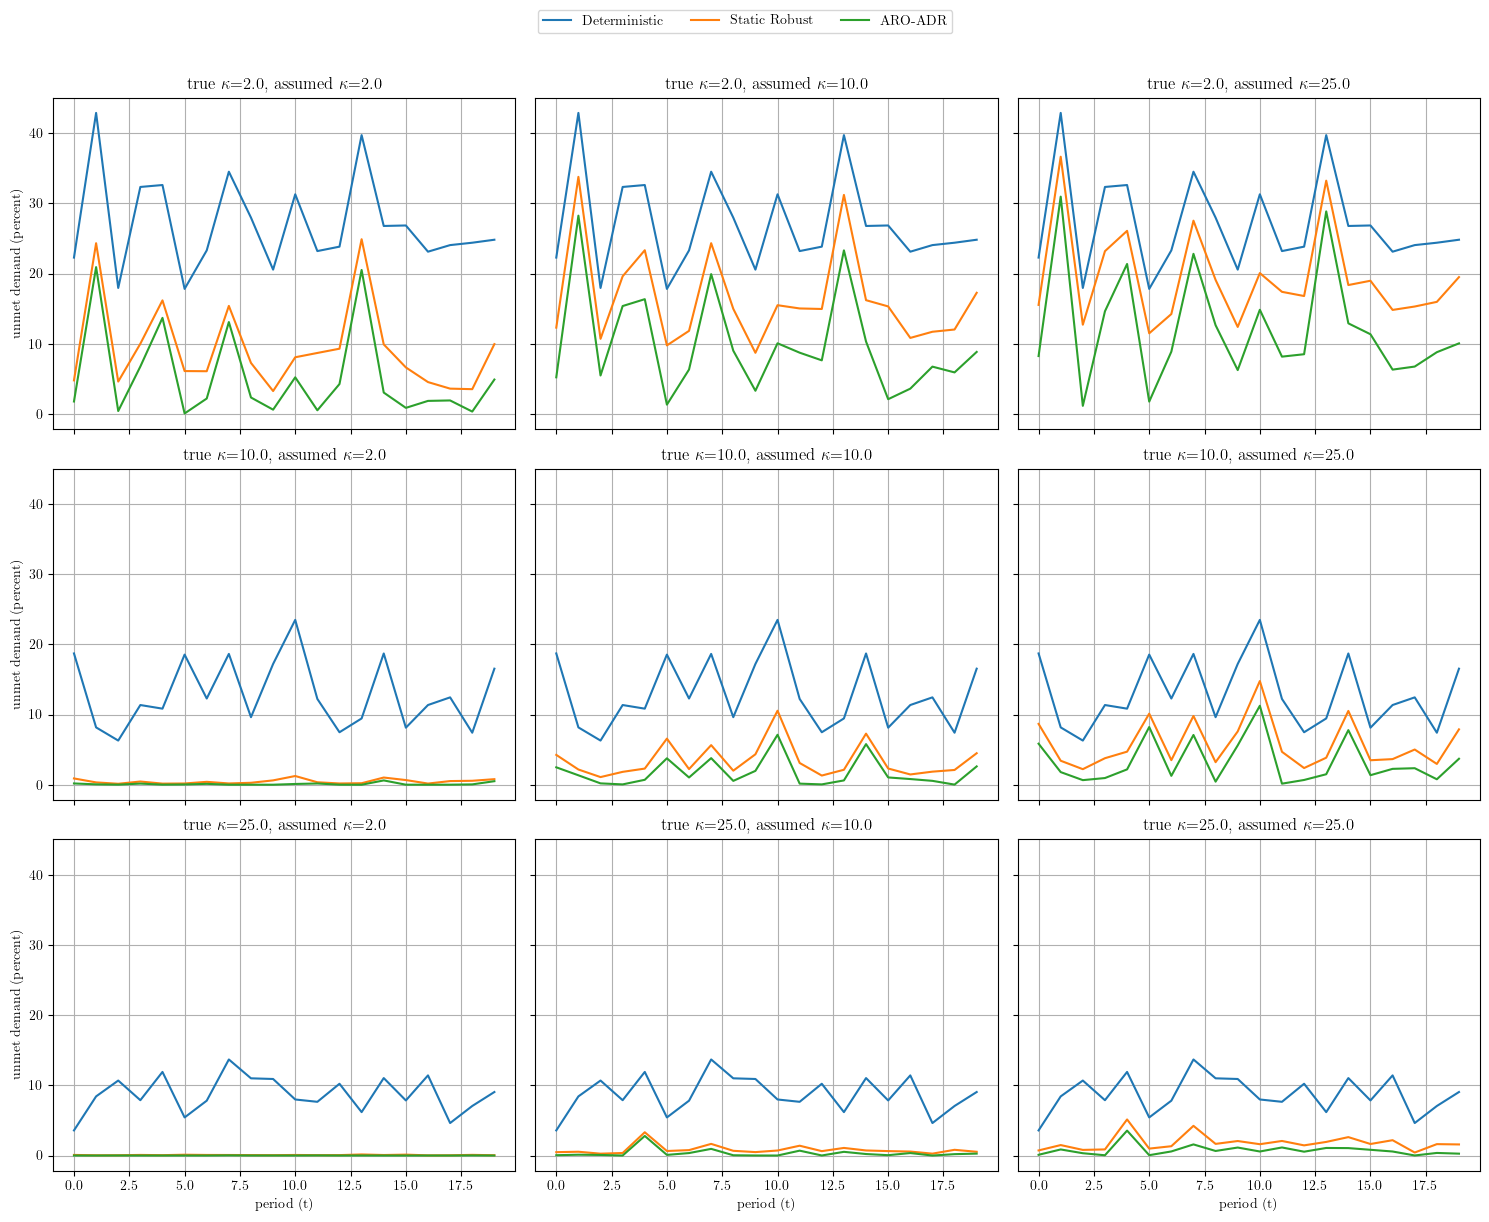

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for i, true_kappa in enumerate(true_kappas):
    for j, assumed_kappa in enumerate(assumed_kappas):
        ax = axes[i, j]
        out = results_cross[(true_kappa, assumed_kappa)]
        
        
        ax.plot(out["det"]["t"], out["det"]["unmet_pct_realized"], label="Deterministic")
        ax.plot(out["rob"]["t"], out["rob"]["unmet_pct_realized"], label="Static Robust")
        ax.plot(out["adr"]["t"], out["adr"]["unmet_pct_realized"], label="ARO-ADR")

        ax.set_title(f"true $\kappa$={true_kappa}, assumed $\kappa$={assumed_kappa}")
        ax.grid(False)

        if i == 2:
            ax.set_xlabel("period (t)")
        if j == 0:
            ax.set_ylabel("unmet demand (percent)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../outputs/figures/kappa.png", dpi=200, bbox_inches="tight")
plt.show()

## Sensitivity Analysis: Uncertainty Budget (Gamma)

In [95]:
true_kappas = [2.0, 10.0, 25.0]
gammas = [1.0, 5.0, 10.0, 20.0, 50.0]

T = 20
seed = 42

# fix assumed kappa to match true for this experiment
results_gamma = {}

for true_kappa in true_kappas:
    demand_draws = make_nb_draws_from_mean(
        model_demand_mat,
        kappa=true_kappa,
        T=T,
        seed=seed
    )

    sigma_mat = (
        nb_sigma_from_mean(model_demand_mat, kappa=true_kappa)
        .reindex(index=model_nodes, columns=model_classes)
        .fillna(0.0)
        .astype(float)
    )

    metrics_det_gamma, __ = simulate_policy_under_draws(
        T=T,
        CMS=CMS,
        nodes=model_nodes,
        arcs=model_arcs,
        classes=model_classes,
        dist_km=D_km,
        mu_mat=model_demand_mat,
        demand_draws=demand_draws,
        transport_cost_per_km=0.5,
        shortage_penalty_per_unit=100.0,
        holding_cost_per_unit=0.1,
        procurement_cost_per_unit=1.0,
        supply_multiplier=0.0,
        arc_cap=arc_cap,
        storage_cap_per_node=storage_cap_per_node,
        solver=cp.HIGHS
    )

    for Gamma in gammas:
        metrics_rob_gamma, _ = simulate_static_robust_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS,
            relax_integrality=True
        )

        metrics_adr_gamma, alpha = simulate_aro_adr_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            arc_df=arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS,
            relax_integrality=True
        )

        results_gamma[(true_kappa, Gamma)] = {
            "det": metrics_det_gamma,
            "rob": metrics_rob_gamma,
            "adr": metrics_adr_gamma,
        }

<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
<>:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
<>:13: SyntaxWarning: "\G" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\G"? A raw string is also an option.
/var/folders/0n/fdwzy91j2j38zqkrjnq3yc040000gn/T/ipykernel_70003/282144409.py:13: SyntaxWarning: "\k" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\k"? A raw string is also an option.
  ax.set_title(f"$\kappa$={true_kappa}, $\Gamma$={Gamma}", fontsize=10)
/var/folders/0n/fdwzy91j2j38zqkrjnq3yc040000gn/T/ipykernel_70003/282144409.py:13: S

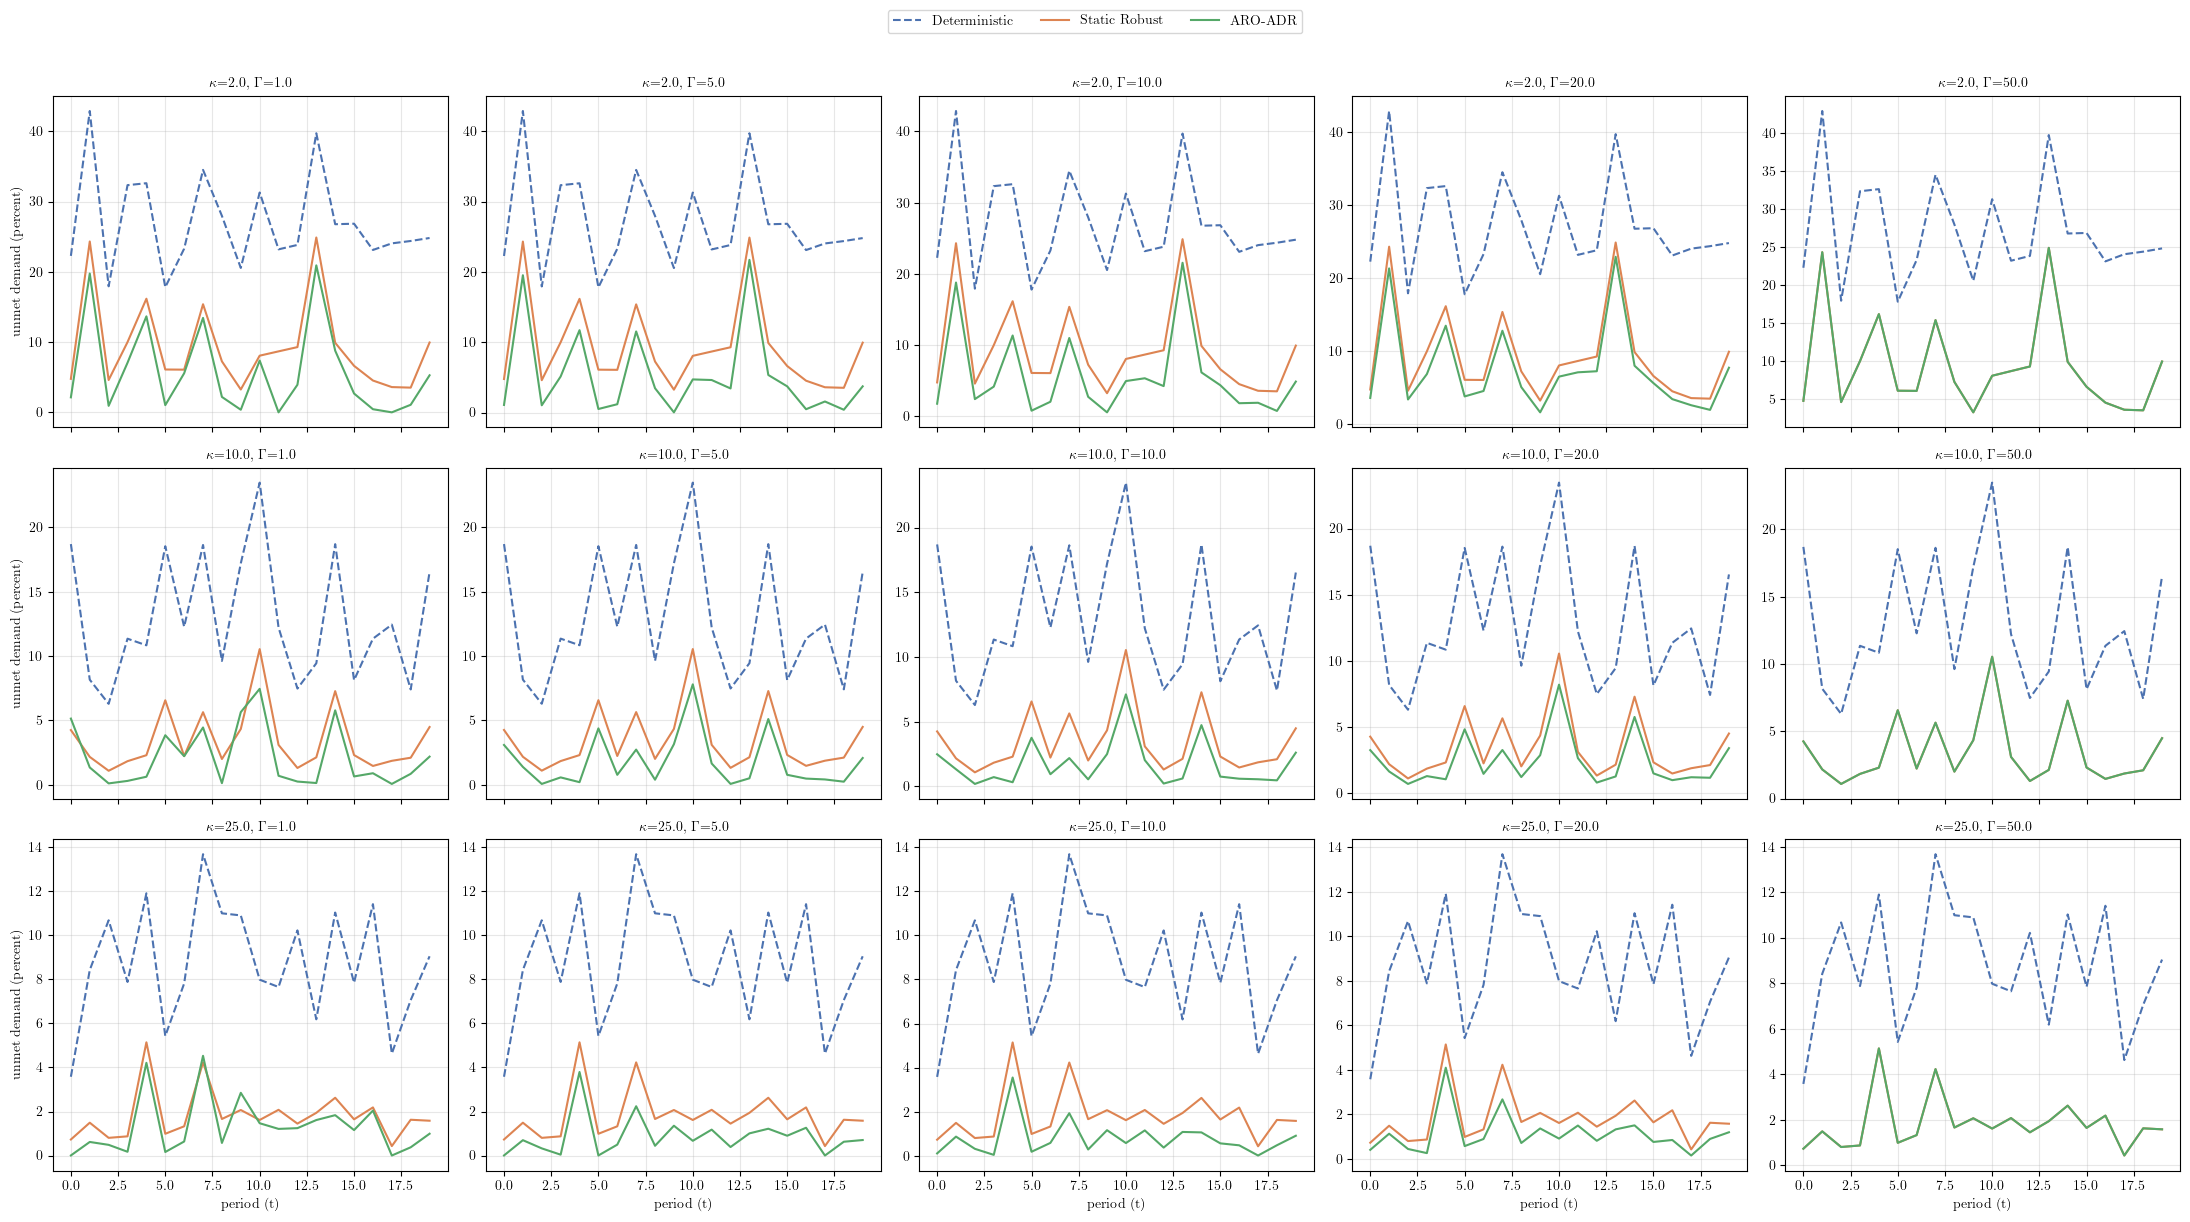

In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(22, 12), sharex=True)

for i, true_kappa in enumerate(true_kappas):
    for j, Gamma in enumerate(gammas):
        ax = axes[i, j]
        out = results_gamma[(true_kappa, Gamma)]

        # det is constant across gamma - but we still have it per (kappa, gamma) key
        ax.plot(out["det"]["t"], out["det"]["unmet_pct_realized"], label="Deterministic", linestyle="--", color="#4C72B0")
        ax.plot(out["rob"]["t"], out["rob"]["unmet_pct_realized"], label="Static Robust", color="#DD8452")
        ax.plot(out["adr"]["t"], out["adr"]["unmet_pct_realized"], label="ARO-ADR",       color="#55A868")

        ax.set_title(f"$\kappa$={true_kappa}, $\Gamma$={Gamma}", fontsize=10)
        ax.grid(False, alpha=0.3)

        if i == 2:
            ax.set_xlabel("period (t)")
        if j == 0:
            ax.set_ylabel("unmet demand (percent)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../outputs/figures/gamma_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

## Sensitivity Analysis: Shortage Penalty

In [97]:
true_kappas = [2.0, 10.0, 25.0]
shortage_penalties = [0.1, 0.5, 0.8, 1.0, 10.0, 20.0, 50.0, 100.0]

T = 20
seed = 42

results_penalty = {}

for true_kappa in true_kappas:
    demand_draws = make_nb_draws_from_mean(
        model_demand_mat,
        kappa=true_kappa,
        T=T,
        seed=seed
    )

    sigma_mat = (
        nb_sigma_from_mean(model_demand_mat, kappa=true_kappa)
        .reindex(index=model_nodes, columns=model_classes)
        .fillna(0.0)
        .astype(float)
    )

    for shortage_penalty in shortage_penalties:
        metrics_det_udv, __ = simulate_policy_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=shortage_penalty,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS
        )

        metrics_rob_udv, _ = simulate_static_robust_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=10.0,  # fixed gamma
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=shortage_penalty,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS,
            relax_integrality=True
        )

        metrics_adr_udv, alpha = simulate_aro_adr_under_draws(
            T=T,
            CMS=CMS,
            nodes=model_nodes,
            arcs=model_arcs,
            arc_df=arcs,
            classes=model_classes,
            dist_km=D_km,
            mu_mat=model_demand_mat,
            demand_draws=demand_draws,
            sigma_mat=sigma_mat,
            Gamma=10.0,  # fixed gamma
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=shortage_penalty,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=arc_cap,
            storage_cap_per_node=storage_cap_per_node,
            solver=cp.HIGHS,
            relax_integrality=True
        )

        results_penalty[(true_kappa, shortage_penalty)] = {
            "det": metrics_det_udv,
            "rob": metrics_rob_udv,
            "adr": metrics_adr_udv,
        }

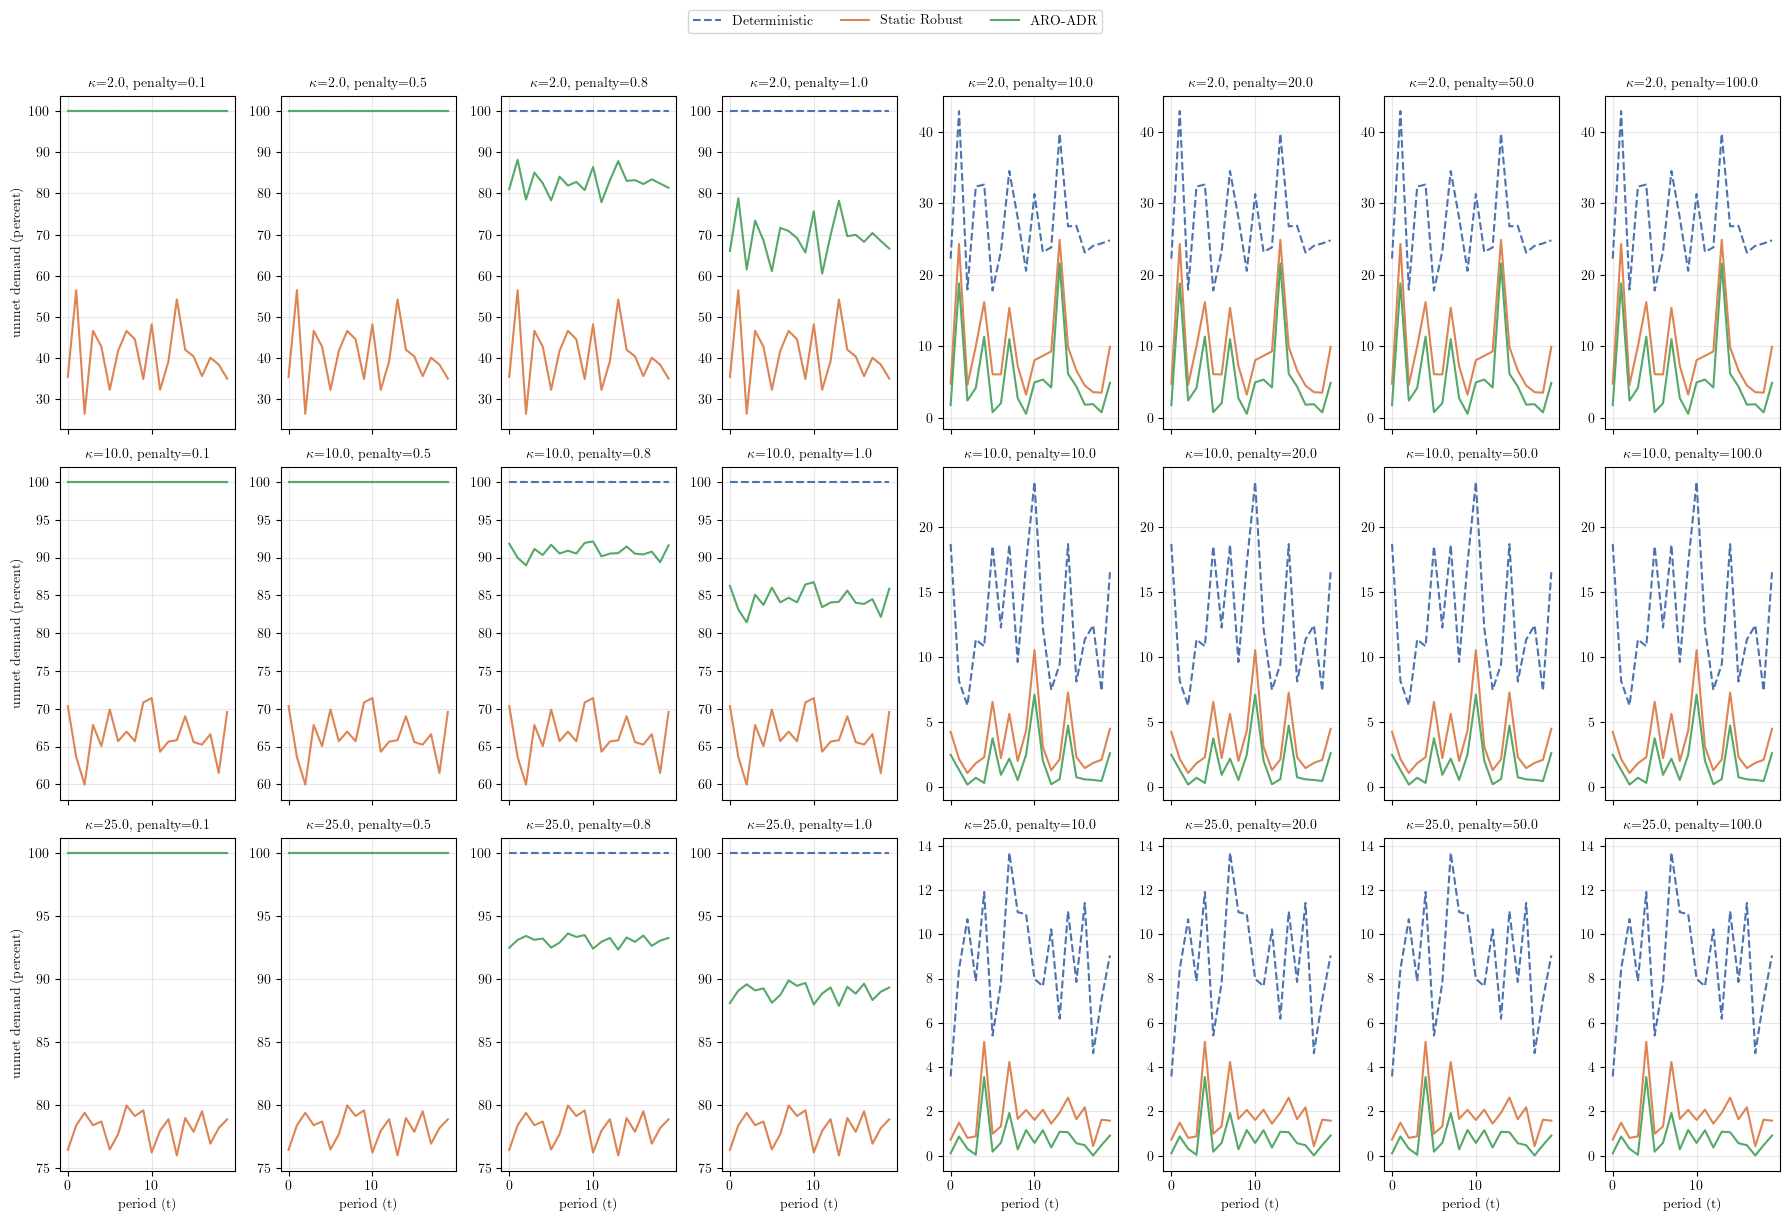

In [ ]:
fig, axes = plt.subplots(3, 8, figsize=(18, 12), sharex=True)

for i, true_kappa in enumerate(true_kappas):
    for j, shortage_penalty in enumerate(shortage_penalties):
        ax = axes[i, j]
        out = results_penalty[(true_kappa, shortage_penalty)]

        ax.plot(out["det"]["t"], out["det"]["unmet_pct_realized"], label="Deterministic", linestyle="--", color="#4C72B0")
        ax.plot(out["rob"]["t"], out["rob"]["unmet_pct_realized"], label="Static Robust", color="#DD8452")
        ax.plot(out["adr"]["t"], out["adr"]["unmet_pct_realized"], label="ARO-ADR",       color="#55A868")

        ax.set_title(r"$\kappa$=" + f"{true_kappa}, penalty={shortage_penalty}", fontsize=10)
        ax.grid(False, alpha=0.3)

        if i == 2:
            ax.set_xlabel("period (t)")
        if j == 0:
            ax.set_ylabel("unmet demand (percent)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../outputs/figures/penalty_sensitivity.png", dpi=200, bbox_inches="tight")
plt.show()

## Seasonal Demand Model

A1 = 0.7249
A2 = -0.5585
s(1)  = 1.8700  (should be 1.87)
s(13) = 0.6700  (should be 0.67)
s(7)  = 0.6237  (emergent April-May)
min   = 0.0789


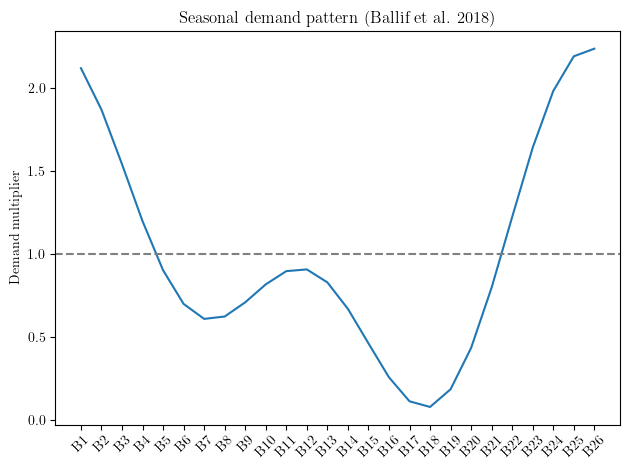

In [99]:
def seasonal_multiplier(t, A1, A2, period=26):
    phi = 2 * np.pi * t / period
    h1 = A1 * np.sin(phi + np.pi / 2)
    h2 = A2 * np.sin(2 * phi - np.pi / 4)
    return 1.0 + h1 + h2

def equations(params):
    A1, A2 = params
    eq1 = seasonal_multiplier(1,  A1, A2) - 1.87  # january peak (+87%)
    eq2 = seasonal_multiplier(13, A1, A2) - 0.67  # december trough (-33%)
    return [eq1, eq2]

A1_sol, A2_sol = fsolve(equations, [0.5, 0.1])

print(f"A1 = {A1_sol:.4f}")
print(f"A2 = {A2_sol:.4f}")
print(f"s(1)  = {seasonal_multiplier(1,  A1_sol, A2_sol):.4f}  (should be 1.87)")
print(f"s(13) = {seasonal_multiplier(13, A1_sol, A2_sol):.4f}  (should be 0.67)")
print(f"s(7)  = {seasonal_multiplier(7,  A1_sol, A2_sol):.4f}  (emergent April-May)")
print(f"min   = {min(seasonal_multiplier(t, A1_sol, A2_sol) for t in range(26)):.4f}")

months = np.arange(26)
multipliers = [seasonal_multiplier(t, A1_sol, A2_sol) for t in months]

plt.plot(months, multipliers)
plt.axhline(1.0, linestyle='--', color='gray')
plt.xticks(range(26), [f'B{i+1}' for i in range(26)], rotation=45)
plt.ylabel('Demand multiplier')
plt.title('Seasonal demand pattern (Ballif et al. 2018)')
plt.tight_layout()
plt.savefig("../outputs/figures/seasonal_multiplier.png", dpi=200, bbox_inches="tight")
plt.show()

In [100]:
def make_nb_draws_seasonal(mu_mat, kappa, T, seed=42, period=26):
    A1, A2 = 0.7249, -0.5585
    rng = np.random.default_rng(seed)
    draws = []

    for t in range(T):
        mu_t = mu_mat.values * seasonal_multiplier(t, A1=A1, A2=A2, period=period)
        mu_t = np.clip(mu_t, 0, None)

        p = kappa / (kappa + mu_t)
        r = kappa
        sample = rng.negative_binomial(r, p)
        draws.append(sample)

    return draws

In [101]:
tb_classes = ['Aminoglycosides', 'Quinolones', 'Lincosamides']
model_demand_mat_tb = model_demand_mat[tb_classes]

In [102]:
demand_draws_ac = np.array(make_nb_draws_seasonal(
    mu_mat=model_demand_mat_tb,
    kappa=50.0,
    T=52
))

sigma_mat = (
    nb_sigma_from_mean(model_demand_mat_tb, kappa=kappa)
    .reindex(index=model_nodes, columns=model_classes)
    .fillna(0.0)
    .astype(float)
)

model_classes = ['Aminoglycosides', 'Quinolones', 'Lincosamides']

T = demand_draws_ac.shape[0]
Gamma = 10.0

metrics_det_ac, __ = simulate_policy_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_rob_ac, robust_mean_ac = simulate_static_robust_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_adr_ac, alpha_hat_ac = simulate_aro_adr_under_draws(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    arc_df=arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

In [103]:
comparison = pd.DataFrame({
    "policy": ["deterministic", "static_robust", "aro_adr"],
    "avg_unmet_pct": [
        metrics_det_ac["unmet_pct_realized"].mean(),
        metrics_rob_ac["unmet_pct_realized"].mean(),
        metrics_adr_ac["unmet_pct_realized"].mean(),
    ],
    "total_unmet_units": [
        metrics_det_ac["total_unmet_units"].sum(),
        metrics_rob_ac["total_unmet_units"].sum(),
        metrics_adr_ac["total_unmet_units"].sum(),
    ],
    "avg_realized_objective": [
        metrics_det_ac["objective_realized"].mean(),
        metrics_rob_ac["objective_realized"].mean(),
        metrics_adr_ac["objective_realized"].mean(),
    ],
    "procurement_cost": [
        metrics_det_ac["procurement_cost"].sum(),
        metrics_rob_ac["procurement_cost"].sum(),
        metrics_adr_ac["procurement_cost"].sum(),
    ]
})

comparison

,policy,avg_unmet_pct,total_unmet_units,avg_realized_objective,procurement_cost
0,deterministic,15.164167,33410.731080,66175.830506,86326.753034
1,static_robust,8.468670,20127.243276,40944.983012,99622.361107
2,aro_adr,11.977634,27309.056752,54631.476008,92428.599173


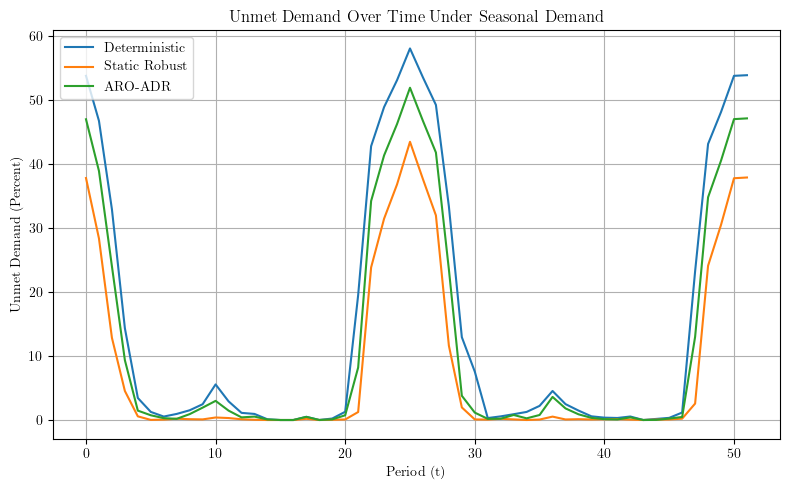

In [104]:
# extract time series
t = metrics_det_ac["t"]

det_unmet = metrics_det_ac["unmet_pct_realized"]
rob_unmet = metrics_rob_ac["unmet_pct_realized"]
adr_unmet = metrics_adr_ac["unmet_pct_realized"]

plt.figure(figsize=(8,5))

plt.plot(t, det_unmet, label="Deterministic")
plt.plot(t, rob_unmet, label="Static Robust")
plt.plot(t, adr_unmet, label="ARO-ADR")

plt.xlabel("Period (t)")
plt.ylabel("Unmet Demand (Percent)")
plt.title("Unmet Demand Over Time Under Seasonal Demand")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../outputs/figures/seasonal_unmet_no_multiplier.png", dpi=200, bbox_inches="tight")
plt.show()

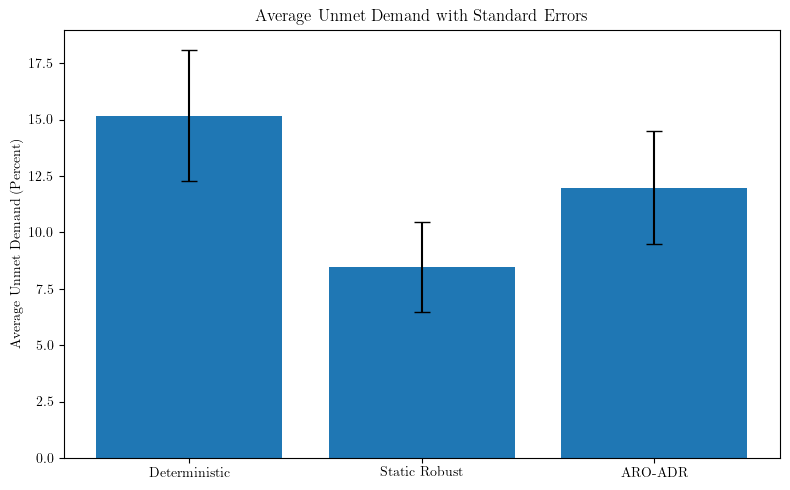

In [105]:
det = np.asarray(metrics_det_ac["unmet_pct_realized"], dtype=float)
rob = np.asarray(metrics_rob_ac["unmet_pct_realized"], dtype=float)
adr = np.asarray(metrics_adr_ac["unmet_pct_realized"], dtype=float)

labels = ["Deterministic", "Static Robust", "ARO-ADR"]
series = [det, rob, adr]

means = [x.mean() for x in series]
ses   = [x.std(ddof=1) / np.sqrt(len(x)) for x in series]  # standard error of the mean

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=ses, capsize=6)
plt.ylabel("Average Unmet Demand (Percent)")
plt.title("Average Unmet Demand with Standard Errors")
plt.tight_layout()
plt.savefig("../outputs/figures/seasonal_unmet_average.png", dpi=200, bbox_inches="tight")
plt.show()

### Seasonal Simulation Functions

In [106]:
def simulate_static_robust_under_draws_seasonal(
    T,
    CMS,
    nodes,
    arcs,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    sigma_mat,
    Gamma,
    seasonal_mu_draws,
    seasonal_sigma_draws,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.0,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    relax_integrality=False,
):
    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = mu_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    sigma_mat = sigma_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = pd.Series(storage_cap_per_node).reindex(nodes).astype(float).to_numpy()

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    metrics = []

    def nk_index(n, k):
        return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()
        mu_np = seasonal_mu_draws[t]
        sigma_np = seasonal_sigma_draws[t]

        constraints = []
        Fbar = cp.Variable((m, K), nonneg=True)
        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        theta = cp.Variable((N, K), nonneg=True)
        pi_plus = cp.Variable((N * K, N), nonneg=True)
        pi_minus = cp.Variable((N * K, N), nonneg=True)

        theta_ship = cp.Variable((N, K), nonneg=True)
        pi_ship_plus = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)
        big_m = 1e5

        for a in range(m):
            constraints.append(cp.sum(Fbar[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                nk = nk_index(n, k)

                inflow_nom = cp.sum(Fbar[in_arcs[n], k]) if in_arcs[n] else 0
                outflow_nom = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])

                rhs = (
                    I0[n, k]
                    + inflow_nom
                    - outflow_nom
                    + supply
                    - demand
                    + u[n, k]
                    - I1[n, k]
                )

                constraints.append(
                    Gamma * theta[n, k]
                    + cp.sum(pi_plus[nk, :])
                    + cp.sum(pi_minus[nk, :])
                    <= rhs
                )

                constraints.append(theta[n, k] + pi_plus[nk, n] >= -sigma_np[n, k])
                constraints.append(theta[n, k] + pi_minus[nk, n] >= sigma_np[n, k])

                rhs_ship = I0[n, k] + inflow_nom + supply - outflow_nom

                constraints.append(
                    Gamma * theta_ship[n, k]
                    + cp.sum(pi_ship_plus[nk, :])
                    + cp.sum(pi_ship_minus[nk, :])
                    <= rhs_ship
                )

                constraints.append(theta_ship[n, k] + pi_ship_plus[nk, n] >= -sigma_np[n, k])
                constraints.append(theta_ship[n, k] + pi_ship_minus[nk, n] >= sigma_np[n, k])

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        obj = cp.Minimize(
            transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
            + shortage_penalty_per_unit * cp.sum(u)
            + holding_cost_per_unit * cp.sum(I1)
            + procurement_cost_per_unit * cp.sum(q)
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        Fbar_val = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)
        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        ship_np = Fbar_val.copy()

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(np.maximum(avail, 0.0), demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = sum(
            transport_cost_per_km * float(dist_km.loc[i, j]) * lam_val[a]
            for a, (i, j) in enumerate(arcs)
        )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())
        proc_cost = procurement_cost_per_unit * float(q_ser.sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())
        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        metrics.append({
            "t": t,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    robust_mu = mu_mat.copy()
    return pd.DataFrame(metrics), robust_mu


def simulate_aro_adr_under_draws_seasonal(
    T,
    CMS,
    nodes,
    arcs,
    arc_df,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    sigma_mat,
    Gamma,
    seasonal_mu_draws,
    seasonal_sigma_draws,
    alpha_lb=-np.inf,
    alpha_ub=np.inf,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.1,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    freeze_alpha_after_first=False,
    relax_integrality=False,
):
    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")
    if Gamma < 0:
        raise ValueError("Gamma must be nonnegative")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = (
        mu_mat.reindex(index=nodes, columns=classes)
        .fillna(0.0)
        .astype(float)
    )

    adaptive_arc_mask = np.array([
        1.0 if (
            row.u_tier in ["cms", "warehouse", "hospital"]
            and row.v_tier in ["clinic", "warehouse", "hospital", "health_post"]
        ) else 0.0
        for row in arc_df.itertuples(index=False)
    ], dtype=float)

    arc_dest_idx = np.array([node_idx[j] for (i, j) in arcs], dtype=int)

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    arcs_from_to = [[[] for _ in range(N)] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        arcs_from_to[node_idx[i]][node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = (
                pd.Series(storage_cap_per_node)
                .reindex(nodes)
                .astype(float)
                .to_numpy()
            )

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    learned_alpha = None
    metrics = []

    def nk_index(n: int, k: int) -> int:
        return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()
        mu_np = seasonal_mu_draws[t]
        sigma_np = seasonal_sigma_draws[t]

        if freeze_alpha_after_first and learned_alpha is not None:
            alpha = None
            alpha_val = np.asarray(learned_alpha, dtype=float)
        else:
            alpha = cp.Variable((m, K))
            alpha_val = None

        Fbar = cp.Variable((m, K), nonneg=True)
        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        theta = cp.Variable((N, K), nonneg=True)
        pi_plus = cp.Variable((N * K, N), nonneg=True)
        pi_minus = cp.Variable((N * K, N), nonneg=True)

        theta_ship = cp.Variable((N, K), nonneg=True)
        pi_ship_plus = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)

        eta = cp.Variable(m, nonneg=True)
        rho_plus = cp.Variable((m, K), nonneg=True)
        rho_minus = cp.Variable((m, K), nonneg=True)

        if alpha is not None:
            constraints += [alpha >= alpha_lb, alpha <= alpha_ub]

        big_m = 1e5

        for a in range(m):
            j = arc_dest_idx[a]
            rhs_cap = arc_cap_vec[a] * lam[a] - cp.sum(Fbar[a, :])

            constraints.append(
                Gamma * eta[a] + cp.sum(rho_plus[a, :] + rho_minus[a, :])
                <= rhs_cap
            )

            for k in range(K):
                coeff = alpha[a, k] if alpha is not None else alpha_val[a, k]
                constraints.append(eta[a] + rho_plus[a, k] >= coeff * sigma_np[j, k])
                constraints.append(eta[a] + rho_minus[a, k] >= -coeff * sigma_np[j, k])

            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                nk = nk_index(n, k)

                inflow_nom = cp.sum(Fbar[in_arcs[n], k]) if in_arcs[n] else 0
                outflow_nom = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])

                rhs = (
                    I0[n, k] + inflow_nom - outflow_nom
                    + supply - demand + u[n, k] - I1[n, k]
                )

                constraints.append(
                    Gamma * theta[n, k]
                    + cp.sum(pi_plus[nk, :])
                    + cp.sum(pi_minus[nk, :])
                    <= rhs
                )

                incoming_adaptive = [a for a in in_arcs[n] if adaptive_arc_mask[a] == 1.0]
                if alpha is not None:
                    coeff_self = (cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0) - 1.0
                else:
                    coeff_self = (float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0) - 1.0

                constraints.append(theta[n, k] + pi_plus[nk, n] >= coeff_self * sigma_np[n, k])
                constraints.append(theta[n, k] + pi_minus[nk, n] >= -coeff_self * sigma_np[n, k])

                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs:
                        continue
                    coeff_out = -cp.sum(alpha[nr_arcs, k]) if alpha is not None else -float(np.sum(alpha_val[nr_arcs, k]))
                    constraints.append(theta[n, k] + pi_plus[nk, r] >= coeff_out * sigma_np[r, k])
                    constraints.append(theta[n, k] + pi_minus[nk, r] >= -coeff_out * sigma_np[r, k])

                rhs_ship = I0[n, k] + inflow_nom + supply - outflow_nom

                constraints.append(
                    Gamma * theta_ship[n, k]
                    + cp.sum(pi_ship_plus[nk, :])
                    + cp.sum(pi_ship_minus[nk, :])
                    <= rhs_ship
                )

                incoming_adaptive = [a for a in in_arcs[n] if adaptive_arc_mask[a] == 1.0]
                if alpha is not None:
                    coeff_self_ship = -cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0
                else:
                    coeff_self_ship = -float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0

                constraints.append(theta_ship[n, k] + pi_ship_plus[nk, n] >= coeff_self_ship * sigma_np[n, k])
                constraints.append(theta_ship[n, k] + pi_ship_minus[nk, n] >= -coeff_self_ship * sigma_np[n, k])

                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs:
                        continue
                    coeff_out_ship = cp.sum(alpha[nr_arcs, k]) if alpha is not None else float(np.sum(alpha_val[nr_arcs, k]))
                    constraints.append(theta_ship[n, k] + pi_ship_plus[nk, r] >= coeff_out_ship * sigma_np[r, k])
                    constraints.append(theta_ship[n, k] + pi_ship_minus[nk, r] >= -coeff_out_ship * sigma_np[r, k])

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        obj = cp.Minimize(
            transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
            + shortage_penalty_per_unit * cp.sum(u)
            + holding_cost_per_unit * cp.sum(I1)
            + procurement_cost_per_unit * cp.sum(q)
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        if alpha is not None:
            learned_alpha = np.asarray(alpha.value, dtype=float)

        Fbar_val = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)
        alpha_use = (
            np.asarray(learned_alpha, dtype=float)
            if learned_alpha is not None
            else np.asarray(alpha_val, dtype=float)
        )

        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        realized_np = realized.to_numpy()
        xi_real = realized_np - mu_np

        ship_np = np.zeros((m, K), dtype=float)
        for a in range(m):
            dest = arc_dest_idx[a]
            if adaptive_arc_mask[a] == 1.0:
                ship_np[a, :] = Fbar_val[a, :] + alpha_use[a, :] * xi_real[dest, :]
            else:
                ship_np[a, :] = Fbar_val[a, :]
        ship_np = np.maximum(ship_np, 0.0)

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(avail, demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = 0.0
        for a, (i, j) in enumerate(arcs):
            transport_cost += (
                transport_cost_per_km
                * float(dist_km.loc[i, j])
                * float(lam_val[a])
            )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())

        if np.isscalar(procurement_cost_per_unit):
            proc_cost = float(procurement_cost_per_unit) * float(q_ser.sum())
        else:
            proc_cost_series = pd.Series(procurement_cost_per_unit).reindex(classes).fillna(0.0)
            proc_cost = float((q_ser * proc_cost_series).sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())
        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        alpha_mean = float(np.mean(learned_alpha)) if learned_alpha is not None else np.nan

        metrics.append({
            "t": t,
            "alpha_opt_mean": alpha_mean,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    learned_alpha_out = pd.DataFrame(
        learned_alpha,
        index=[f"{i}->{j}" for (i, j) in arcs],
        columns=classes,
    )

    return pd.DataFrame(metrics), learned_alpha_out

In [107]:
def simulate_policy_under_draws_seasonal(
    T,
    CMS,
    nodes,
    arcs,
    classes,
    dist_km,
    mu_mat,
    demand_draws,
    seasonal_mu_draws,  # new: (t, n, k) array of seasonal means
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=0.0,
    supply_multiplier=0.0,
    arc_cap=None,
    storage_cap_per_node=None,
    solver=None,
    verbose=False,
    relax_integrality=False,
):
    nodes = list(nodes)
    arcs = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)

    mu_mat = (
        mu_mat.reindex(index=nodes, columns=classes)
        .fillna(0.0)
        .astype(float)
    )

    in_arcs = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        if np.isscalar(storage_cap_per_node):
            cap_vec = np.full(N, float(storage_cap_per_node))
        else:
            cap_vec = (
                pd.Series(storage_cap_per_node)
                .reindex(nodes)
                .astype(float)
                .to_numpy()
            )

    I = pd.DataFrame(0.0, index=nodes, columns=classes)
    I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)

    metrics = []
    nominal_mu = mu_mat.copy()

    for t in range(T):
        I0 = I.to_numpy().copy()
        mu_np = seasonal_mu_draws[t]  # change 1: use seasonal mu for this period

        F = cp.Variable((m, K), nonneg=True)
        u = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y = cp.Variable(m, nonneg=True)
        else:
            lam = cp.Variable(m, integer=True)
            y = cp.Variable(m, boolean=True)
        if relax_integrality:
            constraints += [y <= 1.0]

        big_m = 1e5

        for a in range(m):
            constraints.append(cp.sum(F[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                inflow = cp.sum(F[in_arcs[n], k]) if in_arcs[n] else 0
                outflow = cp.sum(F[out_arcs[n], k]) if out_arcs[n] else 0
                supply = q[k] if nodes[n] == CMS else 0.0
                demand = float(mu_np[n, k])  # change 2: indexed from seasonal array

                constraints.append(
                    I1[n, k]
                    == I0[n, k]
                    + inflow
                    - outflow
                    + supply
                    - demand
                    + u[n, k]
                )

                constraints.append(outflow <= I0[n, k] + inflow + supply)

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        transport_cost_expr = transport_cost_per_km * cp.sum(cp.multiply(c_arc, lam))
        shortage_cost_expr = shortage_penalty_per_unit * cp.sum(u)
        holding_cost_expr = holding_cost_per_unit * cp.sum(I1)
        procurement_cost_expr = procurement_cost_per_unit * cp.sum(q)

        obj = cp.Minimize(
            transport_cost_expr
            + shortage_cost_expr
            + holding_cost_expr
            + procurement_cost_expr
        )

        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)

        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        F_val = np.maximum(np.asarray(F.value, dtype=float), 0.0)

        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)

        ship_np = F_val.copy()

        ship_by_arc = {
            (i, j): pd.Series(ship_np[a, :], index=classes)
            for a, (i, j) in enumerate(arcs)
        }

        q_ser = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet = pd.DataFrame(0.0, index=nodes, columns=classes)

        for n_name in nodes:
            inflow = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)

            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name:
                    inflow = inflow.add(ship_ser, fill_value=0.0)
                if i == n_name:
                    outflow = outflow.add(ship_ser, fill_value=0.0)

            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]

            avail = I.loc[n_name, :] + add_supply + inflow - outflow
            served = np.minimum(avail, demand_vec)

            unmet.loc[n_name, :] = demand_vec - served
            I_next.loc[n_name, :] = avail - served

        I = I_next.copy()

        transport_cost = 0.0
        for a, (i, j) in enumerate(arcs):
            transport_cost += (
                transport_cost_per_km
                * float(dist_km.loc[i, j])
                * float(lam_val[a])
            )

        shortage_cost = shortage_penalty_per_unit * float(unmet.to_numpy().sum())
        holding_cost = holding_cost_per_unit * float(I.to_numpy().sum())

        if np.isscalar(procurement_cost_per_unit):
            proc_cost = float(procurement_cost_per_unit) * float(q_ser.sum())
        else:
            proc_cost_series = (
                pd.Series(procurement_cost_per_unit)
                .reindex(classes)
                .fillna(0.0)
            )
            proc_cost = float((q_ser * proc_cost_series).sum())

        total_demand_realized = float(realized.to_numpy().sum())
        total_unmet = float(unmet.to_numpy().sum())
        unmet_pct = (
            total_unmet / total_demand_realized * 100.0
            if total_demand_realized > 0 else 0.0
        )

        metrics.append({
            "t": t,
            "objective_realized": transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized": shortage_cost,
            "holding_cost_end": holding_cost,
            "procurement_cost": proc_cost,
            "unmet_pct_realized": unmet_pct,
            "total_unmet_units": total_unmet,
            "total_demand_units": total_demand_realized,
            "total_procured_units": float(q_ser.sum()),
        })

    return pd.DataFrame(metrics), nominal_mu

In [108]:
kappa = 50.0
model_classes = ['Aminoglycosides', 'Quinolones', 'Lincosamides']

demand_draws_ac = np.array(make_nb_draws_seasonal(
    mu_mat=model_demand_mat_tb,
    kappa=kappa,
    T=52
))

T = demand_draws_ac.shape[0]
Gamma = 10.0

mu_np_base = (
    model_demand_mat_tb
    .reindex(index=model_nodes, columns=model_classes)
    .fillna(0.0)
    .to_numpy()
)

seasonal_mu_draws = np.array([
    mu_np_base * seasonal_multiplier(t, A1=0.7249, A2=-0.5585)
    for t in range(T)
])

seasonal_sigma_draws = np.sqrt(
    seasonal_mu_draws + seasonal_mu_draws**2 / kappa
)

sigma_mat = (
    nb_sigma_from_mean(model_demand_mat_tb, kappa=kappa)
    .reindex(index=model_nodes, columns=model_classes)
    .fillna(0.0)
    .astype(float)
)

metrics_det_ac, __ = simulate_policy_under_draws_seasonal(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    seasonal_mu_draws=seasonal_mu_draws,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_rob_ac, robust_mean_ac = simulate_static_robust_under_draws_seasonal(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    seasonal_mu_draws=seasonal_mu_draws,
    seasonal_sigma_draws=seasonal_sigma_draws,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

metrics_adr_ac, alpha_hat_ac = simulate_aro_adr_under_draws_seasonal(
    T=T,
    CMS=CMS,
    nodes=model_nodes,
    arcs=model_arcs,
    arc_df=arcs,
    classes=model_classes,
    dist_km=D_km,
    mu_mat=model_demand_mat_tb,
    demand_draws=demand_draws_ac,
    sigma_mat=sigma_mat,
    Gamma=Gamma,
    seasonal_mu_draws=seasonal_mu_draws,
    seasonal_sigma_draws=seasonal_sigma_draws,
    transport_cost_per_km=0.5,
    shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1,
    procurement_cost_per_unit=1,
    supply_multiplier=0.0,
    arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node,
    solver=solver
)

HighsMipSolverData::transformNewIntegerFeasibleSolution tmpSolver.run();


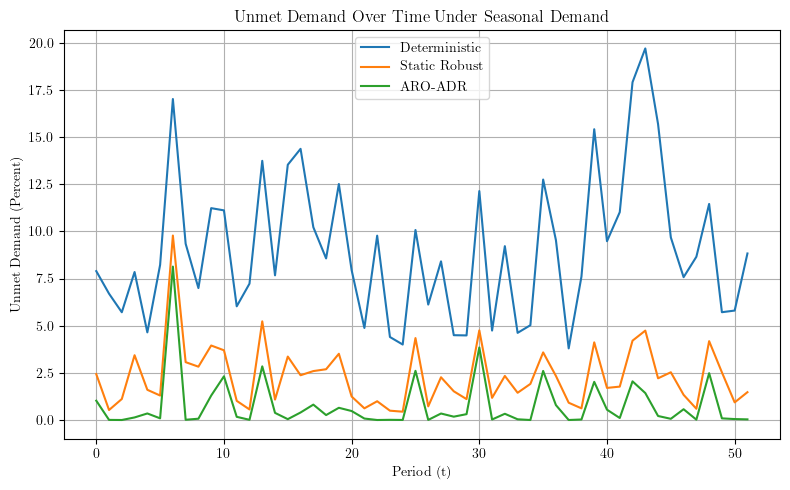

In [109]:
# extract time series
t = metrics_det_ac["t"]

det_unmet = metrics_det_ac["unmet_pct_realized"]
rob_unmet = metrics_rob_ac["unmet_pct_realized"]
adr_unmet = metrics_adr_ac["unmet_pct_realized"]

plt.figure(figsize=(8,5))

plt.plot(t, det_unmet, label="Deterministic")
plt.plot(t, rob_unmet, label="Static Robust")
plt.plot(t, adr_unmet, label="ARO-ADR")

plt.xlabel("Period (t)")
plt.ylabel("Unmet Demand (Percent)")
plt.title("Unmet Demand Over Time Under Seasonal Demand")

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("../outputs/figures/seasonal_unmet_with_multiplier.png", dpi=200, bbox_inches="tight")
plt.show()

In [110]:
comparison = pd.DataFrame({
    "policy": ["deterministic", "static_robust", "aro_adr"],
    "avg_unmet_pct": [
        metrics_det_ac["unmet_pct_realized"].mean(),
        metrics_rob_ac["unmet_pct_realized"].mean(),
        metrics_adr_ac["unmet_pct_realized"].mean(),
    ],
    "total_unmet_units": [
        metrics_det_ac["total_unmet_units"].sum(),
        metrics_rob_ac["total_unmet_units"].sum(),
        metrics_adr_ac["total_unmet_units"].sum(),
    ],
    "avg_realized_objective": [
        metrics_det_ac["objective_realized"].mean(),
        metrics_rob_ac["objective_realized"].mean(),
        metrics_adr_ac["objective_realized"].mean(),
    ],
    "procurement_cost": [
        metrics_det_ac["procurement_cost"].sum(),
        metrics_rob_ac["procurement_cost"].sum(),
        metrics_adr_ac["procurement_cost"].sum(),
    ]
})

comparison

,policy,avg_unmet_pct,total_unmet_units,avg_realized_objective,procurement_cost
0,deterministic,9.070641,9504.585810,20634.730008,110835.501983
1,static_robust,2.333583,2455.666802,7261.626617,118397.882324
2,aro_adr,0.776083,843.354283,4214.362027,119761.635481


## National Simulation Across All Regions

In [111]:
def build_region_instance(target_dhmt):
    target_norm = str(target_dhmt).strip().lower()

    def clean_name_local(x):
        s = str(x).replace("\ufeff", "").replace("\xa0", " ")
        s = " ".join(s.split())
        return s.strip()

    def norm_name_local(s):
        return re.sub(r"\s+", " ", str(s)).strip().lower()

    def norm_district_local(s):
        return re.sub(r"\s+", " ", str(s)).strip().lower()

    def to_tier_local(s):
        s = str(s).lower().strip()
        if "warehouse" in s or "dhmt" in s or "store" in s:
            return "warehouse"
        if "tertiary" in s or "referral" in s or "hospital" in s:
            return "hospital"
        if "health post" in s or "healthpost" in s:
            return "health_post"
        if "clinic" in s or "health centre" in s or "health center" in s:
            return "clinic"
        return "clinic"

    district_map = {
        "barolong": "goodhope",
        "central bobonong": "bobirwa",
        "central boteti": "boteti",
        "central kalahari game reserve": "kgalagadi north",
        "central kgalagadi game reserve": "kgalagadi north",
        "central mahalapye": "mahalapye",
        "central serowe/ palapye": "palapye",
        "central serowe-palapye": "palapye",
        "central tutume": "tutume",
        "ckgr": "kgalagadi north",
        "jwaneng": "goodhope",
        "kweneng west": "kweneng east",
        "ngamiland delta": "ngamiland",
        "ngamiland east": "ngamiland",
        "ngamiland west": "ngamiland",
        "ngwaketse": "southern",
        "ngwaketse central": "southern",
        "ngwaketse west": "southern",
        "orapa": "boteti",
        "selibe phikwe": "selebi-phikwe",
        "selebi-phikwe": "selebi-phikwe",
        "sowa": "boteti",
        "sowa town": "boteti",
        "central madinare": "bobirwa",
        "central molalatau": "bobirwa",
        "kasane": "chobe",
        "kgalagadi rural": "kgalagadi south",
        "kweneng central": "kweneng east",
        "francistown": "francistown",
        "ghanzi farms": "ghanzi",
        "lobatse": "lobatse",
        "pandamatenga": "chobe",
        "tsabong": "kgalagadi south",
    }

    fac_region = fac.copy()
    fac_region["_dhmt_norm"] = fac_region["DHMT"].astype(str).str.strip().str.lower()
    fac_region = fac_region.loc[fac_region["_dhmt_norm"] == target_norm].copy()

    if fac_region.empty:
        raise ValueError(f"no facilities found for DHMT = {target_dhmt}")

    if "facility_name" not in fac_region.columns:
        fac_region = fac_region.rename(columns={"Facility Name": "facility_name"})

    fac_region["facility_name"] = fac_region["facility_name"].map(clean_name_local)
    fac_region["tier"] = fac_region["Service Delivery Type"].apply(to_tier_local)
    fac_region["facility_key"] = fac_region["facility_name"].apply(norm_name_local)

    source_node = clean_name_local(DHMT_SOURCE_MAP[target_dhmt])

    facility_nodes = fac_region["facility_name"].dropna().astype(str).tolist()
    all_nodes = facility_nodes.copy()
    if source_node not in all_nodes:
        all_nodes = [source_node] + all_nodes

    nodes_region = [
        n for n in all_nodes
        if n in dist_matrix_df.index and n in dist_matrix_df.columns
    ]

    if source_node not in nodes_region:
        raise ValueError(f"source node '{source_node}' is missing from the distance matrix")

    if len(nodes_region) == 0:
        raise ValueError(f"no matrix-matched nodes found for DHMT = {target_dhmt}")

    D_region = dist_matrix_df.loc[nodes_region, nodes_region].copy()
    T_region = time_matrix_df.loc[nodes_region, nodes_region].copy()

    tier_map = dict(zip(fac_region["facility_name"], fac_region["tier"]))
    tier_map[source_node] = "warehouse"

    n_hosp = int((fac_region["tier"] == "hospital").sum())

    if n_hosp == 0:
        allowed = {
            "warehouse": ["clinic", "health_post"],
            "hospital": ["clinic", "health_post"],
            "clinic": [],
            "health_post": [],
        }
    else:
        allowed = {
            "warehouse": ["hospital"],
            "hospital": ["clinic", "health_post"],
            "clinic": ["hospital"],
            "health_post": ["hospital"],
        }

    rows = []
    for u in nodes_region:
        u_tier = tier_map.get(u)
        if u_tier is None:
            continue

        for v_tier in allowed.get(u_tier, []):
            cand = [v for v in nodes_region if v != u and tier_map.get(v) == v_tier]
            if not cand:
                continue

            dists = D_region.loc[u, cand].astype(float).replace([np.inf, -np.inf], np.nan).dropna()
            if dists.empty:
                continue

            for v, dist_val in dists.items():
                time_val = T_region.loc[u, v]
                if pd.isna(time_val) or np.isinf(time_val):
                    continue

                rows.append({
                    "u": u,
                    "v": v,
                    "u_tier": u_tier,
                    "v_tier": v_tier,
                    "dist_km": float(dist_val) / 1000.0,
                    "time_min": float(time_val) / 60.0,
                })

    arcs_region_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["u", "v"])
        .reset_index(drop=True)
    )

    if arcs_region_df.empty:
        raise ValueError(f"no arcs created for DHMT = {target_dhmt}")

    model_arcs_region = [(row.u, row.v) for row in arcs_region_df.itertuples(index=False)]

    hosp_df = results_with_dhmt["Hospital"].copy()
    clinic_df = results_with_dhmt["Clinic"].copy()
    hp_df = results_with_dhmt["Health Post"].copy()

    mask_h = hosp_df["assigned_dhmt_hospital"].astype(str).str.strip().str.lower().eq(target_norm)
    mask_c = clinic_df["assigned_dhmt_clinic"].astype(str).str.strip().str.lower().eq(target_norm)
    mask_hp = hp_df["assigned_dhmt_health_post"].astype(str).str.strip().str.lower().eq(target_norm)

    mask_any = mask_h | mask_c | mask_hp
    pop_dhmt_region = hosp_df.loc[mask_any].copy()

    if pop_dhmt_region.empty:
        raise ValueError(f"no population points assigned to DHMT = {target_dhmt}")

    merged_region = pop_dhmt_region.copy()
    merged_region["pop_id"] = merged_region.index

    merged_region = merged_region.rename(columns={
        "Facility Name_1": "nearest_Hospital_name",
        "latitude_1": "nearest_Hospital_lat",
        "longitude_1": "nearest_Hospital_lon",
        "DHMT_1": "nearest_Hospital_dhmt",
        "crow_dist_km_1": "crow_dist_km_Hospital",
        "osrm_dist_km_Hospital": "route_km_to_Hospital",
        "osrm_time_min_Hospital": "route_min_to_Hospital",
    })

    clinic_sub = clinic_df.copy()
    clinic_sub["pop_id"] = clinic_sub.index
    clinic_sub = clinic_sub[[
        "pop_id",
        "Facility Name_1", "latitude_1", "longitude_1",
        "DHMT_1", "crow_dist_km_1",
        "osrm_dist_km_Clinic", "osrm_time_min_Clinic"
    ]].rename(columns={
        "Facility Name_1": "nearest_Clinic_name",
        "latitude_1": "nearest_Clinic_lat",
        "longitude_1": "nearest_Clinic_lon",
        "DHMT_1": "nearest_Clinic_dhmt",
        "crow_dist_km_1": "crow_dist_km_Clinic",
        "osrm_dist_km_Clinic": "route_km_to_Clinic",
        "osrm_time_min_Clinic": "route_min_to_Clinic",
    })

    hp_sub = hp_df.copy()
    hp_sub["pop_id"] = hp_sub.index
    hp_sub = hp_sub[[
        "pop_id",
        "Facility Name_1", "latitude_1", "longitude_1",
        "DHMT_1", "crow_dist_km_1",
        "osrm_dist_km_Health Post", "osrm_time_min_Health Post"
    ]].rename(columns={
        "Facility Name_1": "nearest_HealthPost_name",
        "latitude_1": "nearest_HealthPost_lat",
        "longitude_1": "nearest_HealthPost_lon",
        "DHMT_1": "nearest_HealthPost_dhmt",
        "crow_dist_km_1": "crow_dist_km_HealthPost",
        "osrm_dist_km_Health Post": "route_km_to_HealthPost",
        "osrm_time_min_Health Post": "route_min_to_HealthPost",
    })

    merged_region = merged_region.merge(clinic_sub, on="pop_id", how="left")
    merged_region = merged_region.merge(hp_sub, on="pop_id", how="left")
    merged_region = merged_region.reset_index(drop=True)

    POP_COL = "total_population"
    DISTRICT_COL = "district"

    merged_region[POP_COL] = merged_region[POP_COL].astype(str).str.replace(",", "", regex=False)
    merged_region[POP_COL] = pd.to_numeric(merged_region[POP_COL], errors="coerce")
    if merged_region[POP_COL].isna().any():
        raise ValueError(f"unparsed total_population values in DHMT = {target_dhmt}")

    clinic_choice = merged_region[[
        "pop_id", "nearest_Clinic_name", "crow_dist_km_Clinic", DISTRICT_COL, POP_COL
    ]].copy().rename(columns={
        "nearest_Clinic_name": "facility_name",
        "crow_dist_km_Clinic": "dist_km",
        DISTRICT_COL: "district",
        POP_COL: "pop_total",
    })
    clinic_choice["facility_type"] = "clinic"

    hp_choice = merged_region[[
        "pop_id", "nearest_HealthPost_name", "crow_dist_km_HealthPost", DISTRICT_COL, POP_COL
    ]].copy().rename(columns={
        "nearest_HealthPost_name": "facility_name",
        "crow_dist_km_HealthPost": "dist_km",
        DISTRICT_COL: "district",
        POP_COL: "pop_total",
    })
    hp_choice["facility_type"] = "health_post"

    choices = pd.concat([clinic_choice, hp_choice], ignore_index=True)
    choices["facility_name"] = choices["facility_name"].astype(str).str.strip()
    choices["dist_km"] = pd.to_numeric(choices["dist_km"], errors="coerce")
    choices = choices.replace({"facility_name": {"": np.nan, "nan": np.nan}})
    choices = choices.dropna(subset=["facility_name", "dist_km"])

    closest = (
        choices.sort_values(["pop_id", "dist_km"])
        .drop_duplicates(subset=["pop_id"], keep="first")
    )

    pop_fac_region = (
        closest.groupby(["facility_name", "facility_type", "district"], as_index=False)["pop_total"].sum()
    )

    if pop_fac_region.empty:
        raise ValueError(f"no downstream pop-fac assignments for DHMT = {target_dhmt}")

    pop_fac_region["district_key"] = pop_fac_region["district"].apply(norm_district_local).replace(district_map)
    pop_fac_region["district_key_raw"] = pop_fac_region["district_key"]

    adm_map = (
        district_adm.drop_duplicates("district_key")
        .set_index("district_key")["annual_admissions_est"]
    )
    pop_fac_region["annual_admissions_est"] = pop_fac_region["district_key"].map(adm_map)

    missing_adm = sorted(
        pop_fac_region.loc[pop_fac_region["annual_admissions_est"].isna(), "district_key"]
        .dropna().unique().tolist()
    )
    if missing_adm:
        raise ValueError(f"missing admissions estimates for district keys: {missing_adm}")

    pop_fac_region["district_pop_total"] = pop_fac_region.groupby("district_key")["pop_total"].transform("sum")
    pop_fac_region["facility_pop_share"] = np.where(
        pop_fac_region["district_pop_total"] > 0,
        pop_fac_region["pop_total"] / pop_fac_region["district_pop_total"],
        0.0
    )
    pop_fac_region["facility_admissions_annual"] = (
        pop_fac_region["facility_pop_share"] * pop_fac_region["annual_admissions_est"]
    )

    age_work = age_df.copy()
    age_work["district_key"] = age_work["district"].astype(str).str.strip().str.lower().replace(district_map)

    age_df_agg_region = (
        age_work.groupby(["district_key", "agegroup"], as_index=False)["share"].sum()
    )

    pop_fac_age_region = pop_fac_region.merge(
        age_df_agg_region[["district_key", "agegroup", "share"]],
        on="district_key",
        how="left"
    )

    missing_age = sorted(
        pop_fac_age_region.loc[pop_fac_age_region["share"].isna(), "district_key"]
        .dropna().unique().tolist()
    )
    if missing_age:
        raise ValueError(f"missing age shares for district keys: {missing_age}")

    PLANNING_HORIZON_WEEKS = 2
    AVG_LOS_DAYS = 5.0

    pop_fac_age_region["pop_count"] = pop_fac_age_region["pop_total"] * pop_fac_age_region["share"]
    pop_fac_age_region["admissions_annual"] = (
        pop_fac_age_region["facility_admissions_annual"] * pop_fac_age_region["share"]
    )
    pop_fac_age_region["admissions"] = pop_fac_age_region["admissions_annual"] * (PLANNING_HORIZON_WEEKS / 52.0)
    pop_fac_age_region["patient_days"] = pop_fac_age_region["admissions"] * AVG_LOS_DAYS
    pop_fac_age_region["facility_key"] = pop_fac_age_region["facility_name"].apply(norm_name_local)

    pop_fac_age_region = pop_fac_age_region[[
        "facility_name", "facility_key", "facility_type", "district", "district_key",
        "agegroup", "pop_count", "admissions_annual", "admissions", "patient_days"
    ]]

    pop_fac_age_region = pop_fac_age_region.merge(
        fac_region[["facility_key", "tier"]],
        on="facility_key",
        how="left"
    )

    pop_fac_age_region["tier"] = pop_fac_age_region["tier"].fillna("clinic")
    tier_to_hospital_type = {
        "clinic": "Clinic",
        "health_post": "Clinic",
        "hospital": "Primary",
        "warehouse": "Tertiary",
    }
    pop_fac_age_region["hospital_type"] = pop_fac_age_region["tier"].map(tier_to_hospital_type)

    if pop_fac_age_region["hospital_type"].isna().any():
        bad = pop_fac_age_region.loc[
            pop_fac_age_region["hospital_type"].isna(), "tier"
        ].dropna().unique().tolist()
        raise ValueError(f"unmapped tiers in downstream demand build: {bad}")

    demand_fac_region = expected_class_counts_by_facility(pop_fac_age_region)

    pop_hosp_region = (
        merged_region.groupby(["nearest_Hospital_name", DISTRICT_COL], as_index=False)[POP_COL]
        .sum()
        .rename(columns={
            "nearest_Hospital_name": "facility_name",
            DISTRICT_COL: "district",
            POP_COL: "pop_total",
        })
    )

    pop_hosp_region["facility_type"] = "hospital"
    pop_hosp_region["district_key"] = pop_hosp_region["district"].apply(norm_district_local).replace(district_map)
    pop_hosp_region["district_key_raw"] = pop_hosp_region["district_key"]
    pop_hosp_region["annual_admissions_est"] = pop_hosp_region["district_key"].map(adm_map)

    missing_hosp_adm = sorted(
        pop_hosp_region.loc[pop_hosp_region["annual_admissions_est"].isna(), "district_key"]
        .dropna().unique().tolist()
    )
    if missing_hosp_adm:
        raise ValueError(f"missing hospital admissions estimates for district keys: {missing_hosp_adm}")

    pop_hosp_region["district_pop_total"] = pop_hosp_region.groupby("district_key")["pop_total"].transform("sum")
    pop_hosp_region["facility_pop_share"] = np.where(
        pop_hosp_region["district_pop_total"] > 0,
        pop_hosp_region["pop_total"] / pop_hosp_region["district_pop_total"],
        0.0
    )
    pop_hosp_region["facility_admissions_annual"] = (
        pop_hosp_region["facility_pop_share"] * pop_hosp_region["annual_admissions_est"]
    )

    pop_hosp_age_region = pop_hosp_region.merge(
        age_df_agg_region[["district_key", "agegroup", "share"]],
        on="district_key",
        how="left"
    )

    missing_hosp_age = sorted(
        pop_hosp_age_region.loc[pop_hosp_age_region["share"].isna(), "district_key"]
        .dropna().unique().tolist()
    )
    if missing_hosp_age:
        raise ValueError(f"missing hospital age shares for district keys: {missing_hosp_age}")

    pop_hosp_age_region["pop_count"] = pop_hosp_age_region["pop_total"] * pop_hosp_age_region["share"]
    pop_hosp_age_region["admissions_annual"] = (
        pop_hosp_age_region["facility_admissions_annual"] * pop_hosp_age_region["share"]
    )
    pop_hosp_age_region["admissions"] = pop_hosp_age_region["admissions_annual"] * (PLANNING_HORIZON_WEEKS / 52.0)
    pop_hosp_age_region["patient_days"] = pop_hosp_age_region["admissions"] * AVG_LOS_DAYS
    pop_hosp_age_region["facility_key"] = pop_hosp_age_region["facility_name"].apply(norm_name_local)

    pop_hosp_age_region = pop_hosp_age_region[[
        "facility_name", "facility_key", "facility_type", "district", "district_key",
        "agegroup", "pop_count", "admissions_annual", "admissions", "patient_days"
    ]]

    pop_hosp_age_region = pop_hosp_age_region.merge(
        fac_region[["facility_key", "tier"]],
        on="facility_key",
        how="left"
    )
    pop_hosp_age_region["tier"] = pop_hosp_age_region["tier"].fillna("hospital")
    pop_hosp_age_region["hospital_type"] = pop_hosp_age_region["tier"].map(tier_to_hospital_type)

    if pop_hosp_age_region["hospital_type"].isna().any():
        bad = pop_hosp_age_region.loc[
            pop_hosp_age_region["hospital_type"].isna(), "tier"
        ].dropna().unique().tolist()
        raise ValueError(f"unmapped tiers in hospital demand build: {bad}")

    hospital_demand_region = expected_class_counts_by_facility(pop_hosp_age_region)

    all_demand_fac_region = pd.concat(
        [demand_fac_region, hospital_demand_region],
        ignore_index=True
    )

    node_demand_mat_region = build_node_demand_matrix(all_demand_fac_region)

    model_classes_region = sorted(node_demand_mat_region.columns.tolist())
    model_nodes_region = list(D_region.index)

    model_demand_mat_region = (
        node_demand_mat_region
        .reindex(index=model_nodes_region, columns=model_classes_region)
        .fillna(0.0)
        .astype(float)
    )

    sigma_mat_region = nb_sigma_from_mean(model_demand_mat_region, kappa=10.0).reindex(
        index=model_nodes_region,
        columns=model_classes_region
    ).fillna(0.0).astype(float)

    return {
        "region": target_dhmt,
        "CMS": source_node,
        "nodes": model_nodes_region,
        "arcs": model_arcs_region,
        "arc_df": arcs_region_df,
        "dist_km": D_region / 1000.0,
        "mu_mat": model_demand_mat_region,
        "sigma_mat": sigma_mat_region,
        "storage_cap_per_node": None,
        "arc_cap": 2000.0,
    }

In [112]:
all_regions = sorted(fac["DHMT"].dropna().astype(str).unique().tolist())
all_regions = [r for r in all_regions if r != "--"]

In [113]:
results = []
failures = []

for region in all_regions:
    try:
        inst = build_region_instance(region)

        T = 20
        kappa = 10.0
        seed = 42
        Gamma = 10.0

        demand_draws = make_nb_draws_from_mean(
            inst["mu_mat"],
            kappa=kappa,
            T=T,
            seed=seed,
        )

        classes = inst["mu_mat"].columns.tolist()

        # deterministic
        metrics_det_region, _ = simulate_policy_under_draws(
            T=T,
            CMS=inst["CMS"],
            nodes=inst["nodes"],
            arcs=inst["arcs"],
            classes=classes,
            dist_km=inst["dist_km"],
            mu_mat=inst["mu_mat"],
            demand_draws=demand_draws,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=2000.0,
            storage_cap_per_node=None,
            solver=cp.HIGHS,
            verbose=False,
            relax_integrality=True
        )
        metrics_det_region["region"] = region
        metrics_det_region["model"] = "deterministic"
        results.append(metrics_det_region)

        # static robust
        metrics_rob_region, _ = simulate_static_robust_under_draws(
            T=T,
            CMS=inst["CMS"],
            nodes=inst["nodes"],
            arcs=inst["arcs"],
            classes=classes,
            dist_km=inst["dist_km"],
            mu_mat=inst["mu_mat"],
            demand_draws=demand_draws,
            sigma_mat=inst["sigma_mat"],
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=2000.0,
            storage_cap_per_node=None,
            solver=cp.HIGHS,
            verbose=False,
            relax_integrality=True
        )
        metrics_rob_region["region"] = region
        metrics_rob_region["model"] = "static_robust"
        results.append(metrics_rob_region)

        # aro-adr
        metrics_aro_region, _ = simulate_aro_adr_under_draws(
            T=T,
            CMS=inst["CMS"],
            nodes=inst["nodes"],
            arcs=inst["arcs"],
            arc_df=inst["arc_df"],
            classes=classes,
            dist_km=inst["dist_km"],
            mu_mat=inst["mu_mat"],
            demand_draws=demand_draws,
            sigma_mat=inst["sigma_mat"],
            Gamma=Gamma,
            transport_cost_per_km=0.5,
            shortage_penalty_per_unit=100.0,
            holding_cost_per_unit=0.1,
            procurement_cost_per_unit=1.0,
            supply_multiplier=0.0,
            arc_cap=2000.0,
            storage_cap_per_node=None,
            solver=cp.HIGHS,
            verbose=False,
            relax_integrality=True
        )
        metrics_aro_region["region"] = region
        metrics_aro_region["model"] = "aro_adr"
        results.append(metrics_aro_region)

        print("done:", region)

    except Exception as e:
        failures.append((region, str(e)))
        print("failed:", region, e)

results_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()
failures_df = pd.DataFrame(failures, columns=["region", "error"]) if failures else pd.DataFrame()

done: Boteti
done: Chobe
done: Ghanzi
done: Greater Francistown
done: Greater Gaborone
done: Greater Lobatse
done: Greater Phikwe
done: Kgalagadi North
done: Kgalagadi South
done: Kgatleng
done: Kweneng
done: Mahalapye
done: Ngami
done: North East
done: Okavango
done: Serowe-Palapye
done: Southern
done: Tutume


### National Results: Unmet Demand Heatmaps

In [114]:
# load shapefile
gdf = gpd.read_file("botswana.geojson")

# region -> district crosswalk
region_to_district = {
    "Boteti":              "Central District",
    "Chobe":               "Chobe District",
    "Ghanzi":              "Ghanzi District",
    "Greater Francistown": "North-East District",
    "Greater Gaborone":    "South-East District",
    "Greater Lobatse":     "South-East District",
    "Greater Phikwe":      "Central District",
    "Kgalagadi North":     "Kgalagadi District",
    "Kgalagadi South":     "Kgalagadi District",
    "Kgatleng":            "Kgatleng District",
    "Kweneng":             "Kweneng District",
    "Mahalapye":           "Central District",
    "Ngami":               "North-West District",
    "North East":          "North-East District",
    "Okavango":            "North-West District",
    "Serowe-Palapye":      "Central District",
    "Southern":            "Southern District",
    "Tutume":              "Central District",
}

models = ["deterministic", "static_robust", "aro_adr"]
model_labels = {
    "deterministic": "Deterministic",
    "static_robust": "Static Robust",
    "aro_adr":       "ARO-ADR",
}

# compute average unmet demand per region per model
summary = (
    results_df
    .groupby(["region", "model"])["unmet_pct_realized"]
    .mean()
    .reset_index()
    .rename(columns={"unmet_pct_realized": "avg_unmet_pct"})
)

records = []
for region, district in region_to_district.items():
    for model in models:
        val = summary.loc[
            (summary["region"] == region) & (summary["model"] == model),
            "avg_unmet_pct"
        ]
        if not val.empty:
            records.append({
                "shapeName": district,
                "model": model,
                "avg_unmet_pct": val.values[0]
            })

district_df = (
    pd.DataFrame(records)
    .groupby(["shapeName", "model"])["avg_unmet_pct"]
    .mean()
    .reset_index()
)

vmin = district_df["avg_unmet_pct"].min()
vmax = district_df["avg_unmet_pct"].max()
cmap = "RdYlGn_r"

/var/folders/0n/fdwzy91j2j38zqkrjnq3yc040000gn/T/ipykernel_70003/1286706840.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


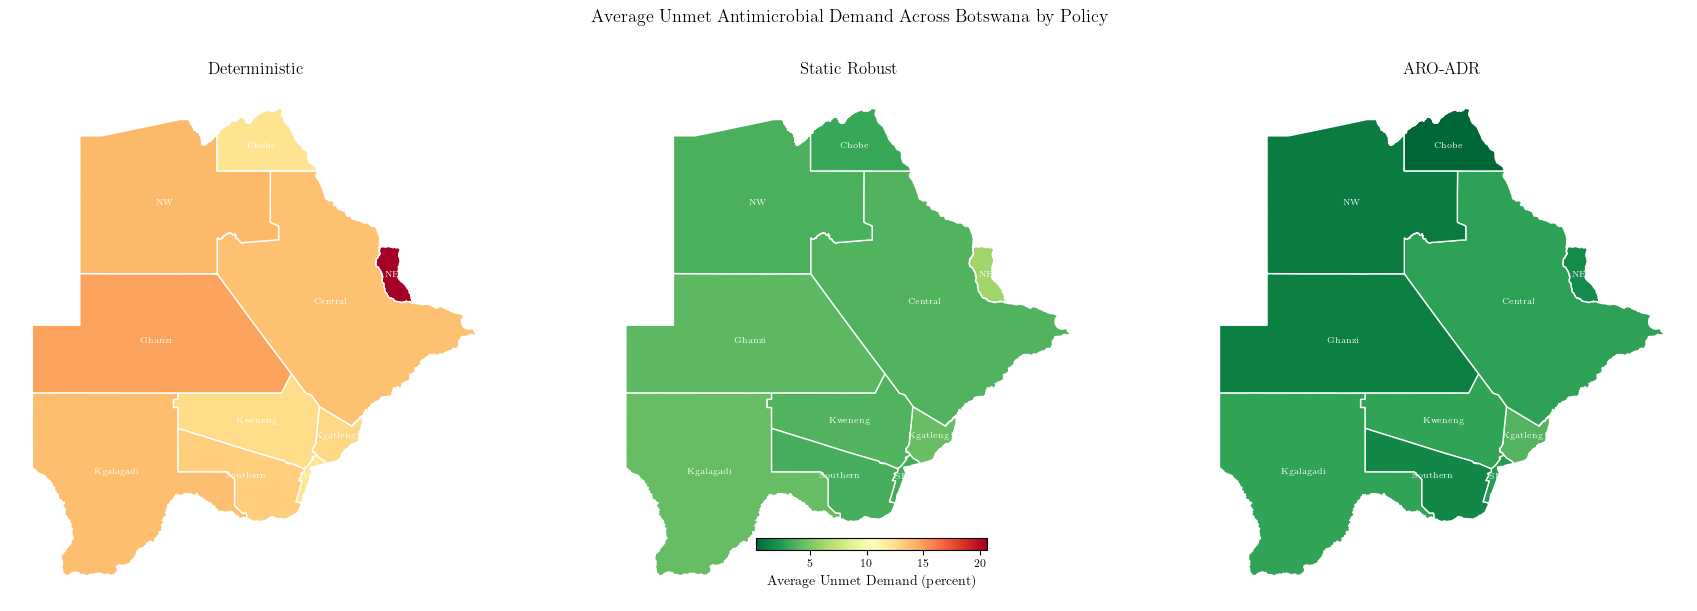

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor("white")

for ax, model in zip(axes, models):
    model_data = district_df[district_df["model"] == model]
    merged = gdf.merge(model_data, on="shapeName", how="left")

    merged.plot(
        column="avg_unmet_pct",
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor="white",
        linewidth=1.0,
        missing_kwds={"color": "lightgrey"},
    )

    for _, row in merged.iterrows():
        centroid = row.geometry.centroid
        name = (
            row["shapeName"]
            .replace(" District", "")
            .replace("North-East", "NE")
            .replace("North-West", "NW")
            .replace("South-East", "SE")
            .replace(" ", "\n")
        )
        ax.annotate(
            name,
            xy=(centroid.x, centroid.y),
            ha="center",
            va="center",
            fontsize=6,
            color="white",
            fontweight="bold",
        )

    ax.set_title(model_labels[model], fontsize=12, fontweight="bold", pad=8)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.025,
    pad=0.05,
    shrink=0.4,
)
cbar.set_label("Average Unmet Demand (percent)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "Average Unmet Antimicrobial Demand Across Botswana by Policy",
    fontsize=13,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.savefig("../outputs/figures/botswana_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

### National Results: Multi-Metric Choropleth Maps

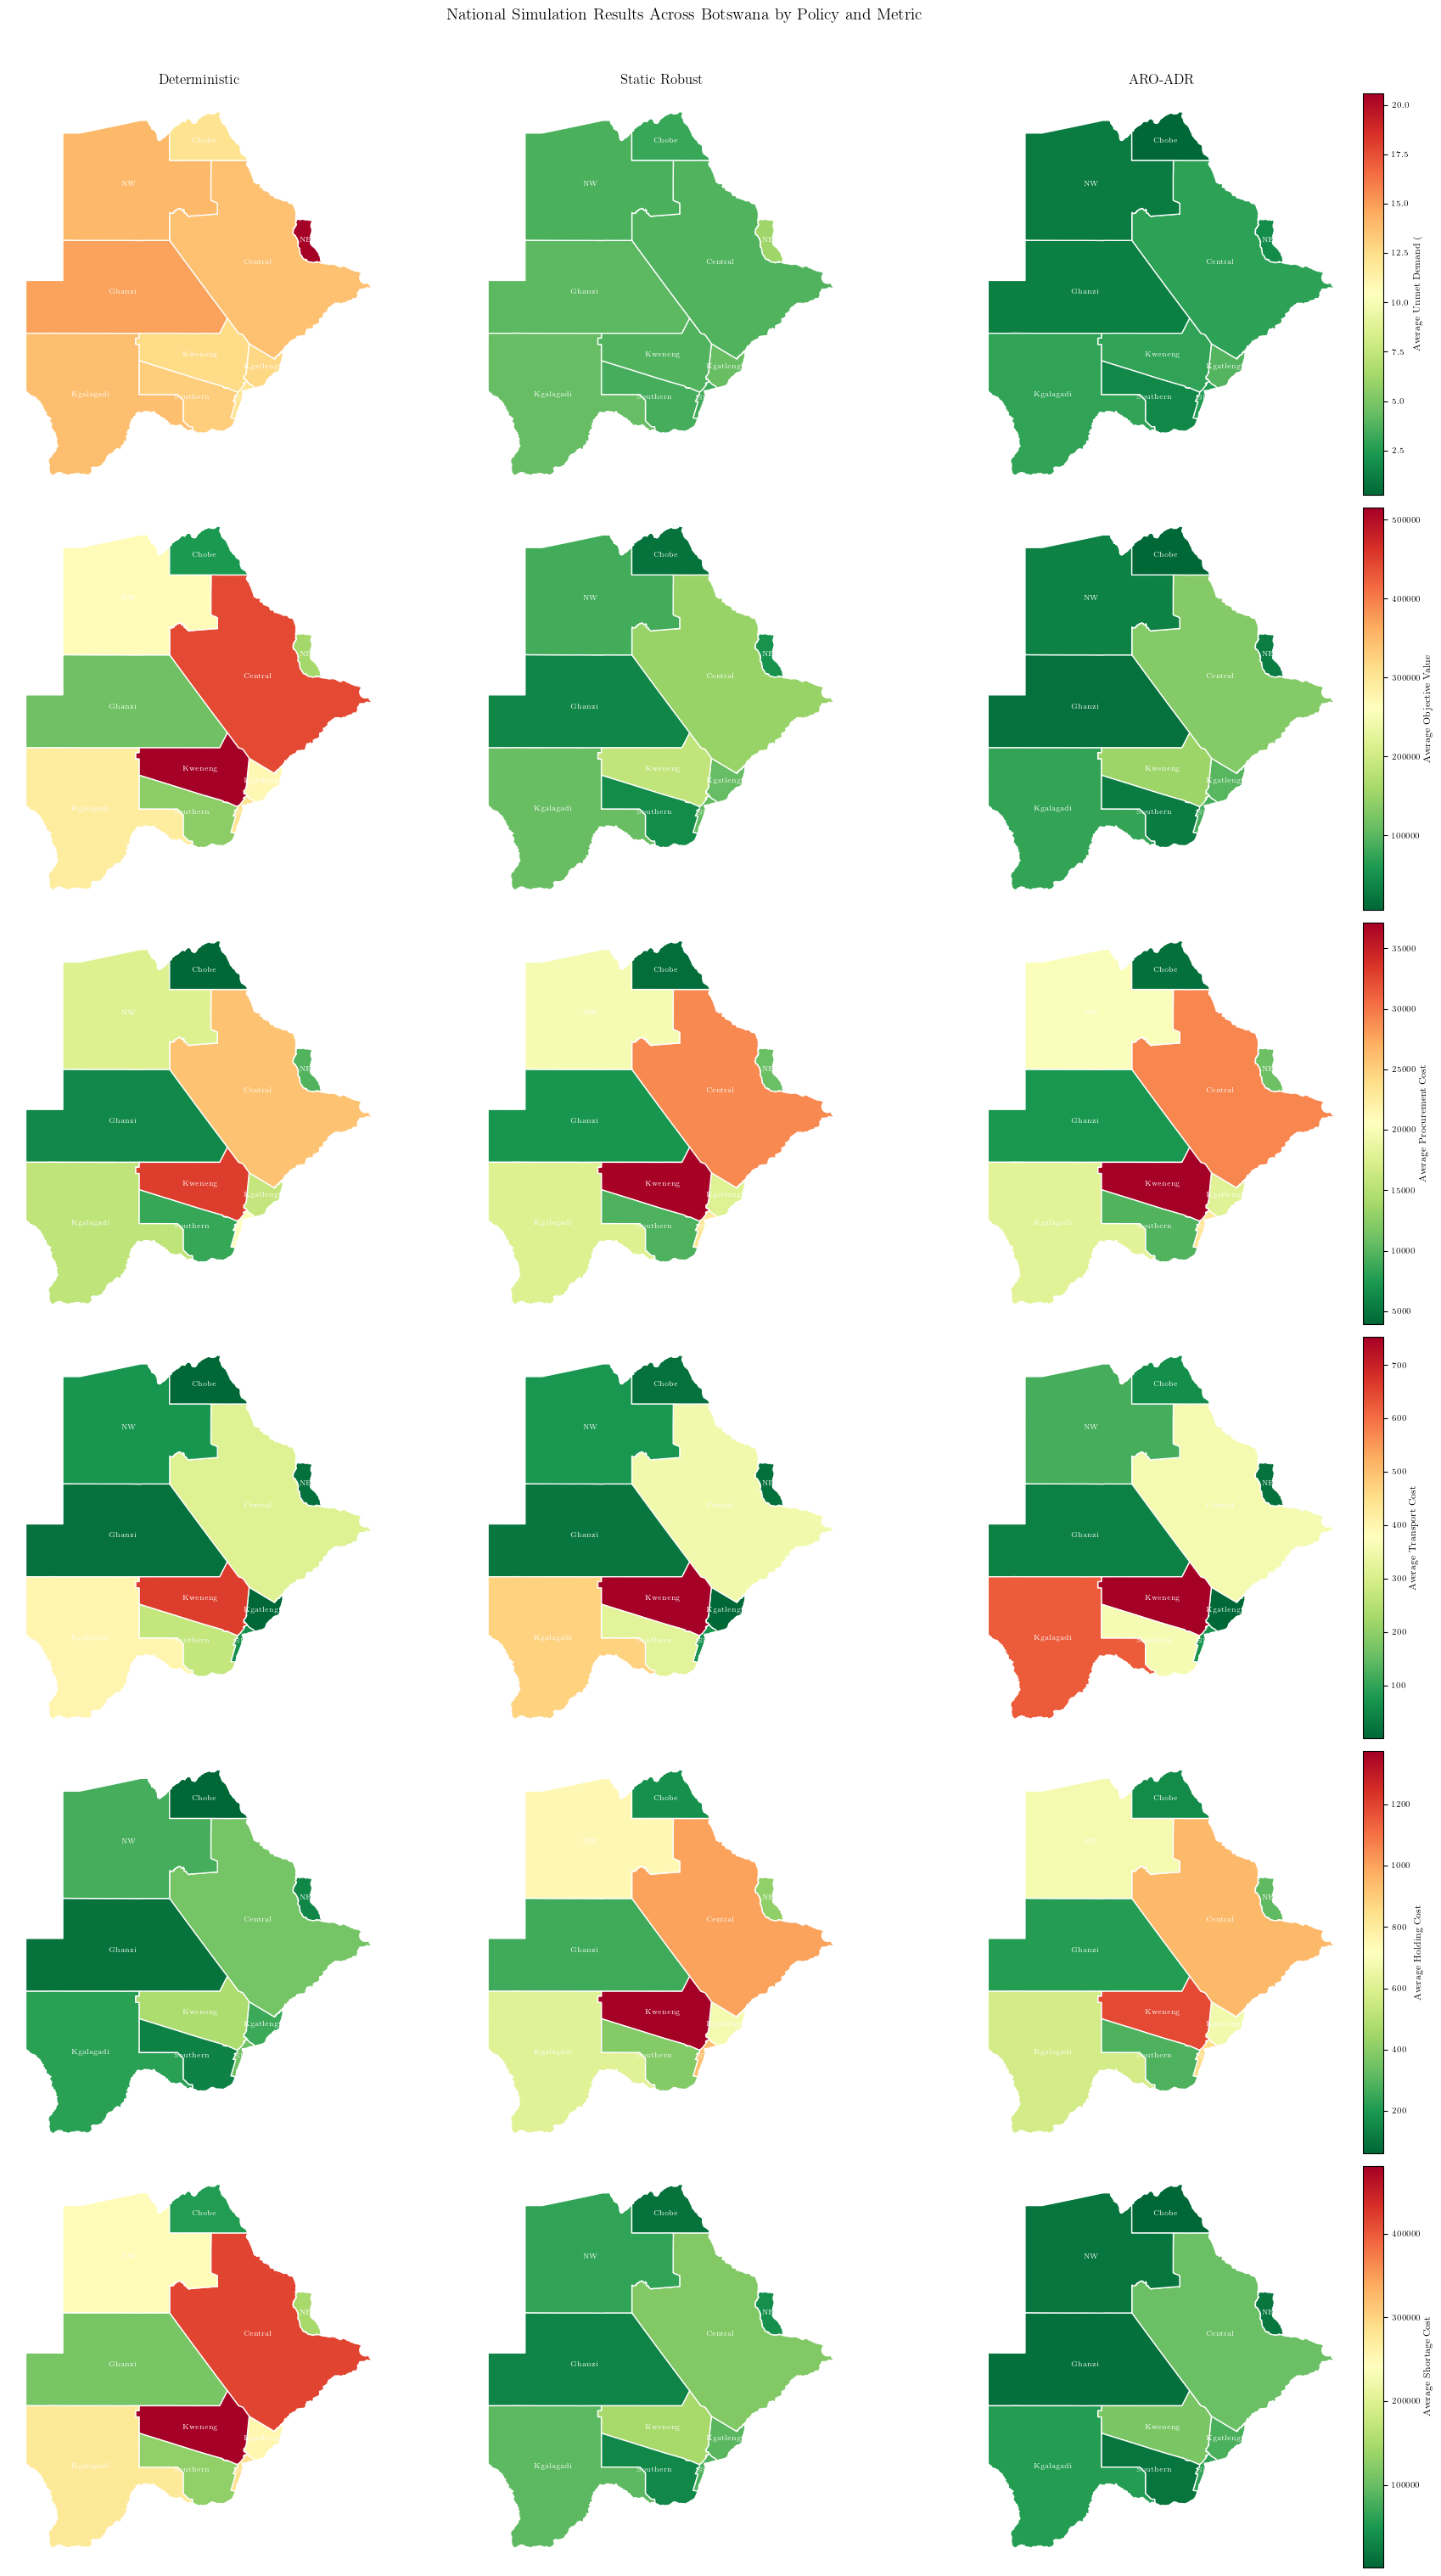

In [116]:
metrics_to_plot = [
    ("unmet_pct_realized",      "Average Unmet Demand (%)"),
    ("objective_realized",      "Average Objective Value"),
    ("procurement_cost",        "Average Procurement Cost"),
    ("transport_cost_realized", "Average Transport Cost"),
    ("holding_cost_end",        "Average Holding Cost"),
    ("shortage_cost_realized",  "Average Shortage Cost"),
]

n_rows = len(metrics_to_plot)
fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
fig.patch.set_facecolor("white")

for row_idx, (metric, metric_label) in enumerate(metrics_to_plot):
    # compute district-level summary for this metric
    metric_summary = (
        results_df
        .groupby(["region", "model"])[metric]
        .mean()
        .reset_index()
        .rename(columns={metric: "value"})
    )

    records_m = []
    for region, district in region_to_district.items():
        for model in models:
            val = metric_summary.loc[
                (metric_summary["region"] == region) & (metric_summary["model"] == model),
                "value"
            ]
            if not val.empty:
                records_m.append({
                    "shapeName": district,
                    "model": model,
                    "value": val.values[0]
                })

    district_metric_df = (
        pd.DataFrame(records_m)
        .groupby(["shapeName", "model"])["value"]
        .mean()
        .reset_index()
    )

    vmin_m = district_metric_df["value"].min()
    vmax_m = district_metric_df["value"].max()

    for col_idx, model in enumerate(models):
        ax = axes[row_idx, col_idx]
        model_data = district_metric_df[district_metric_df["model"] == model]
        merged = gdf.merge(model_data, on="shapeName", how="left")

        merged.plot(
            column="value",
            ax=ax,
            cmap="RdYlGn_r",
            vmin=vmin_m,
            vmax=vmax_m,
            edgecolor="white",
            linewidth=1.0,
            missing_kwds={"color": "lightgrey"},
        )

        for _, row in merged.iterrows():
            centroid = row.geometry.centroid
            name = (
                row["shapeName"]
                .replace(" District", "")
                .replace("North-East", "NE")
                .replace("North-West", "NW")
                .replace("South-East", "SE")
                .replace(" ", "\n")
            )
            ax.annotate(
                name,
                xy=(centroid.x, centroid.y),
                ha="center",
                va="center",
                fontsize=5.5,
                color="white",
                fontweight="bold",
            )

        if row_idx == 0:
            ax.set_title(model_labels[model], fontsize=12, fontweight="bold", pad=8)
        ax.axis("off")

        # per-row colorbar on the rightmost column
        if col_idx == 2:
            sm = plt.cm.ScalarMappable(
                cmap="RdYlGn_r",
                norm=mcolors.Normalize(vmin=vmin_m, vmax=vmax_m)
            )
            sm.set_array([])
            cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.05, pad=0.02)
            cbar.set_label(metric_label, fontsize=8)
            cbar.ax.tick_params(labelsize=7)

fig.suptitle(
    "National Simulation Results Across Botswana by Policy and Metric",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

plt.tight_layout()
plt.savefig("../outputs/figures/botswana_appendix_simulation_maps.png", dpi=200, bbox_inches="tight")
plt.show()

# cms-based demand simulation (2025-26 and 2026-27)

uses actual average monthly consumption data from the botswana cms instead of glm-estimated demand.
demand is prorated to each facility by its share of national population catchment.
the cms-derived allocation is the **mean** (mu); nb dispersion (kappa=10) builds a distribution around it so the stochastic robust and aro-adr models have real variability to work with.
two scenarios: 2025-26 amc and 2026-27 amc. shipments every 2 weeks → t=26 biweekly periods per scenario (26 + 26 = 52 total across both years).

In [ ]:
# load cms antimicrobial data
cms_raw = pd.read_csv("antimicrobials.csv")

# normalize all column names to snake_case so exact spacing never matters
cms_raw.columns = (
    cms_raw.columns
    .str.strip()
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)
print("Normalized columns:", cms_raw.columns.tolist())

# find the two amc columns by position (they share the same normalized name)
# pandas auto-suffixes duplicate columns when reading, e.g. months_of_stock -> .1
amc_cols = [c for c in cms_raw.columns if c.startswith('average_monthly')]
print("AMC columns found:", amc_cols)

cms = cms_raw.rename(columns={
    "product_code":   "product_code",
    "product_description": "description",
    "unit_price_bwp": "unit_price_bwp",
    amc_cols[0]:      "amc_2526",
    amc_cols[1]:      "amc_2627",
}).copy()

cms["unit_price_bwp"] = pd.to_numeric(cms["unit_price_bwp"], errors="coerce").fillna(0.0)
cms["amc_2526"]       = pd.to_numeric(cms["amc_2526"],       errors="coerce").fillna(0.0)
cms["amc_2627"]       = pd.to_numeric(cms["amc_2627"],       errors="coerce").fillna(0.0)

# 2-week (biweekly) demand
cms["biweekly_2526"] = cms["amc_2526"] / 2.0
cms["biweekly_2627"] = cms["amc_2627"] / 2.0

# keep products with nonzero demand in at least one scenario
cms_active = cms[(cms["biweekly_2526"] > 0) | (cms["biweekly_2627"] > 0)].copy()
cms_active = cms_active.set_index("product_code")

# procurement cost per product (bwp); missing prices → 0
cms_proc_cost = cms_active["unit_price_bwp"]

print(f"Active products: {len(cms_active)}")
display(cms_active[["description", "unit_price_bwp", "biweekly_2526", "biweekly_2627"]])

In [ ]:
# national population shares per facility
# recompute nearest facility for all population points nationally,
# including hospitals (which draw from the same catchments as clinics/hps).

def _clean_fac_name(x):
    """Same cleaning as clean_name_local in build_region_instance."""
    s = str(x).replace("\ufeff", "").replace("\xa0", " ")
    s = " ".join(s.split())
    return s.strip()

_pop_nat = pop.copy()
_pop_nat["total_population"] = (
    _pop_nat["total_population"]
    .astype(str).str.replace(",", "", regex=False)
)
_pop_nat["total_population"] = pd.to_numeric(_pop_nat["total_population"], errors="coerce")
_pop_nat["pop_id"] = _pop_nat.index

# nearest clinic, health post, and hospital for every pop point
_clinic_nat = nearest_facilities(_pop_nat, fac, "Clinic")
_hp_nat     = nearest_facilities(_pop_nat, fac, "Health Post")
_hosp_nat   = nearest_facilities(_pop_nat, fac, "Hospital")

_rename = {"Facility Name_1": "facility_name", "crow_dist_km_1": "dist_km", "total_population": "pop_total"}
_cols   = ["pop_id", "Facility Name_1", "crow_dist_km_1", "total_population"]

_clinic_nat = _clinic_nat[_cols].rename(columns=_rename)
_hp_nat     = _hp_nat[_cols].rename(columns=_rename)
_hosp_nat   = _hosp_nat[_cols].rename(columns=_rename)

_clinic_nat["facility_type"] = "clinic"
_hp_nat["facility_type"]     = "health_post"
_hosp_nat["facility_type"]   = "hospital"

_choices_nat = pd.concat([_clinic_nat, _hp_nat, _hosp_nat], ignore_index=True)
_choices_nat["dist_km"] = pd.to_numeric(_choices_nat["dist_km"], errors="coerce")
_choices_nat = _choices_nat.dropna(subset=["facility_name", "dist_km"])

# apply same name cleaning used by build_region_instance
_choices_nat["facility_name"] = _choices_nat["facility_name"].map(_clean_fac_name)

_choices_nat = _choices_nat.sort_values(["pop_id", "dist_km"])
_closest_nat = _choices_nat.drop_duplicates(subset=["pop_id"], keep="first")

# aggregate population by facility
pop_fac_national = (
    _closest_nat
    .groupby("facility_name", as_index=True)["pop_total"]
    .sum()
    .rename("pop_total")
)

national_pop = pop_fac_national.sum()
pop_fac_share = (pop_fac_national / national_pop).rename("pop_share")

print(f"National total population : {national_pop:,.0f}")
print(f"Number of facilities      : {len(pop_fac_share)}")
print(f"Facility type breakdown:")
print(_closest_nat["facility_type"].value_counts())
print(f"Sum of shares             : {pop_fac_share.sum():.4f}")


# cms demand matrix builder
def build_cms_demand_matrix(nodes, cms_node, scenario="2526"):
    """
    Build a node-level demand matrix from CMS AMC data distributed
    by national population share. The CMS warehouse node gets 0 demand.

    Parameters
    nodes    : list of str   - all nodes in the region (including CMS warehouse)
    cms_node : str           - name of the CMS/source warehouse node
    scenario : "2526" | "2627"

    Returns
    mu_mat : DataFrame, shape (len(nodes), n_products)
        Mean biweekly demand per node per product.
    """
    col = f"biweekly_{scenario}"
    national_demand = cms_active[col]  # series indexed by product_code

    demand_nodes = [n for n in nodes if n != cms_node]
    shares = pop_fac_share.reindex(demand_nodes).fillna(0.0)

    # outer product: demand_nodes × products
    mu_demand = pd.DataFrame(
        np.outer(shares.values, national_demand.values),
        index=demand_nodes,
        columns=national_demand.index,
    )
    # reindex to all nodes; cms warehouse gets 0
    mu_mat = mu_demand.reindex(nodes).fillna(0.0).astype(float)
    return mu_mat


# cms region instance builder
def build_cms_region_instance(region, scenario="2526"):
    """
    Like build_region_instance() but replaces GLM demand with
    CMS-based population-catchment demand.
    mu_mat is the mean; NB dispersion (kappa=10) builds the distribution.
    """
    base = build_region_instance(region)

    mu_mat  = build_cms_demand_matrix(base["nodes"], base["CMS"], scenario=scenario)
    classes = mu_mat.columns.tolist()

    sigma_mat = nb_sigma_from_mean(mu_mat, kappa=10.0).reindex(
        index=base["nodes"], columns=classes
    ).fillna(0.0).astype(float)

    return {
        **base,
        "mu_mat":    mu_mat,
        "sigma_mat": sigma_mat,
        "proc_cost": cms_proc_cost,  # series indexed by product_code (bwp)
    }


In [ ]:
# cms-aware simulate functions
# identical to the originals but procurement_cost_per_unit accepts a scalar or
# a series/array indexed by product code.  existing scalar callers are unaffected.

def _resolve_c_proc(procurement_cost_per_unit, classes):
    """Return a (K,) float64 numpy array of per-drug procurement costs."""
    if np.isscalar(procurement_cost_per_unit):
        return np.full(len(classes), float(procurement_cost_per_unit))
    return (
        pd.Series(procurement_cost_per_unit)
        .reindex(classes)
        .fillna(0.0)
        .astype(float)
        .to_numpy()
    )


def _resolve_c_penalty(shortage_penalty_per_unit, classes):
    """Return a (K,) float64 numpy array of per-drug shortage penalties.
    Accepts a scalar (uniform) or a Series/array indexed by product code."""
    if np.isscalar(shortage_penalty_per_unit):
        return np.full(len(classes), float(shortage_penalty_per_unit))
    return (
        pd.Series(shortage_penalty_per_unit)
        .reindex(classes)
        .fillna(0.0)
        .astype(float)
        .to_numpy()
    )


def simulate_policy_under_draws_cms(
    T, CMS, nodes, arcs, classes, dist_km, mu_mat, demand_draws,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=0.0,
    supply_multiplier=0.0, arc_cap=None, storage_cap_per_node=None,
    solver=None, verbose=False, relax_integrality=False, I0_start=None,
):
    nodes   = list(nodes)
    arcs    = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K  = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")
    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc  = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)
    c_proc = _resolve_c_proc(procurement_cost_per_unit, classes)  # ← resolve once
    c_pen  = _resolve_c_penalty(shortage_penalty_per_unit, classes)  # ← resolve once

    mu_mat = mu_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    mu_np  = mu_mat.to_numpy()

    in_arcs  = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        cap_vec = (np.full(N, float(storage_cap_per_node)) if np.isscalar(storage_cap_per_node)
                   else pd.Series(storage_cap_per_node).reindex(nodes).astype(float).to_numpy())

    if I0_start is not None:
        I = I0_start.reindex(index=nodes, columns=classes).fillna(0.0)
    else:
        I = pd.DataFrame(0.0, index=nodes, columns=classes)
        I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)
    metrics = []
    nominal_mu = mu_mat.copy()

    for t in range(T):
        I0 = I.to_numpy().copy()
        F  = cp.Variable((m, K), nonneg=True)
        u  = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q  = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y   = cp.Variable(m, nonneg=True)
            constraints += [y <= 1.0]
        else:
            lam = cp.Variable(m, integer=True)
            y   = cp.Variable(m, boolean=True)

        big_m = 1e5
        for a in range(m):
            constraints.append(cp.sum(F[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                inflow  = cp.sum(F[in_arcs[n],  k]) if in_arcs[n]  else 0
                outflow = cp.sum(F[out_arcs[n], k]) if out_arcs[n] else 0
                supply  = q[k] if nodes[n] == CMS else 0.0
                demand  = float(mu_np[n, k])
                constraints.append(
                    I1[n, k] == I0[n, k] + inflow - outflow + supply - demand + u[n, k]
                )
                constraints.append(outflow <= I0[n, k] + inflow + supply)

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        obj = cp.Minimize(
            transport_cost_per_km    * cp.sum(cp.multiply(c_arc,  lam))
            + cp.sum(cp.multiply(c_pen.reshape(1, K), u))
            + holding_cost_per_unit     * cp.sum(I1)
            + cp.sum(cp.multiply(c_proc, q))  # ← per-drug cost
        )
        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)
        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        F_val = np.maximum(np.asarray(F.value, dtype=float), 0.0)
        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        ship_by_arc = {(i, j): pd.Series(F_val[a, :], index=classes)
                       for a, (i, j) in enumerate(arcs)}
        q_ser   = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet  = pd.DataFrame(0.0, index=nodes, columns=classes)
        for n_name in nodes:
            inflow  = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)
            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name: inflow  = inflow.add(ship_ser,  fill_value=0.0)
                if i == n_name: outflow = outflow.add(ship_ser, fill_value=0.0)
            add_supply  = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec  = realized.loc[n_name, :]
            avail       = I.loc[n_name, :] + add_supply + inflow - outflow
            served      = np.minimum(avail, demand_vec)
            unmet.loc[n_name, :]  = demand_vec - served
            I_next.loc[n_name, :] = avail - served
        I = I_next.copy()

        transport_cost = sum(transport_cost_per_km * float(dist_km.loc[i, j]) * float(lam_val[a])
                             for a, (i, j) in enumerate(arcs))
        shortage_cost  = float((unmet.to_numpy() * c_pen).sum())
        holding_cost   = holding_cost_per_unit     * float(I.to_numpy().sum())
        proc_cost      = float((q_ser * pd.Series(c_proc, index=classes)).sum())

        total_demand = float(realized.to_numpy().sum())
        total_unmet  = float(unmet.to_numpy().sum())
        metrics.append({
            "t": t,
            "objective_realized":      transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized":  shortage_cost,
            "holding_cost_end":        holding_cost,
            "procurement_cost":        proc_cost,
            "unmet_pct_realized":      (total_unmet / total_demand * 100.0) if total_demand > 0 else 0.0,
            "total_unmet_units":       total_unmet,
            "total_demand_units":      total_demand,
            "total_procured_units":    float(q_ser.sum()),
        })
    return pd.DataFrame(metrics), nominal_mu, I


def simulate_static_robust_under_draws_cms(
    T, CMS, nodes, arcs, classes, dist_km, mu_mat, demand_draws, sigma_mat, Gamma,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=0.0,
    supply_multiplier=0.0, arc_cap=None, storage_cap_per_node=None,
    solver=None, verbose=False, relax_integrality=False, I0_start=None,
):
    nodes   = list(nodes)
    arcs    = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K  = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")
    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc  = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)
    c_proc = _resolve_c_proc(procurement_cost_per_unit, classes)  # ← resolve once
    c_pen  = _resolve_c_penalty(shortage_penalty_per_unit, classes)  # ← resolve once

    mu_mat    = mu_mat.reindex(index=nodes,    columns=classes).fillna(0.0).astype(float)
    sigma_mat = sigma_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    mu_np     = mu_mat.to_numpy()
    sigma_np  = sigma_mat.to_numpy()

    in_arcs  = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        cap_vec = (np.full(N, float(storage_cap_per_node)) if np.isscalar(storage_cap_per_node)
                   else pd.Series(storage_cap_per_node).reindex(nodes).astype(float).to_numpy())

    if I0_start is not None:
        I = I0_start.reindex(index=nodes, columns=classes).fillna(0.0)
    else:
        I = pd.DataFrame(0.0, index=nodes, columns=classes)
        I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)
    metrics = []

    def nk_index(n, k): return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()
        constraints = []
        Fbar = cp.Variable((m, K), nonneg=True)
        u    = cp.Variable((N, K), nonneg=True)
        I1   = cp.Variable((N, K), nonneg=True)
        q    = cp.Variable(K, nonneg=True)

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y   = cp.Variable(m, nonneg=True)
            constraints += [y <= 1.0]
        else:
            lam = cp.Variable(m, integer=True)
            y   = cp.Variable(m, boolean=True)

        theta        = cp.Variable((N, K), nonneg=True)
        pi_plus      = cp.Variable((N * K, N), nonneg=True)
        pi_minus     = cp.Variable((N * K, N), nonneg=True)
        theta_ship   = cp.Variable((N, K), nonneg=True)
        pi_ship_plus  = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)
        big_m = 1e5

        for a in range(m):
            constraints.append(cp.sum(Fbar[a, :]) <= arc_cap_vec[a] * lam[a])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                nk      = nk_index(n, k)
                inflow  = cp.sum(Fbar[in_arcs[n],  k]) if in_arcs[n]  else 0
                outflow = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply  = q[k] if nodes[n] == CMS else 0.0
                demand  = float(mu_np[n, k])
                rhs = I0[n,k] + inflow - outflow + supply - demand + u[n,k] - I1[n,k]
                constraints.append(
                    Gamma * theta[n,k] + cp.sum(pi_plus[nk,:]) + cp.sum(pi_minus[nk,:]) <= rhs
                )
                constraints.append(theta[n,k] + pi_plus[nk,n]  >= -sigma_np[n,k])
                constraints.append(theta[n,k] + pi_minus[nk,n] >=  sigma_np[n,k])
                rhs_ship = I0[n,k] + inflow + supply - outflow
                constraints.append(
                    Gamma * theta_ship[n,k] + cp.sum(pi_ship_plus[nk,:]) + cp.sum(pi_ship_minus[nk,:]) <= rhs_ship
                )
                constraints.append(theta_ship[n,k] + pi_ship_plus[nk,n]  >= -sigma_np[n,k])
                constraints.append(theta_ship[n,k] + pi_ship_minus[nk,n] >=  sigma_np[n,k])

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        obj = cp.Minimize(
            transport_cost_per_km    * cp.sum(cp.multiply(c_arc,  lam))
            + cp.sum(cp.multiply(c_pen.reshape(1, K), u))
            + holding_cost_per_unit     * cp.sum(I1)
            + cp.sum(cp.multiply(c_proc, q))  # ← per-drug cost
        )
        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)
        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        Fbar_val = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)
        realized = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        ship_by_arc = {(i, j): pd.Series(Fbar_val[a, :], index=classes)
                       for a, (i, j) in enumerate(arcs)}
        q_ser   = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet  = pd.DataFrame(0.0, index=nodes, columns=classes)
        for n_name in nodes:
            inflow  = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)
            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name: inflow  = inflow.add(ship_ser,  fill_value=0.0)
                if i == n_name: outflow = outflow.add(ship_ser, fill_value=0.0)
            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]
            avail      = I.loc[n_name, :] + add_supply + inflow - outflow
            served     = np.minimum(np.maximum(avail, 0.0), demand_vec)
            unmet.loc[n_name, :]  = demand_vec - served
            I_next.loc[n_name, :] = avail - served
        I = I_next.copy()

        transport_cost = sum(transport_cost_per_km * float(dist_km.loc[i, j]) * lam_val[a]
                             for a, (i, j) in enumerate(arcs))
        shortage_cost  = float((unmet.to_numpy() * c_pen).sum())
        holding_cost   = holding_cost_per_unit     * float(I.to_numpy().sum())
        proc_cost      = float((q_ser * pd.Series(c_proc, index=classes)).sum())

        total_demand = float(realized.to_numpy().sum())
        total_unmet  = float(unmet.to_numpy().sum())
        metrics.append({
            "t": t,
            "objective_realized":      transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized":  shortage_cost,
            "holding_cost_end":        holding_cost,
            "procurement_cost":        proc_cost,
            "unmet_pct_realized":      (total_unmet / total_demand * 100.0) if total_demand > 0 else 0.0,
            "total_unmet_units":       total_unmet,
            "total_demand_units":      total_demand,
            "total_procured_units":    float(q_ser.sum()),
        })
    return pd.DataFrame(metrics), mu_mat.copy(), I


def simulate_aro_adr_under_draws_cms(
    T, CMS, nodes, arcs, arc_df, classes, dist_km, mu_mat, demand_draws, sigma_mat, Gamma,
    alpha_lb=-np.inf, alpha_ub=np.inf,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=10.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=0.1,
    supply_multiplier=0.0, arc_cap=None, storage_cap_per_node=None,
    solver=None, verbose=False, freeze_alpha_after_first=False, relax_integrality=False, I0_start=None,
):
    nodes   = list(nodes)
    arcs    = list(arcs)
    classes = list(classes)

    node_idx = {n: i for i, n in enumerate(nodes)}
    N, m, K  = len(nodes), len(arcs), len(classes)

    if arc_cap is None:
        raise ValueError("arc_cap must be provided")
    if Gamma < 0:
        raise ValueError("Gamma must be nonnegative")

    if np.isscalar(arc_cap):
        arc_cap_vec = np.full(m, float(arc_cap))
    else:
        arc_cap_vec = np.array([float(arc_cap[(i, j)]) for (i, j) in arcs], dtype=float)

    c_arc  = np.array([float(dist_km.loc[i, j]) for (i, j) in arcs], dtype=float)
    c_proc = _resolve_c_proc(procurement_cost_per_unit, classes)  # ← resolve once
    c_pen  = _resolve_c_penalty(shortage_penalty_per_unit, classes)  # ← resolve once

    mu_mat    = mu_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    mu_np     = mu_mat.to_numpy()
    sigma_mat = sigma_mat.reindex(index=nodes, columns=classes).fillna(0.0).astype(float)
    sigma_np  = sigma_mat.to_numpy()

    adaptive_arc_mask = np.array([
        1.0 if (row.u_tier in ["cms","warehouse","hospital"]
                and row.v_tier in ["clinic","warehouse","hospital","health_post"]) else 0.0
        for row in arc_df.itertuples(index=False)
    ], dtype=float)

    arc_dest_idx = np.array([node_idx[j] for (i, j) in arcs], dtype=int)

    in_arcs  = [[] for _ in range(N)]
    out_arcs = [[] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        out_arcs[node_idx[i]].append(a)
        in_arcs[node_idx[j]].append(a)

    arcs_from_to = [[[] for _ in range(N)] for _ in range(N)]
    for a, (i, j) in enumerate(arcs):
        arcs_from_to[node_idx[i]][node_idx[j]].append(a)

    if storage_cap_per_node is None:
        cap_vec = None
    else:
        cap_vec = (np.full(N, float(storage_cap_per_node)) if np.isscalar(storage_cap_per_node)
                   else pd.Series(storage_cap_per_node).reindex(nodes).astype(float).to_numpy())

    if I0_start is not None:
        I = I0_start.reindex(index=nodes, columns=classes).fillna(0.0)
    else:
        I = pd.DataFrame(0.0, index=nodes, columns=classes)
        I.loc[CMS, :] = supply_multiplier * mu_mat.sum(axis=0)
    learned_alpha = None
    metrics = []

    def nk_index(n, k): return n * K + k

    for t in range(T):
        I0 = I.to_numpy().copy()
        Fbar = cp.Variable((m, K), nonneg=True)

        if freeze_alpha_after_first and learned_alpha is not None:
            alpha     = None
            alpha_val = np.asarray(learned_alpha, dtype=float)
        else:
            alpha     = cp.Variable((m, K))
            alpha_val = None

        u  = cp.Variable((N, K), nonneg=True)
        I1 = cp.Variable((N, K), nonneg=True)
        q  = cp.Variable(K, nonneg=True)
        constraints = []

        if relax_integrality:
            lam = cp.Variable(m, nonneg=True)
            y   = cp.Variable(m, nonneg=True)
            constraints += [y <= 1.0]
        else:
            lam = cp.Variable(m, integer=True)
            y   = cp.Variable(m, boolean=True)

        theta         = cp.Variable((N, K), nonneg=True)
        pi_plus       = cp.Variable((N * K, N), nonneg=True)
        pi_minus      = cp.Variable((N * K, N), nonneg=True)
        theta_ship    = cp.Variable((N, K), nonneg=True)
        pi_ship_plus  = cp.Variable((N * K, N), nonneg=True)
        pi_ship_minus = cp.Variable((N * K, N), nonneg=True)
        eta           = cp.Variable(m, nonneg=True)
        rho_plus      = cp.Variable((m, K), nonneg=True)
        rho_minus     = cp.Variable((m, K), nonneg=True)

        if alpha is not None:
            if np.isfinite(alpha_lb):
                constraints.append(alpha >= alpha_lb)
            if np.isfinite(alpha_ub):
                constraints.append(alpha <= alpha_ub)

        big_m = 1e5

        for a in range(m):
            j = arc_dest_idx[a]
            rhs_cap = arc_cap_vec[a] * lam[a] - cp.sum(Fbar[a, :])
            constraints.append(
                Gamma * eta[a] + cp.sum(rho_plus[a, :] + rho_minus[a, :]) <= rhs_cap
            )
            for k in range(K):
                coeff = alpha[a, k] if alpha is not None else alpha_val[a, k]
                constraints.append(eta[a] + rho_plus[a, k]  >= coeff * sigma_np[j, k])
                constraints.append(eta[a] + rho_minus[a, k] >= -coeff * sigma_np[j, k])
            constraints.append(lam[a] >= 0)
            constraints.append(lam[a] <= big_m * y[a])

        for n in range(N):
            for k in range(K):
                nk      = nk_index(n, k)
                inflow  = cp.sum(Fbar[in_arcs[n],  k]) if in_arcs[n]  else 0
                outflow = cp.sum(Fbar[out_arcs[n], k]) if out_arcs[n] else 0
                supply  = q[k] if nodes[n] == CMS else 0.0
                demand  = float(mu_np[n, k])
                rhs = I0[n,k] + inflow - outflow + supply - demand + u[n,k] - I1[n,k]
                constraints.append(
                    Gamma * theta[n,k] + cp.sum(pi_plus[nk,:]) + cp.sum(pi_minus[nk,:]) <= rhs
                )
                incoming_adaptive = [a for a in in_arcs[n] if adaptive_arc_mask[a] == 1.0]
                coeff_self = ((cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0) - 1.0
                              if alpha is not None else
                              (float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0) - 1.0)
                constraints.append(theta[n,k] + pi_plus[nk,n]  >= coeff_self * sigma_np[n,k])
                constraints.append(theta[n,k] + pi_minus[nk,n] >= -coeff_self * sigma_np[n,k])
                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs: continue
                    coeff_out = (-cp.sum(alpha[nr_arcs, k]) if alpha is not None
                                 else -float(np.sum(alpha_val[nr_arcs, k])))
                    constraints.append(theta[n,k] + pi_plus[nk,r]  >= coeff_out * sigma_np[r,k])
                    constraints.append(theta[n,k] + pi_minus[nk,r] >= -coeff_out * sigma_np[r,k])

                rhs_ship = I0[n,k] + inflow + supply - outflow
                constraints.append(
                    Gamma * theta_ship[n,k] + cp.sum(pi_ship_plus[nk,:]) + cp.sum(pi_ship_minus[nk,:]) <= rhs_ship
                )
                coeff_self_ship = ((-cp.sum(alpha[incoming_adaptive, k]) if incoming_adaptive else 0)
                                   if alpha is not None else
                                   (-float(np.sum(alpha_val[incoming_adaptive, k])) if incoming_adaptive else 0.0))
                constraints.append(theta_ship[n,k] + pi_ship_plus[nk,n]  >= coeff_self_ship * sigma_np[n,k])
                constraints.append(theta_ship[n,k] + pi_ship_minus[nk,n] >= -coeff_self_ship * sigma_np[n,k])
                for r in range(N):
                    nr_arcs = [a for a in arcs_from_to[n][r] if adaptive_arc_mask[a] == 1.0]
                    if not nr_arcs: continue
                    coeff_out_ship = (cp.sum(alpha[nr_arcs, k]) if alpha is not None
                                      else float(np.sum(alpha_val[nr_arcs, k])))
                    constraints.append(theta_ship[n,k] + pi_ship_plus[nk,r]  >= coeff_out_ship * sigma_np[r,k])
                    constraints.append(theta_ship[n,k] + pi_ship_minus[nk,r] >= -coeff_out_ship * sigma_np[r,k])

        if cap_vec is not None:
            for n in range(N):
                constraints.append(cp.sum(I1[n, :]) <= cap_vec[n])

        obj = cp.Minimize(
            transport_cost_per_km    * cp.sum(cp.multiply(c_arc,  lam))
            + cp.sum(cp.multiply(c_pen.reshape(1, K), u))
            + holding_cost_per_unit     * cp.sum(I1)
            + cp.sum(cp.multiply(c_proc, q))  # ← per-drug cost
        )
        prob = cp.Problem(obj, constraints)
        prob.solve(solver=solver, verbose=verbose)
        if prob.status not in ("optimal", "optimal_inaccurate"):
            raise RuntimeError(f"Failed at t={t}: {prob.status}")

        if alpha is not None:
            learned_alpha = np.asarray(alpha.value, dtype=float)

        Fbar_val  = np.maximum(np.asarray(Fbar.value, dtype=float), 0.0)
        alpha_use = (np.asarray(learned_alpha, dtype=float) if learned_alpha is not None
                     else np.asarray(alpha_val, dtype=float))
        realized    = pd.DataFrame(demand_draws[t], index=nodes, columns=classes)
        realized_np = realized.to_numpy()
        xi_real     = realized_np - mu_np

        ship_np = np.zeros((m, K), dtype=float)
        for a in range(m):
            dest = arc_dest_idx[a]
            ship_np[a, :] = (Fbar_val[a, :] + alpha_use[a, :] * xi_real[dest, :]
                             if adaptive_arc_mask[a] == 1.0 else Fbar_val[a, :])
        ship_np = np.maximum(ship_np, 0.0)

        ship_by_arc = {(i, j): pd.Series(ship_np[a, :], index=classes)
                       for a, (i, j) in enumerate(arcs)}
        q_ser   = pd.Series(np.maximum(np.asarray(q.value, dtype=float), 0.0), index=classes)
        lam_val = np.maximum(np.round(np.asarray(lam.value, dtype=float)).astype(int), 0)

        I_next = pd.DataFrame(0.0, index=nodes, columns=classes)
        unmet  = pd.DataFrame(0.0, index=nodes, columns=classes)
        for n_name in nodes:
            inflow  = pd.Series(0.0, index=classes)
            outflow = pd.Series(0.0, index=classes)
            for (i, j), ship_ser in ship_by_arc.items():
                if j == n_name: inflow  = inflow.add(ship_ser,  fill_value=0.0)
                if i == n_name: outflow = outflow.add(ship_ser, fill_value=0.0)
            add_supply = q_ser if n_name == CMS else pd.Series(0.0, index=classes)
            demand_vec = realized.loc[n_name, :]
            avail      = I.loc[n_name, :] + add_supply + inflow - outflow
            served     = np.minimum(avail, demand_vec)
            unmet.loc[n_name, :]  = demand_vec - served
            I_next.loc[n_name, :] = avail - served
        I = I_next.copy()

        transport_cost = sum(transport_cost_per_km * float(dist_km.loc[i, j]) * float(lam_val[a])
                             for a, (i, j) in enumerate(arcs))
        shortage_cost  = float((unmet.to_numpy() * c_pen).sum())
        holding_cost   = holding_cost_per_unit     * float(I.to_numpy().sum())
        proc_cost      = float((q_ser * pd.Series(c_proc, index=classes)).sum())

        total_demand = float(realized.to_numpy().sum())
        total_unmet  = float(unmet.to_numpy().sum())
        alpha_mean   = float(np.mean(learned_alpha)) if learned_alpha is not None else np.nan

        metrics.append({
            "t": t,
            "alpha_opt_mean":          alpha_mean,
            "objective_realized":      transport_cost + shortage_cost + holding_cost + proc_cost,
            "transport_cost_realized": transport_cost,
            "shortage_cost_realized":  shortage_cost,
            "holding_cost_end":        holding_cost,
            "procurement_cost":        proc_cost,
            "unmet_pct_realized":      (total_unmet / total_demand * 100.0) if total_demand > 0 else 0.0,
            "total_unmet_units":       total_unmet,
            "total_demand_units":      total_demand,
            "total_procured_units":    float(q_ser.sum()),
        })

    learned_alpha_out = pd.DataFrame(
        learned_alpha, index=[f"{i}->{j}" for (i, j) in arcs], columns=classes,
    )
    return pd.DataFrame(metrics), learned_alpha_out, I


print("CMS-aware simulate functions defined: "
      "simulate_policy_under_draws_cms, "
      "simulate_static_robust_under_draws_cms, "
      "simulate_aro_adr_under_draws_cms")

In [ ]:
# cms simulation loop (sequential: year 1 → carry inventory → year 2)
# year 1 (2025-26) runs from zero inventory.
# year 2 (2026-27) starts from year 1's final inventory so the model must
# adapt to shifted demand without a reset.  each period = 2-week shipment cycle.

T     = 26
kappa = 10.0
seed  = 42
Gamma = 10.0

completed = ['Boteti', 'Chobe', 'Ghanzi', 'Greater Francistown', 
             'Greater Gaborone', 'Greater Phikwe', 'Kgalagadi North',
             'Kgalagadi South', 'Kgatleng']
all_regions = [r for r in all_regions if r not in completed]

cms_results  = []
cms_failures = []

for region in all_regions:
    try:
        # year 1: 2025-26, start from zero
        inst_y1   = build_cms_region_instance(region, scenario="2526")
        classes_y1 = inst_y1["mu_mat"].columns.tolist()
        draws_y1  = make_nb_draws_from_mean(inst_y1["mu_mat"], kappa=kappa, T=T, seed=seed)

        metrics_det_cms_y1, _, final_I_det = simulate_policy_under_draws_cms(
            T=T, CMS=inst_y1["CMS"], nodes=inst_y1["nodes"], arcs=inst_y1["arcs"],
            classes=classes_y1, dist_km=inst_y1["dist_km"], mu_mat=inst_y1["mu_mat"],
            demand_draws=draws_y1,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y1["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y1["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y1["arc_cap"],
            storage_cap_per_node=inst_y1["storage_cap_per_node"],
            solver=cp.HIGHS, verbose=False, relax_integrality=True, I0_start=None,
        )
        print("done with deterministic CMS for year 1 for " + region)
        metrics_rob_cms_y1, _, final_I_rob = simulate_static_robust_under_draws_cms(
            T=T, CMS=inst_y1["CMS"], nodes=inst_y1["nodes"], arcs=inst_y1["arcs"],
            classes=classes_y1, dist_km=inst_y1["dist_km"], mu_mat=inst_y1["mu_mat"],
            demand_draws=draws_y1, sigma_mat=inst_y1["sigma_mat"], Gamma=Gamma,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y1["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y1["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y1["arc_cap"],
            storage_cap_per_node=inst_y1["storage_cap_per_node"],
            solver=cp.HIGHS, verbose=False, relax_integrality=True, I0_start=None,
        )
        print("done with static robust CMS for year 1")
        metrics_aro_cms_y1, _, final_I_aro = simulate_aro_adr_under_draws_cms(
            T=T, CMS=inst_y1["CMS"], nodes=inst_y1["nodes"], arcs=inst_y1["arcs"],
            arc_df=inst_y1["arc_df"], classes=classes_y1, dist_km=inst_y1["dist_km"],
            mu_mat=inst_y1["mu_mat"], demand_draws=draws_y1,
            sigma_mat=inst_y1["sigma_mat"], Gamma=Gamma,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y1["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y1["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y1["arc_cap"],
            storage_cap_per_node=inst_y1["storage_cap_per_node"],
            solver=cp.HIGHS, verbose=False, relax_integrality=True, I0_start=None,
        )
        print("done with ARO-ADR CMS for year 1")

        for m, name in [(metrics_det_cms_y1, "deterministic"),
                        (metrics_rob_cms_y1, "static_robust"),
                        (metrics_aro_cms_y1, "aro_adr")]:
            m["region"] = region; m["model"] = name; m["scenario"] = "2526"
            cms_results.append(m)

        # year 2: 2026-27, continue from year 1 final inventory
        inst_y2   = build_cms_region_instance(region, scenario="2627")
        classes_y2 = inst_y2["mu_mat"].columns.tolist()
        draws_y2  = make_nb_draws_from_mean(inst_y2["mu_mat"], kappa=kappa, T=T, seed=seed)

        metrics_det_cms_y2, _, _ = simulate_policy_under_draws_cms(
            T=T, CMS=inst_y2["CMS"], nodes=inst_y2["nodes"], arcs=inst_y2["arcs"],
            classes=classes_y2, dist_km=inst_y2["dist_km"], mu_mat=inst_y2["mu_mat"],
            demand_draws=draws_y2,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y2["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y2["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y2["arc_cap"],
            storage_cap_per_node=inst_y2["storage_cap_per_node"],
            solver=cp.MOSEK, verbose=False, relax_integrality=True, I0_start=final_I_det,
        )
        print("done with deterministic CMS for year 2")
        metrics_rob_cms_y2, _, _ = simulate_static_robust_under_draws_cms(
            T=T, CMS=inst_y2["CMS"], nodes=inst_y2["nodes"], arcs=inst_y2["arcs"],
            classes=classes_y2, dist_km=inst_y2["dist_km"], mu_mat=inst_y2["mu_mat"],
            demand_draws=draws_y2, sigma_mat=inst_y2["sigma_mat"], Gamma=Gamma,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y2["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y2["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y2["arc_cap"],
            storage_cap_per_node=inst_y2["storage_cap_per_node"],
            solver=cp.MOSEK, verbose=False, relax_integrality=True, I0_start=final_I_rob,
        )
        print("done with static robust CMS for year 2")
        metrics_aro_cms_y2, _, _ = simulate_aro_adr_under_draws_cms(
            T=T, CMS=inst_y2["CMS"], nodes=inst_y2["nodes"], arcs=inst_y2["arcs"],
            arc_df=inst_y2["arc_df"], classes=classes_y2, dist_km=inst_y2["dist_km"],
            mu_mat=inst_y2["mu_mat"], demand_draws=draws_y2,
            sigma_mat=inst_y2["sigma_mat"], Gamma=Gamma,
            transport_cost_per_km=0.5, shortage_penalty_per_unit=5.0 * inst_y2["proc_cost"],
            holding_cost_per_unit=0.1, procurement_cost_per_unit=inst_y2["proc_cost"],
            supply_multiplier=0.0, arc_cap=inst_y2["arc_cap"],
            storage_cap_per_node=inst_y2["storage_cap_per_node"],
            solver=cp.MOSEK, verbose=False, relax_integrality=True, I0_start=final_I_aro,
        )
        print("done with ARO-ADR CMS for year 2")

        for m, name in [(metrics_det_cms_y2, "deterministic"),
                        (metrics_rob_cms_y2, "static_robust"),
                        (metrics_aro_cms_y2, "aro_adr")]:
            m["region"] = region; m["model"] = name; m["scenario"] = "2627"
            cms_results.append(m)

        print(f"  done: {region}")
        if cms_results:
            pd.concat(cms_results, ignore_index=True).to_parquet(
                "cms_results_partial_computer.parquet", index=False)

    except Exception as e:
        cms_failures.append((region, str(e)))
        print(f"  failed: {region} — {e}")

cms_results_df  = pd.concat(cms_results,  ignore_index=True) if cms_results  else pd.DataFrame()
cms_failures_df = pd.DataFrame(cms_failures, columns=["region", "error"]) if cms_failures else pd.DataFrame()
print(f"\nCompleted: {len(cms_results_df)} rows, {len(cms_failures_df)} failures")

cms_results_df.to_parquet("cms_results_partial_computer.parquet", index=False)

In [ ]:
# summary: mean metrics by scenario × model
cms_results_df.groupby(["scenario", "model"])[
    ["unmet_pct_realized", "procurement_cost", "objective_realized"]
].mean().round(3)

### cms results: botswana heatmaps by model and year


In [ ]:
# cms heatmaps: 3 models × 2 years
models      = ["deterministic", "static_robust", "aro_adr"]
model_labels_cms = {
    "deterministic": "Deterministic",
    "static_robust": "Static Robust",
    "aro_adr":       "ARO-ADR",
}
scenarios_cms = ["2526", "2627"]
scenario_labels = {"2526": "2025–26", "2627": "2026–27"}

# per-region, per-model, per-scenario average unmet demand
cms_summary = (
    cms_results_df
    .groupby(["region", "model", "scenario"])["unmet_pct_realized"]
    .mean()
    .reset_index()
    .rename(columns={"unmet_pct_realized": "avg_unmet_pct"})
)

# map to district shapefile names
cms_records = []
for region, district in region_to_district.items():
    for model in models:
        for scenario in scenarios_cms:
            val = cms_summary.loc[
                (cms_summary["region"]   == region)  &
                (cms_summary["model"]    == model)   &
                (cms_summary["scenario"] == scenario),
                "avg_unmet_pct"
            ]
            if not val.empty:
                cms_records.append({
                    "shapeName": district,
                    "model":     model,
                    "scenario":  scenario,
                    "avg_unmet_pct": val.values[0],
                })

cms_district_df = (
    pd.DataFrame(cms_records)
    .groupby(["shapeName", "model", "scenario"])["avg_unmet_pct"]
    .mean()
    .reset_index()
)

# shared colour scale across all panels
vmin_cms = cms_district_df["avg_unmet_pct"].min()
vmax_cms = cms_district_df["avg_unmet_pct"].max()
cmap_cms = "RdYlGn_r"

# 3 rows (models) × 2 cols (years)
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
fig.patch.set_facecolor("white")

for row, model in enumerate(models):
    for col, scenario in enumerate(scenarios_cms):
        ax = axes[row, col]

        panel_data = cms_district_df[
            (cms_district_df["model"]    == model) &
            (cms_district_df["scenario"] == scenario)
        ]
        merged = gdf.merge(panel_data, on="shapeName", how="left")

        merged.plot(
            column="avg_unmet_pct",
            ax=ax,
            cmap=cmap_cms,
            vmin=vmin_cms,
            vmax=vmax_cms,
            edgecolor="white",
            linewidth=1.0,
            missing_kwds={"color": "lightgrey"},
        )

        for _, r in merged.iterrows():
            centroid = r.geometry.centroid
            name = (
                str(r["shapeName"])
                .replace(" District", "")
                .replace("North-East", "NE")
                .replace("North-West", "NW")
                .replace("South-East", "SE")
                .replace(" ", "\n")
            )
            ax.annotate(
                name,
                xy=(centroid.x, centroid.y),
                ha="center", va="center",
                fontsize=5.5, color="white", fontweight="bold",
            )

        ax.axis("off")

        if row == 0:
            ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="bold", pad=8)
        if col == 0:
            ax.set_ylabel(model_labels_cms[model], fontsize=11, fontweight="bold", labelpad=8)
            ax.yaxis.set_visible(True)
            ax.tick_params(left=False, labelleft=False)

# shared colourbar
sm = plt.cm.ScalarMappable(
    cmap=cmap_cms,
    norm=mcolors.Normalize(vmin=vmin_cms, vmax=vmax_cms)
)
sm.set_array([])
cbar = fig.colorbar(
    sm, ax=axes.ravel().tolist(),
    orientation="horizontal",
    fraction=0.02, pad=0.04, shrink=0.5,
)
cbar.set_label("Average Unmet Demand (%)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "CMS-Based Simulation: Average Unmet Antimicrobial Demand\n"
    "Rows = Policy  |  Columns = Year",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("../outputs/figures/cms_botswana_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

# epidemic demand resilience (section 5.4)

two-strain seir model coupled to the gaborone supply chain.
- **ds strain** (drug-susceptible): treated with cephalosporins
- **dr strain** (drug-resistant): treated with carbapenems
- treatment rates scale linearly with drug availability (section 5.4.5)
- resistance amplification: fraction ρ of treated ds patients transition to dr exposed class

calibrated to *klebsiella pneumoniae* at princess marina hospital (pmh).

In [117]:
# two-strain seir model (section 5.4)

# table 2 parameters
SEIR_PARAMS = dict(
    beta_s=0.20,  # ds transmission rate
    beta_r=0.16,  # dr transmission rate (20% fitness cost)
    sigma_s=0.011,  # ds progression rate (month^-1)
    sigma_r=0.011,  # dr progression rate (month^-1)
    gamma_s=0.024,  # ds natural recovery rate (month^-1)
    gamma_r=0.010,  # dr natural recovery rate (month^-1)
    tau0_s=0.107,  # baseline ds treatment rate (month^-1)
    tau0_r=0.065,  # baseline dr treatment rate (month^-1)
    rho=0.07,  # amplification probability
    mu=0.000475,  # per-capita exit rate (month^-1)
    N_pop=530,  # pmh inpatient census
    rainy_multiplier=1.49,  # seasonal escre risk multiplier (nov-mar)
    a1_star=1.0,  # nominal cephalosporin supply rate
    a2_star=1.0,  # nominal carbapenem supply rate
)

def _is_rainy(month):
    """Nov-Mar = rainy season (Ntereke et al. 2026)."""
    return month in (11, 12, 1, 2, 3)

def seir_rhs(t, y, params, supply_fn):
    """
    ODE right-hand side for two-strain SEIR (Eqs. 52-57).
    y = [S, Es, Is, Er, Ir, R]
    supply_fn(t) -> (a1, a2)  cephalosporin / carbapenem supply rates
    """
    S, Es, Is, Er, Ir, R = y
    N = max(S + Es + Is + Er + Ir + R, 1.0)

    beta_s  = params["beta_s"]
    beta_r  = params["beta_r"]
    sigma_s = params["sigma_s"]
    sigma_r = params["sigma_r"]
    gamma_s = params["gamma_s"]
    gamma_r = params["gamma_r"]
    tau0_s  = params["tau0_s"]
    tau0_r  = params["tau0_r"]
    rho     = params["rho"]
    mu      = params["mu"]

    # seasonal modulation of ds transmission
    cal_month = int(t % 12) + 1
    if _is_rainy(cal_month):
        beta_s = beta_s * params["rainy_multiplier"]

    # treatment rates scale with supply (section 5.4.5)
    a1, a2 = supply_fn(t)
    a1s = max(params["a1_star"], 1e-8)
    a2s = max(params["a2_star"], 1e-8)
    tau_s = tau0_s * min(a1 / a1s, 1.0)
    tau_r = tau0_r * min(a2 / a2s, 1.0)

    lam_s = beta_s * Is / N
    lam_r = beta_r * Ir / N

    dS  = mu * N - (lam_s + lam_r) * S - mu * S
    dEs = lam_s * S - (sigma_s + mu) * Es
    dIs = sigma_s * Es - (tau_s + gamma_s + mu) * Is
    dEr = lam_r * S + rho * tau_s * Is - (sigma_r + mu) * Er
    dIr = sigma_r * Er - (tau_r + gamma_r + mu) * Ir
    dR  = gamma_s * Is + gamma_r * Ir + (1 - rho) * tau_s * Is + tau_r * Ir - mu * R

    return [dS, dEs, dIs, dEr, dIr, dR]


def run_seir(T_months, params=None, supply_fn=None, y0=None, dt=0.01):
    """
    Integrate two-strain SEIR for T_months.

    Returns (t_array, y_array) where y has shape (n_steps, 6).
    """
    if params is None:
        params = SEIR_PARAMS.copy()
    N = params["N_pop"]
    if supply_fn is None:
        supply_fn = lambda t: (params["a1_star"], params["a2_star"])
    if y0 is None:
        Is0 = 0.01 * N;  Ir0 = 0.005 * N
        Es0 = 0.005 * N; Er0 = 0.002 * N
        S0  = N - Is0 - Ir0 - Es0 - Er0
        y0  = [S0, Es0, Is0, Er0, Ir0, 0.0]

    t_eval = np.arange(0, T_months + dt, dt)
    sol = solve_ivp(
        lambda t, y: seir_rhs(t, y, params, supply_fn),
        (0, T_months), y0, t_eval=t_eval,
        method="RK45", max_step=dt * 10, rtol=1e-8, atol=1e-10,
    )
    return sol.t, sol.y.T


print("SEIR model defined.")
print(f"Default params: N_pop={SEIR_PARAMS['N_pop']}, beta_s={SEIR_PARAMS['beta_s']}, "
      f"beta_r={SEIR_PARAMS['beta_r']}, rho={SEIR_PARAMS['rho']}")

SEIR model defined.
Default params: N_pop=530, beta_s=0.2, beta_r=0.16, rho=0.07


## standalone seir test

verify epidemic dynamics under full supply vs. partial stockout before coupling to supply chain.

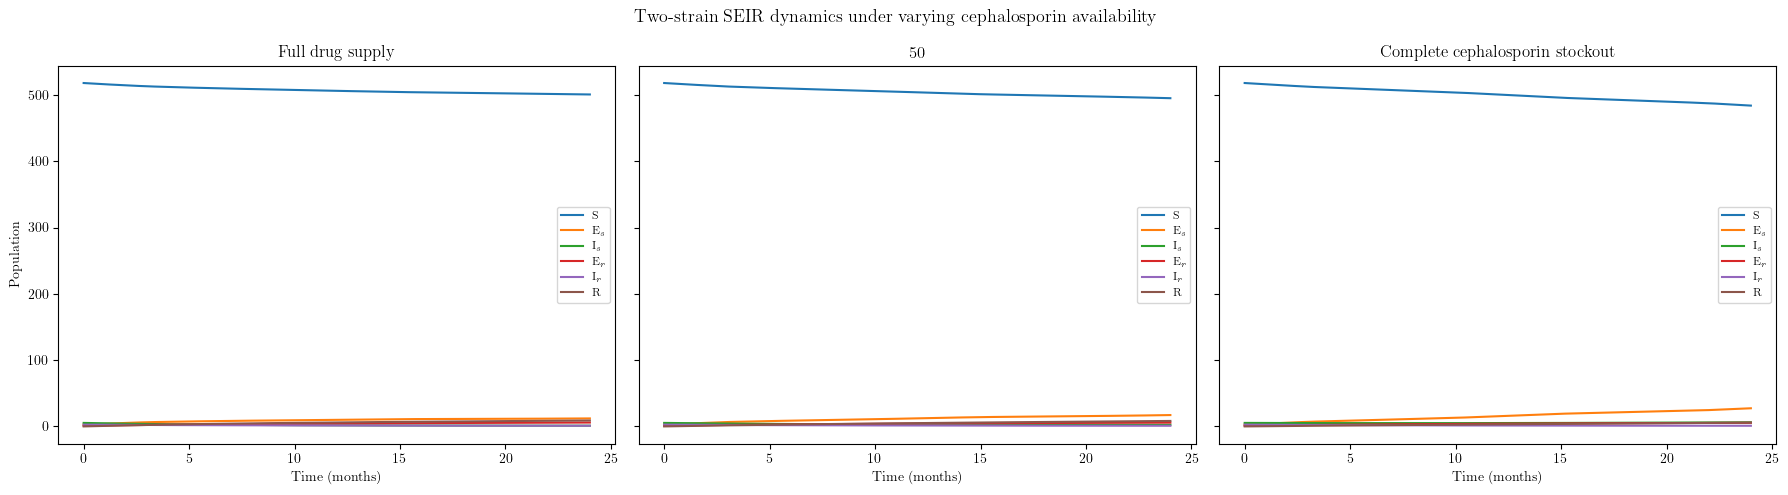

Full supply               → I_s(end)=1.10, I_r(end)=1.01, DR fraction=47.8%
50% stockout              → I_s(end)=2.42, I_r(end)=0.99, DR fraction=29.1%
Full stockout             → I_s(end)=6.25, I_r(end)=0.97, DR fraction=13.4%


In [123]:
# standalone seir: full supply vs 50% cephalosporin stockout
params = SEIR_PARAMS.copy()

# full supply
t1, y1 = run_seir(24, params=params)

# 50% cephalosporin stockout
t2, y2 = run_seir(24, params=params, supply_fn=lambda t: (0.5, 1.0))

# complete cephalosporin stockout
t3, y3 = run_seir(24, params=params, supply_fn=lambda t: (0.0, 1.0))

compartments = ["S", "E$_s$", "I$_s$", "E$_r$", "I$_r$", "R"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, lab in enumerate(compartments):
    axes[0].plot(t1, y1[:, i], label=lab)
    axes[1].plot(t2, y2[:, i], label=lab)
    axes[2].plot(t3, y3[:, i], label=lab)

axes[0].set_title("Full drug supply")
axes[1].set_title("50% cephalosporin supply")
axes[2].set_title("Complete cephalosporin stockout")

for ax in axes:
    ax.set_xlabel("Time (months)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Population")

fig.suptitle("Two-strain SEIR dynamics under varying cephalosporin availability", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/figures/seir_cephalosporin_supply.png", dpi=200, bbox_inches="tight")
plt.show()

# print key metrics
for label, y in [("Full supply", y1), ("50% stockout", y2), ("Full stockout", y3)]:
    Is_final = y[-1, 2]
    Ir_final = y[-1, 4]
    print(f"{label:25s} → I_s(end)={Is_final:.2f}, I_r(end)={Ir_final:.2f}, "
          f"DR fraction={Ir_final/(Is_final+Ir_final+1e-10):.1%}")

## epidemic-coupled gaborone simulation

couples the seir model to the gaborone supply chain:
1. each biweekly period, the optimizer allocates cephalosporins and carbapenems
2. realized availability feeds back to seir treatment rates
3. seir-driven infectious counts generate demand for the next period
4. compare deterministic, static robust, and aro-adr under epidemic conditions

In [124]:
# epidemic ↔ supply chain coupler
# strategy: run the seir model to generate epidemic demand trajectories,
# then inject those into the demand_draws array that the real optimizers consume.
# the seir modulates demand for cephalosporins (ds treatment) and carbapenems
# (dr treatment) at pmh.  all other drugs / facilities keep their mde demand.
# after each policy finishes, we measure how much ceph/carb was actually
# delivered to pmh, feed that back through the seir, and compare resistance
# emergence across policies.

def identify_drug_columns(classes, keywords):
    """Find column indices in `classes` whose name contains any keyword."""
    return [i for i, c in enumerate(classes) if any(kw in str(c).lower() for kw in keywords)]

def build_seir_demand_draws(
    T, model_nodes, model_classes, base_mu_mat, kappa,
    pmh_node, ceph_col_idx, carb_col_idx,
    seir_params, supply_trajectory=None, seed=42,
):
    rng = np.random.default_rng(seed)
    pmh_idx = model_nodes.index(pmh_node)

    # base nb draws for all nodes/classes
    mu = base_mu_mat.values.astype(float)
    kap = max(kappa, 1e-6)
    p_base = kap / (kap + mu)
    draws = rng.negative_binomial(n=kap, p=p_base, size=(T, *mu.shape)).astype(float)

    # initialize seir state
    params = seir_params.copy()
    N_pop = params["N_pop"]
    Is0 = 0.01 * N_pop; Ir0 = 0.005 * N_pop
    Es0 = 0.005 * N_pop; Er0 = 0.002 * N_pop
    S0 = N_pop - Is0 - Ir0 - Es0 - Er0
    y_seir = np.array([S0, Es0, Is0, Er0, Ir0, 0.0])

    dt_period = 0.5  # months per biweekly period

    # fix 1: set a1_star/a2_star in per-period units (same as supply_trajectory)
    ceph_nom = float(mu[pmh_idx, ceph_col_idx[0]]) if ceph_col_idx else 1.0
    carb_nom = float(mu[pmh_idx, carb_col_idx[0]]) if carb_col_idx else 1.0
    params["a1_star"] = max(ceph_nom, 1e-6)  # per-period units
    params["a2_star"] = max(carb_nom, 1e-6)  # per-period units

    seir_history = []

    for t in range(T):
        # drug availability this period (per-period units)
        if supply_trajectory is not None and t < len(supply_trajectory):
            a1, a2 = supply_trajectory[t]
        else:
            a1, a2 = params["a1_star"], params["a2_star"]

        # fix 2: pass a1/a2 directly - no dt_period rescaling
        # seir_rhs computes tau_s = tau0_s * min(a1/a1_star, 1.0)
        # both a1 and a1_star are now in identical per-period units, so the
        # ratio is correct and will be < 1.0 when supply is constrained.
        t_out, y_out = run_seir(
            dt_period, params=params,
            supply_fn=lambda t_inner, _a1=a1, _a2=a2: (_a1, _a2),
            y0=y_seir, dt=0.005,
        )
        y_seir = np.maximum(y_out[-1], 0.0)

        Is, Ir = y_seir[2], y_seir[4]

        # epidemic-driven mean demand
        epi_ceph = params["tau0_s"] * Is * dt_period
        epi_carb = params["tau0_r"] * Ir * dt_period

        # replace pmh ceph/carb draws with epidemic-driven nb draws
        for ci in ceph_col_idx:
            mu_epi = max(epi_ceph, 0.01)
            draws[t, pmh_idx, ci] = rng.negative_binomial(kap, kap / (kap + mu_epi))
        for ci in carb_col_idx:
            mu_epi = max(epi_carb, 0.01)
            draws[t, pmh_idx, ci] = rng.negative_binomial(kap, kap / (kap + mu_epi))

        seir_history.append({
            "t": t, "S": y_seir[0], "Es": y_seir[1], "Is": y_seir[2],
            "Er": y_seir[3], "Ir": y_seir[4], "R": y_seir[5],
            "epi_demand_ceph": epi_ceph, "epi_demand_carb": epi_carb,
            "supply_ceph": a1, "supply_carb": a2,
            # fix 3: log the actual coverage ratio for auditing
            "ceph_coverage": min(a1 / params["a1_star"], 1.0),
            "carb_coverage": min(a2 / params["a2_star"], 1.0),
        })

    return draws, seir_history


def extract_pmh_supply_from_results(metrics_df, I_final, model_nodes, model_classes,
                                     pmh_node, ceph_col_idx, carb_col_idx):
    """
    After running a policy, extract how much ceph/carb was actually delivered
    to PMH each period (served = demand - unmet).
    
    NOTE: The simulate functions don't return per-node breakdowns directly.
    We approximate supply as: demand_realized - unmet at PMH.
    This requires re-running with the SEIR draws to get node-level detail.
    """
    # for the iterative coupling, we use a simpler approach:
    # run seir with full supply first, then re-run with supply = nominal * (1 - unmet_pct/100)
    pass

print("build_seir_demand_draws() and helpers defined.")

build_seir_demand_draws() and helpers defined.


In [125]:
# identify cephalosporin / carbapenem drug columns
# uses the model_classes list from the gaborone network (cell 48).
# these are the antimicrobial class names from the glm.

ceph_keywords = ["cephalosporin", "cephalexin", "cefazolin", "cefuroxime",
                 "ceftriaxone", "cefixime", "cefotaxime", "ceftazidime", "cefepime",
                 "ceph", "3gc"]
carb_keywords = ["carbapenem", "meropenem", "imipenem", "ertapenem", "doripenem"]

# model_classes is overwritten to a 3-class subset in the seasonal cells above;
# re-derive the full class list from the demand matrix so the ceph/carb filter works
model_classes = model_demand_mat.columns.tolist()
ceph_col_idx = identify_drug_columns(model_classes, ceph_keywords)
carb_col_idx = identify_drug_columns(model_classes, carb_keywords)

print(f"Drug classes in model: {model_classes}")
print(f"\nCephalosporin columns: {[model_classes[i] for i in ceph_col_idx]} (idx={ceph_col_idx})")
print(f"Carbapenem columns:    {[model_classes[i] for i in carb_col_idx]} (idx={carb_col_idx})")

if not ceph_col_idx:
    print("\n⚠ No cephalosporin class found in model_classes.")
    print("  The GLM drug classes may use different names (e.g., 'Cephalosporins').")
    print("  Listing all classes for manual matching:")
    for i, c in enumerate(model_classes):
        print(f"    [{i}] {c}")
    print("\n  → Set ceph_col_idx and carb_col_idx manually if needed:")
    print("    ceph_col_idx = [<index>]")
    print("    carb_col_idx = [<index>]")

# pmh node name (princess marina hospital)
pmh_candidates = [n for n in model_nodes if "princess marina" in n.lower() or "pmh" in n.lower()]
if pmh_candidates:
    PMH_NODE = pmh_candidates[0]
else:
    # fall back: use the first hospital node
    hosp_nodes = [n for n in model_nodes if "hospital" in n.lower()]
    PMH_NODE = hosp_nodes[0] if hosp_nodes else model_nodes[1]
    print(f"⚠ Princess Marina Hospital not found; using {PMH_NODE}")

print(f"\nPMH node: {PMH_NODE}")

Drug classes in model: ['Aminoglycosides', 'Amphenicols', 'Carbapenems', 'Cephalosporins', 'Glycopeptides', 'Lincosamides', 'Macrolides', 'Nitroimidazoles', 'Penicillins', 'Quinolones', 'Sulphonamides', 'Tetracyclines']

Cephalosporin columns: ['Cephalosporins'] (idx=[3])
Carbapenem columns:    ['Carbapenems'] (idx=[2])

PMH node: Princess Marina Hospital


In [126]:
# run all 3 policies under seir-driven epidemic demand
# # approach (two-pass):
# pass 1: run seir with full supply → generates epidemic demand baseline.
# feed those demand_draws into all 3 optimizers.
# pass 2: extract per-policy unmet % → re-run seir with degraded supply
# proportional to each policy's shortage → compare resistance emergence.
# important: we restrict the optimizers to cephalosporin + carbapenem only.
# running on all drug classes is meaningless for the epidemic coupling
# the seir model only modulates ceph/carb demand.

T_epi = 52  # biweekly periods (2 years)
kappa_epi = 10.0
Gamma_epi = 10.0

# filter to cephalosporin + carbapenem only
epi_drug_idx = sorted(ceph_col_idx + carb_col_idx)
assert len(epi_drug_idx) > 0, "No cephalosporin or carbapenem columns found!"

epi_classes = [model_classes[i] for i in epi_drug_idx]
epi_demand_mat = model_demand_mat[epi_classes]

# remap ceph/carb indices to their positions in the filtered array
epi_ceph_idx = [epi_drug_idx.index(i) for i in ceph_col_idx]
epi_carb_idx = [epi_drug_idx.index(i) for i in carb_col_idx]

# carbapenem demand fix
# carbapenem mde demand is zero (second-line reserve drug rarely appears
# in pps data). set nominal carbapenem demand at pmh to 10% of cephalosporin
# demand to enable supply feedback through tau_r.
ceph_pmh = float(epi_demand_mat.loc[PMH_NODE, epi_classes[epi_ceph_idx[0]]])
epi_demand_mat = epi_demand_mat.copy()
epi_demand_mat.loc[PMH_NODE, epi_classes[epi_carb_idx[0]]] = 0.1 * ceph_pmh

print(f"Adjusted PMH carbapenem demand: {0.1 * ceph_pmh:.2f} "
      f"(10% of cephalosporin demand {ceph_pmh:.2f})")

print(f"Epidemic classes (filtered): {epi_classes}")
print(f"  Cephalosporin idx (remapped): {epi_ceph_idx}")
print(f"  Carbapenem idx (remapped):    {epi_carb_idx}")

# pass 1: seir with full supply (baseline epidemic demand)
print("\nPass 1: generating SEIR demand draws (full supply)...")
epi_draws_full, seir_hist_full = build_seir_demand_draws(
    T=T_epi, model_nodes=model_nodes, model_classes=epi_classes,
    base_mu_mat=epi_demand_mat, kappa=kappa_epi,
    pmh_node=PMH_NODE, ceph_col_idx=epi_ceph_idx, carb_col_idx=epi_carb_idx,
    seir_params=SEIR_PARAMS, supply_trajectory=None, seed=42,
)

seir_baseline = pd.DataFrame(seir_hist_full)
print(f"  SEIR baseline: I_s(end)={seir_baseline['Is'].iloc[-1]:.2f}, "
      f"I_r(end)={seir_baseline['Ir'].iloc[-1]:.2f}")

# recompute sigma for the epidemic horizon (filtered classes only)
sigma_mat_epi = nb_sigma_from_mean(epi_demand_mat, kappa=kappa_epi) \
    .reindex(index=model_nodes, columns=epi_classes).fillna(0.0).astype(float)

# run deterministic
print("\nRunning deterministic policy under epidemic demand...")
metrics_det_epi, _ = simulate_policy_under_draws(
    T=T_epi, CMS=CMS, nodes=model_nodes, arcs=model_arcs, classes=epi_classes,
    dist_km=D_km, mu_mat=epi_demand_mat, demand_draws=epi_draws_full,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=1.0,
    supply_multiplier=0.0, arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node, solver=solver,
    relax_integrality=True,
)
print(f"  Deterministic: avg unmet = {metrics_det_epi['unmet_pct_realized'].mean():.2f}%")

# run static robust
print("\nRunning static robust policy under epidemic demand...")
metrics_rob_epi, _ = simulate_static_robust_under_draws(
    T=T_epi, CMS=CMS, nodes=model_nodes, arcs=model_arcs, classes=epi_classes,
    dist_km=D_km, mu_mat=epi_demand_mat, demand_draws=epi_draws_full,
    sigma_mat=sigma_mat_epi, Gamma=Gamma_epi,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=1.0,
    supply_multiplier=0.0, arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node, solver=solver,
    relax_integrality=True,
)
print(f"  Static Robust: avg unmet = {metrics_rob_epi['unmet_pct_realized'].mean():.2f}%")

# run aro-adr
print("\nRunning ARO-ADR policy under epidemic demand...")
metrics_adr_epi, alpha_epi = simulate_aro_adr_under_draws(
    T=T_epi, CMS=CMS, nodes=model_nodes, arcs=model_arcs, arc_df=arcs,
    classes=epi_classes, dist_km=D_km, mu_mat=epi_demand_mat,
    demand_draws=epi_draws_full, sigma_mat=sigma_mat_epi, Gamma=Gamma_epi,
    transport_cost_per_km=0.5, shortage_penalty_per_unit=100.0,
    holding_cost_per_unit=0.1, procurement_cost_per_unit=1.0,
    supply_multiplier=0.0, arc_cap=arc_cap,
    storage_cap_per_node=storage_cap_per_node, solver=solver,
    relax_integrality=True,
)
print(f"  ARO-ADR: avg unmet = {metrics_adr_epi['unmet_pct_realized'].mean():.2f}%")

print("\n\nPass 2: re-running SEIR with policy-specific supply degradation...")
epi_results = {}

ceph_nom = float(epi_demand_mat.loc[PMH_NODE, epi_classes[epi_ceph_idx[0]]]) if epi_ceph_idx else 1.0
carb_nom = float(epi_demand_mat.loc[PMH_NODE, epi_classes[epi_carb_idx[0]]]) if epi_carb_idx else 1.0

for name, metrics_df in [("Deterministic", metrics_det_epi),
                          ("Static Robust", metrics_rob_epi),
                          ("ARO-ADR",       metrics_adr_epi)]:

    # fix 1: use total_unmet/total_demand directly (pmh is the entire demand)
    unmet_units  = metrics_df["total_unmet_units"].values
    demand_units = metrics_df["total_demand_units"].values

    supply_traj = []
    for t in range(T_epi):
        frac_served = max(1.0 - unmet_units[t] / max(demand_units[t], 1e-6), 0.0)
        supply_traj.append((ceph_nom * frac_served, carb_nom * frac_served))

    # diagnostic: confirm policies differ
    print(f"  [{name}] t=0  a1={supply_traj[0][0]:.2f}  ratio={supply_traj[0][0]/ceph_nom:.4f}")
    print(f"  [{name}] t=10 a1={supply_traj[10][0]:.2f} ratio={supply_traj[10][0]/ceph_nom:.4f}")

    _, seir_hist = build_seir_demand_draws(
        T=T_epi, model_nodes=model_nodes, model_classes=epi_classes,
        base_mu_mat=epi_demand_mat, kappa=kappa_epi,
        pmh_node=PMH_NODE, ceph_col_idx=epi_ceph_idx, carb_col_idx=epi_carb_idx,
        seir_params=SEIR_PARAMS, supply_trajectory=supply_traj, seed=42,
    )

    epi_df = pd.DataFrame(seir_hist)
    epi_df["unmet_pct"] = metrics_df["unmet_pct_realized"].values

    # fix 2: correct operator precedence for dr_fraction
    # bug was: epi_df["ir"] / (epi_df["is"] + epi_df["ir"]).clip(lower=1e-10)
    # that clips ir alone before dividing, not the denominator
    denom = (epi_df["Is"] + epi_df["Ir"]).clip(lower=1e-10)
    epi_df["dr_fraction"] = epi_df["Ir"] / denom

    epi_results[name] = epi_df
    epi_results[f"{name}_metrics"] = metrics_df

    print(f"  {name:20s}: final I_s={epi_df['Is'].iloc[-1]:.2f}, "
          f"I_r={epi_df['Ir'].iloc[-1]:.2f}, "
          f"DR%={epi_df['dr_fraction'].iloc[-1]*100:.1f}%")

print("\nEpidemic simulation complete.")

Adjusted PMH carbapenem demand: 281.22 (10% of cephalosporin demand 2812.18)
Epidemic classes (filtered): ['Carbapenems', 'Cephalosporins']
  Cephalosporin idx (remapped): [1]
  Carbapenem idx (remapped):    [0]

Pass 1: generating SEIR demand draws (full supply)...
  SEIR baseline: I_s(end)=1.26, I_r(end)=0.99

Running deterministic policy under epidemic demand...
  Deterministic: avg unmet = 13.50%

Running static robust policy under epidemic demand...
  Static Robust: avg unmet = 3.87%

Running ARO-ADR policy under epidemic demand...
  ARO-ADR: avg unmet = 0.42%


Pass 2: re-running SEIR with policy-specific supply degradation...
  [Deterministic] t=0  a1=2452.57  ratio=0.8721
  [Deterministic] t=10 a1=2365.98 ratio=0.8413
  Deterministic       : final I_s=1.53, I_r=1.15, DR%=42.9%
  [Static Robust] t=0  a1=2716.41  ratio=0.9659
  [Static Robust] t=10 a1=2645.63 ratio=0.9408
  Static Robust       : final I_s=1.33, I_r=1.03, DR%=43.7%
  [ARO-ADR] t=0  a1=2812.03  ratio=0.9999
  [ARO-

### epidemic simulation results


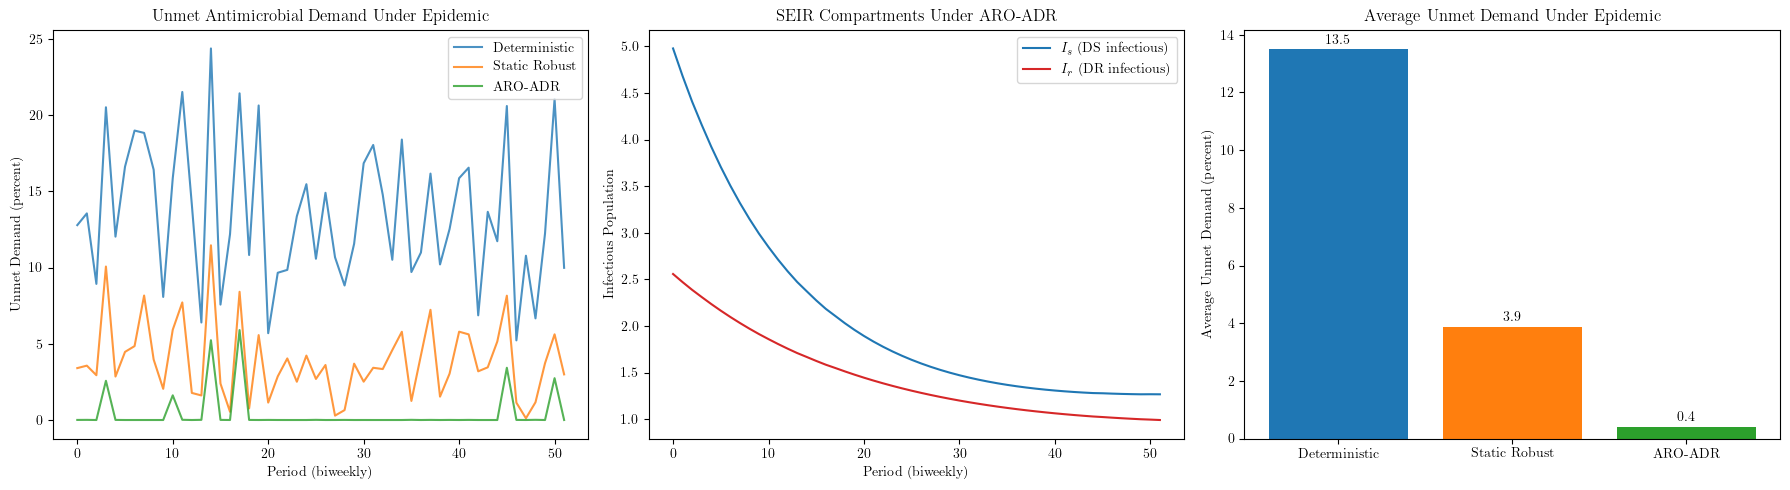

Saved epidemic_gaborone_results.png


In [127]:
policy_names = ["Deterministic", "Static Robust", "ARO-ADR"]
colors = {"Deterministic": "#1f77b4", "Static Robust": "#ff7f0e", "ARO-ADR": "#2ca02c"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# panel 1: unmet demand over time
ax = axes[0]
for p in policy_names:
    df = epi_results[f"{p}_metrics"]
    ax.plot(df["t"], df["unmet_pct_realized"], label=p, color=colors[p], alpha=0.8)
ax.set_ylabel("Unmet Demand (percent)")
ax.set_xlabel("Period (biweekly)")
ax.set_title("Unmet Antimicrobial Demand Under Epidemic")
ax.legend()

# panel 2: seir compartments (aro-adr)
ax = axes[1]
df = epi_results["ARO-ADR"]
ax.plot(df["t"], df["Is"], label="$I_s$ (DS infectious)", color="tab:blue")
ax.plot(df["t"], df["Ir"], label="$I_r$ (DR infectious)", color="tab:red")
ax.set_ylabel("Infectious Population")
ax.set_xlabel("Period (biweekly)")
ax.set_title("SEIR Compartments Under ARO-ADR")
ax.legend()

# panel 3: average unmet demand bar chart
ax = axes[2]
avg_unmet = [epi_results[f"{p}_metrics"]["unmet_pct_realized"].mean() 
             for p in policy_names]
bars = ax.bar(policy_names, avg_unmet, 
              color=[colors[p] for p in policy_names])
ax.set_ylabel("Average Unmet Demand (percent)")
ax.set_title("Average Unmet Demand Under Epidemic")
for bar, val in zip(bars, avg_unmet):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
            f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/epidemic_gaborone_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved epidemic_gaborone_results.png")

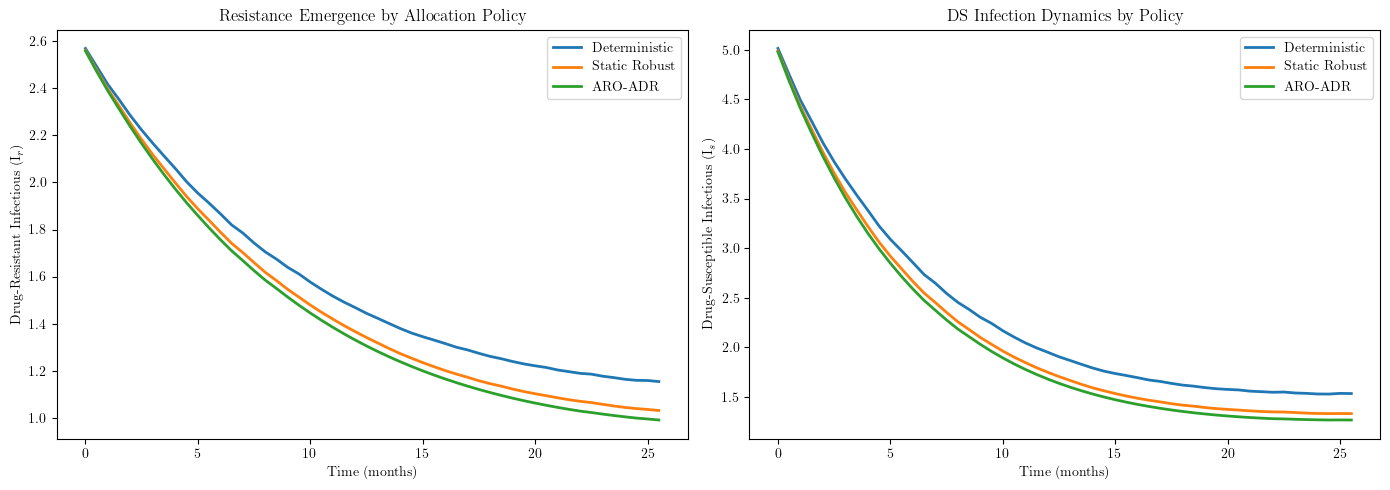


Policy               Avg Unmet%  Final I_s  Final I_r  Final DR%
Deterministic             13.50       1.53       1.15      42.9%
Static Robust              3.87       1.33       1.03      43.7%
ARO-ADR                    0.42       1.27       0.99      43.9%


In [128]:
# resistance emergence comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: i_r trajectories
ax = axes[0]
for p in policy_names:
    df = epi_results[p]
    ax.plot(df["t"] * 0.5, df["Ir"], label=p, color=colors[p], linewidth=2)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Drug-Resistant Infectious (I$_r$)")
ax.set_title("Resistance Emergence by Allocation Policy")
ax.legend()

# right: i_s trajectories
ax = axes[1]
for p in policy_names:
    df = epi_results[p]
    ax.plot(df["t"] * 0.5, df["Is"], label=p, color=colors[p], linewidth=2)
ax.set_xlabel("Time (months)")
ax.set_ylabel("Drug-Susceptible Infectious (I$_s$)")
ax.set_title("DS Infection Dynamics by Policy")
ax.legend()

plt.tight_layout()
plt.savefig("../outputs/figures/resistance_emergence_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# summary table
print("\n" + "="*75)
print(f"{'Policy':20s} {'Avg Unmet%':>10s} {'Final I_s':>10s} {'Final I_r':>10s} {'Final DR%':>10s}")
print("="*75)
for p in policy_names:
    m = epi_results[f"{p}_metrics"]
    e = epi_results[p]
    print(f"{p:20s} {m['unmet_pct_realized'].mean():10.2f} "
          f"{e['Is'].iloc[-1]:10.2f} {e['Ir'].iloc[-1]:10.2f} "
          f"{e['dr_fraction'].iloc[-1]*100:9.1f}%")
print("="*75)

# section 5.3.3: national results on cms-provided data

this section loads the pre-computed cms simulation results from `cms_results.parquet` and generates choropleth maps analogous to the simulation-based results in section 5.3.2. two scenarios are evaluated: **2025-26** and **2026-27** average monthly consumption estimates provided by cms.

In [ ]:
# load cms results
cms_results_df = pd.read_parquet("cms_results.parquet")
print(f"Loaded {len(cms_results_df)} rows, "
      f"{cms_results_df['region'].nunique()} regions, "
      f"scenarios: {cms_results_df['scenario'].unique().tolist()}")

# load shapefile
gdf = gpd.read_file("botswana.geojson")

# region -> district crosswalk
region_to_district = {
    "Boteti":              "Central District",
    "Chobe":               "Chobe District",
    "Ghanzi":              "Ghanzi District",
    "Greater Francistown": "North-East District",
    "Greater Gaborone":    "South-East District",
    "Greater Lobatse":     "South-East District",
    "Greater Phikwe":      "Central District",
    "Kgalagadi North":     "Kgalagadi District",
    "Kgalagadi South":     "Kgalagadi District",
    "Kgatleng":            "Kgatleng District",
    "Kweneng":             "Kweneng District",
    "Mahalapye":           "Central District",
    "Ngami":               "North-West District",
    "North East":          "North-East District",
    "Okavango":            "North-West District",
    "Serowe-Palapye":      "Central District",
    "Southern":            "Southern District",
    "Tutume":              "Central District",
}

models = ["deterministic", "static_robust", "aro_adr"]
model_labels = {
    "deterministic": "Deterministic",
    "static_robust": "Static Robust",
    "aro_adr":       "ARO-ADR",
}
scenarios = ["2526", "2627"]
scenario_labels = {"2526": "2025-26 AMC", "2627": "2026-27 AMC"}

In [ ]:
# summary table: mean metrics by scenario x model
summary_table = (
    cms_results_df
    .groupby(["scenario", "model"])[
        ["unmet_pct_realized", "procurement_cost", "objective_realized"]
    ]
    .mean()
    .round(2)
)
summary_table.columns = ["Avg. Unmet Demand (%)", "Avg. Procurement Cost", "Avg. Objective"]
summary_table

### cms unmet demand heatmaps by policy and scenario


In [ ]:
# aggregate to district level
cms_summary = (
    cms_results_df
    .groupby(["region", "model", "scenario"])["unmet_pct_realized"]
    .mean()
    .reset_index()
    .rename(columns={"unmet_pct_realized": "avg_unmet_pct"})
)

cms_records = []
for region, district in region_to_district.items():
    for model in models:
        for scenario in scenarios:
            val = cms_summary.loc[
                (cms_summary["region"]   == region)  &
                (cms_summary["model"]    == model)   &
                (cms_summary["scenario"] == scenario),
                "avg_unmet_pct"
            ]
            if not val.empty:
                cms_records.append({
                    "shapeName": district,
                    "model":     model,
                    "scenario":  scenario,
                    "avg_unmet_pct": val.values[0],
                })

cms_district_df = (
    pd.DataFrame(cms_records)
    .groupby(["shapeName", "model", "scenario"])["avg_unmet_pct"]
    .mean()
    .reset_index()
)

# shared colour scale
vmin_cms = cms_district_df["avg_unmet_pct"].min()
vmax_cms = cms_district_df["avg_unmet_pct"].max()
cmap_cms = "RdYlGn_r"

# 3 rows (models) x 2 cols (scenarios)
fig, axes = plt.subplots(3, 2, figsize=(14, 18))
fig.patch.set_facecolor("white")
fig.subplots_adjust(bottom=0.08, hspace=0.05, wspace=0.05)

for row, model in enumerate(models):
    for col, scenario in enumerate(scenarios):
        ax = axes[row, col]
        panel_data = cms_district_df[
            (cms_district_df["model"]    == model) &
            (cms_district_df["scenario"] == scenario)
        ]
        merged = gdf.merge(panel_data, on="shapeName", how="left")
        merged.plot(
            column="avg_unmet_pct", ax=ax, cmap=cmap_cms,
            vmin=vmin_cms, vmax=vmax_cms,
            edgecolor="white", linewidth=1.0,
            missing_kwds={"color": "lightgrey"},
        )
        for _, r in merged.iterrows():
            centroid = r.geometry.centroid
            name = (
                str(r["shapeName"])
                .replace(" District", "")
                .replace("North-East", "NE")
                .replace("North-West", "NW")
                .replace("South-East", "SE")
                .replace(" ", "\n")
            )
            ax.annotate(
                name, xy=(centroid.x, centroid.y),
                ha="center", va="center",
                fontsize=5.5, color="white", fontweight="bold",
            )
        ax.axis("off")
        if row == 0:
            ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="bold", pad=8)
        if col == 0:
            ax.set_ylabel(model_labels[model], fontsize=11, fontweight="bold", labelpad=8)
            ax.yaxis.set_visible(True)
            ax.tick_params(left=False, labelleft=False)

sm = plt.cm.ScalarMappable(cmap=cmap_cms, norm=mcolors.Normalize(vmin=vmin_cms, vmax=vmax_cms))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), orientation="horizontal",
                    fraction=0.02, pad=0.08, shrink=0.5)
cbar.set_label("Average Unmet Demand (percent)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

fig.suptitle(
    "CMS-Based Simulation: Average Unmet Antimicrobial Demand\n"
    "Rows = Policy  |  Columns = Scenario",
    fontsize=13, fontweight="bold", y=0.98,
)
plt.savefig("../outputs/figures/cms_unmet_map.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# bar chart: average unmet demand by policy and scenario
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor("white")

colors = {"deterministic": "#e74c3c", "static_robust": "#f39c12", "aro_adr": "#27ae60"}

for idx, scenario in enumerate(scenarios):
    ax = axes[idx]
    sc_data = cms_results_df[cms_results_df["scenario"] == scenario]
    means = sc_data.groupby("model")["unmet_pct_realized"].mean()
    sems  = sc_data.groupby("model")["unmet_pct_realized"].sem()

    x_pos = range(len(models))
    bars = ax.bar(
        x_pos,
        [means[m] for m in models],
        yerr=[sems[m] for m in models],
        color=[colors[m] for m in models],
        capsize=5, edgecolor="white", linewidth=0.8,
    )
    ax.set_xticks(x_pos)
    ax.set_xticklabels([model_labels[m] for m in models], fontsize=10)
    ax.set_title(scenario_labels[scenario], fontsize=12, fontweight="bold")
    ax.set_ylabel("Average Unmet Demand (percent)" if idx == 0 else "", fontsize=10)

    for bar, m in zip(bars, models):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{means[m]:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

fig.suptitle("Average Unmet Demand with Standard Errors (CMS Data)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../outputs/figures/cms_bar.png", dpi=200, bbox_inches="tight")
plt.show()

### cms results: multi-metric choropleth maps

analogous to appendix figure 16 for the simulation trial, this generates district-level choropleth maps for all cost components across the three policies, for each cms scenario.

In [ ]:
# multi-metric choropleths for cms data
metrics_to_plot = [
    ("unmet_pct_realized",      "Avg Unmet Demand (percent)"),
    ("objective_realized",      "Avg Objective Value"),
    ("procurement_cost",        "Avg Procurement Cost"),
    ("transport_cost_realized", "Avg Transport Cost"),
    ("holding_cost_end",        "Avg Holding Cost"),
    ("shortage_cost_realized",  "Avg Shortage Cost"),
]

for scenario in scenarios:
    sc_df = cms_results_df[cms_results_df["scenario"] == scenario]
    n_rows = len(metrics_to_plot)
    fig, axes = plt.subplots(n_rows, 3, figsize=(18, n_rows * 5))
    fig.patch.set_facecolor("white")

    for row_idx, (metric, metric_label) in enumerate(metrics_to_plot):
        metric_summary = (
            sc_df.groupby(["region", "model"])[metric]
            .mean().reset_index().rename(columns={metric: "value"})
        )
        records_m = []
        for region, district in region_to_district.items():
            for model in models:
                val = metric_summary.loc[
                    (metric_summary["region"] == region) & (metric_summary["model"] == model),
                    "value"
                ]
                if not val.empty:
                    records_m.append({"shapeName": district, "model": model, "value": val.values[0]})

        district_metric_df = (
            pd.DataFrame(records_m)
            .groupby(["shapeName", "model"])["value"].mean().reset_index()
        )
        vmin_m = district_metric_df["value"].min()
        vmax_m = district_metric_df["value"].max()

        for col_idx, model in enumerate(models):
            ax = axes[row_idx, col_idx]
            model_data = district_metric_df[district_metric_df["model"] == model]
            merged = gdf.merge(model_data, on="shapeName", how="left")
            merged.plot(
                column="value", ax=ax, cmap="RdYlGn_r",
                vmin=vmin_m, vmax=vmax_m,
                edgecolor="white", linewidth=1.0,
                missing_kwds={"color": "lightgrey"},
            )
            for _, r in merged.iterrows():
                centroid = r.geometry.centroid
                name = (
                    str(r["shapeName"])
                    .replace(" District", "")
                    .replace("North-East", "NE")
                    .replace("North-West", "NW")
                    .replace("South-East", "SE")
                    .replace(" ", "\n")
                )
                ax.annotate(name, xy=(centroid.x, centroid.y),
                            ha="center", va="center",
                            fontsize=5.5, color="white", fontweight="bold")
            if row_idx == 0:
                ax.set_title(model_labels[model], fontsize=12, fontweight="bold", pad=8)
            ax.axis("off")
            if col_idx == 2:
                sm = plt.cm.ScalarMappable(cmap="RdYlGn_r",
                    norm=mcolors.Normalize(vmin=vmin_m, vmax=vmax_m))
                sm.set_array([])
                cbar = fig.colorbar(sm, ax=ax, orientation="vertical", fraction=0.05, pad=0.02)
                cbar.set_label(metric_label, fontsize=8)
                cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"CMS Simulation Results Across Botswana by Policy and Metric ({scenario_labels[scenario]})",
        fontsize=14, fontweight="bold", y=1.01,
    )
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/cms_full_metrics_{scenario}.png", dpi=200, bbox_inches="tight")
    plt.show()